In [1]:
import os
import sys
# Get the absolute path of the current notebook's directory
notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
sys.path.append(parent_dir)  # Add parent directory to sys.path

# model
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric as tg
import torch_scatter
from typing import Dict, Union

# crystal structure data
palette = ['#43AA8B', '#F8961E', '#F94144']
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
# data pre-processing and visualization
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
from scipy.interpolate import interp1d
import math
import e3nn.o3 as o3
from e3nn.util.jit import compile_mode
from e3nn.io import CartesianTensor

# utilities
import time
from mendeleev import element
from tqdm import tqdm
from utils.utils_data import load_data, train_valid_test_split, save_or_load_onehot, build_data, format_chemical_formula
from utils.utils_model_full_tensor import Network, train, evaluate
import wandb
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde

bar_format = '{l_bar}{bar:10}{r_bar}{bar:-10b}'
default_dtype = torch.float64
torch.set_default_dtype(default_dtype)

# Create a colormap based on the number of unique symbols
datasets = ['g', 'y', 'r']
colors = dict(zip(datasets, palette))
cmap = mpl.colors.LinearSegmentedColormap.from_list('cmap', [palette[k] for k in [0,2,1]])


# Check device
device = "cuda:2" if torch.cuda.is_available() else "cpu"
print('torch device:' , device)


## load data
data_file = '../dataset/symmetrized_dataset_with_bandgap.pkl'
df, species = load_data(data_file)
df = df.reset_index(drop=True)

energy_min = 0 #Unit of energy in eV
energy_max = 30 #Unit of energy in eV
nstep = 300 #Number of the energy points

new_x = np.linspace(energy_min, energy_max, nstep)
# Efficiently interpolate all matrices using list comprehension
def interpolate_matrix(matrix, omega):
    """Interpolates the full (3001, 3, 3) matrix along the energy axis."""
    interp = interp1d(omega, matrix, kind='linear', axis=0, fill_value=0, bounds_error=False)
    return interp(new_x) 

def interpolate_matrix(matrix, omega):
    """Interpolates the full (3001, 3, 3) matrix along the energy axis."""
    interp = interp1d(omega, matrix, kind='linear', axis=0, fill_value=0, bounds_error=False)
    return interp(new_x) 

def get_neighbors(df, idx):
    n = []
    for entry in df.iloc[idx].itertuples():
        N = entry.data.pos.shape[0]
        for i in range(N):
            n.append(len((entry.data.edge_index[0] == i).nonzero()))
    return np.array(n)

def get_dataloaders_from_cache(batch_size=4):
    cache = torch.load("../dataset/cached_preprocessed_data.pt")

    df = cache["df"]
    idx_train = cache["idx_train"]
    idx_valid = cache["idx_valid"]
    idx_test = cache["idx_test"]
    out_dim = cache["out_dim"]
    r_max = cache["r_max"]
    n_train = get_neighbors(df, idx_train)

    scale_0e = cache["scale_0e"]
    scale_2e = cache["scale_2e"]

    dataloader_train = tg.loader.DataLoader(
        df.iloc[idx_train]['data'].values,
        batch_size=batch_size, shuffle=True
    )
    dataloader_valid = tg.loader.DataLoader(
        df.iloc[idx_valid]['data'].values,
        batch_size=batch_size
    )

    return dataloader_train, dataloader_valid, out_dim, r_max, n_train, scale_0e, scale_2e, idx_train, idx_valid, idx_test



torch device: cuda:2


42.50108904548367


wandb: Currently logged in as: hsu-ting (hsu-ting-northeastern-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


100%|██████████| 23/23 [00:08<00:00,  2.61it/s]


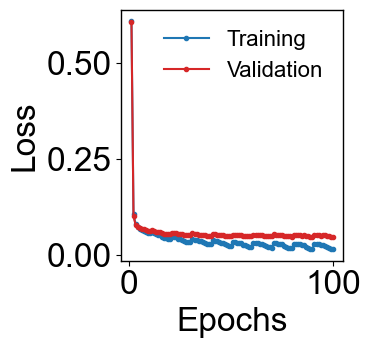

In [2]:
batch_size = 12
dataloader_train, dataloader_valid, out_dim, r_max, n_train, scale_0e, scale_2e, idx_train, idx_valid, idx_test= \
    get_dataloaders_from_cache(batch_size=batch_size)

# def get_neighbors(df, idx):
#     n = []
#     for entry in df.iloc[idx].itertuples():
#         N = entry.data.pos.shape[0]
#         for i in range(N):
#             n.append(len((entry.data.edge_index[0] == i).nonzero()))
#     return np.array(n)

# n_train = get_neighbors(df, idx_train)
print(n_train.mean())
# n_valid = get_neighbors(df, idx_valid)
# n_test = get_neighbors(df, idx_test)

class PeriodicNetwork(Network):
    def __init__(self, in_dim, em_dim, **kwargs):            
        # override the `reduce_output` keyword to instead perform an averge over atom contributions    
        self.pool = False
        if kwargs['reduce_output'] == True:
            kwargs['reduce_output'] = False
            self.pool = True
            
        super().__init__(**kwargs)

        self.em_z = nn.Linear(in_dim, em_dim)    #Linear layer for atom type
        self.em_x = nn.Linear(in_dim, em_dim)    #Linear layer for atom type

    def forward(self, data: Union[tg.data.Data, Dict[str, torch.Tensor]]) -> torch.Tensor:
        data.z = F.relu(self.em_z(data.z))
        data.x = F.relu(self.em_x(data.x))

        output = super().forward(data)
        # if pool_nodes was set to True, use scatter_mean to aggregate
        if self.pool == True:
            output = torch_scatter.scatter_mean(output, data.batch, dim=0)  # take meacd n over atoms per example
        return output


em_dim = 128
lmax = 2
lr = 1e-2
layers = 3
mul = 64
use_batch_norm = False
dropout_prob=0
r_max = 6
    
model = PeriodicNetwork(
    in_dim=118,
    em_dim=em_dim,
    irreps_in=str(em_dim)+"x0e",
    irreps_out=str(out_dim)+"x0e +" + str(out_dim) + "x2e",
    irreps_node_attr=str(em_dim)+"x0e",
    layers=layers,
    mul=mul,
    lmax=lmax,
    max_radius=r_max,
    num_neighbors=n_train.mean(),
    reduce_output=True,
    dropout_prob=dropout_prob,
    use_batch_norm = use_batch_norm
)
# run_name = f'symmetrized_data_model_im_{run_time}_for_paper'
# run_name = f'symmetrized_data_model_im_{run_time}'
# run_name = f'tensor_model_250713_Lmax=4'
# run_name = f'tensor_model_250713_Lmax=2_with_b'  
# run_name = f'saved_test_{run_time}_Lmax={lmax}_Lr_0.01_with_individual_b'
# run_name = f'revision_{run_time}_Lmax_{lmax}_Lr_{lr}_bs_{batch_size}_em_{em_dim}_layers_{layers}_mul_{mul}'
run_name = f'optuna_trial_27'
# run_name = f'test_250909_Lmax=4_Lr_0.005_with_individual_b'

wandb.init(
    project="Prediction",  # Change this to your project name
    name=run_name,  # Unique identifier for this run
    config={
    }
)



# Build a dataloader for the whole dataset
# predict on all data
model.load_state_dict(torch.load('../model/'+run_name + '_best.torch', map_location=device)['state'])
history = torch.load('../model/' + run_name + '.torch', map_location=device)['history']
steps = [d['step'] + 1 for d in history]
loss_train = [d['train']['loss'] for d in history]
loss_valid = [d['valid']['loss'] for d in history]
fig, ax = plt.subplots(figsize=(4,4))
ax.plot(steps, loss_train, 'o-', label="Training", color='C0',markersize=3)
ax.plot(steps, loss_valid, 'o-', label="Validation", color='C3',markersize=3)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend(frameon=False)
plt.tight_layout()
save_png_dir = "../pngs"
save_path = os.path.join(save_png_dir, run_name + '_loss.png')
fig.savefig(save_path,dpi=300)

model.pool = True


cache = torch.load("../dataset/cached_preprocessed_data.pt")
df = cache["df"]
dataloader = tg.loader.DataLoader(df['data'].values, batch_size=64)
df['mse_sph'] = 0.
df['y_pred_sph'] = np.empty((len(df), 0)).tolist()

model.to(device)
model.eval()

predictions = [] 
i0 = 0
with torch.no_grad():
    for i, d in tqdm(enumerate(dataloader), total=len(dataloader), bar_format=bar_format):
        d.to(device)
        output = model(d)
        
        irreps_0e = model.irreps_out.count(o3.Irrep("0e"))
        irreps_2e = model.irreps_out.count(o3.Irrep("2e")) * 5
        out_dim = model.irreps_out.count(o3.Irrep("0e")) 
        # scale_2e_expanded = scale_2e.view(1, 1, 1)

        # output_0e = output[:, :irreps_0e]  # Shape: (batch_size, irreps_0e)
        # output_2e = output[:, irreps_0e:irreps_0e + irreps_2e].contiguous().view(output.shape[0], out_dim, 5)  # Shape: (batch_size, 201, 5)
        output_0e = output[:, :irreps_0e] * scale_0e  # unnormalize
        output_2e = output[:, irreps_0e:irreps_0e + irreps_2e].contiguous().view(-1, out_dim, 5) * scale_2e  # unnormalize
        # y_0e = d.y[:, :, 0].view(d.y.shape[0], out_dim) 
        # y_2e = d.y[:, :, 1:].view(d.y.shape[0], out_dim, 5)  # Shape: (batch_size, 201, 5)

        y_0e = d.y[:, :, 0].view(-1, out_dim) * scale_0e
        y_2e = d.y[:, :, 1:].view(-1, out_dim, 5) * scale_2e

        loss_0e = F.l1_loss(output_0e, y_0e)   # MAE or other suitable loss
        loss_2e = F.l1_loss(output_2e, y_2e)   # MAE or other suitable loss
        loss = loss_0e + loss_2e
        
        combined_output = torch.cat([output_0e.unsqueeze(2), output_2e], dim=2)  # Shape: (batch_size, 201, 6)
        predictions.append(combined_output.cpu())

        for batch_idx in range(d.y.shape[0]):
            df.loc[i0 + batch_idx, 'y_pred_sph'] = [combined_output[batch_idx].cpu().numpy()]
            df.loc[i0 + batch_idx, 'mse_sph'] = loss.cpu().numpy() #* scale_data

        # Update batch index counter
        i0 += d.y.shape[0]

column = 'rel_permittivity_imag_interp'

# =====================================================
# Convert spherical → Cartesian predictions
# =====================================================
df['y_pred_sph'] = df['y_pred_sph'].map(lambda x: x[0]) 

sph_tensors = torch.tensor(np.stack(df['y_pred_sph'].values))  # (N, F, 6)
cart_and_irreps = CartesianTensor("ij=ji")  # Symmetric rank-2 tensor
cart_tensors = cart_and_irreps.to_cartesian(sph_tensors)                     # (N, F, 3, 3)
df['y_pred_cart'] = list(cart_tensors.numpy())                 # back to list of arrays

# =====================================================
# Prepare true & pred Cartesian tensors
# =====================================================
cart_true = np.stack(df[column].values)        # (N, F, 3, 3)
cart_pred = np.stack(df['y_pred_cart'].values) # (N, F, 3, 3)

cart_true_tensor = torch.tensor(cart_true, dtype=torch.float64)
cart_pred_tensor = torch.tensor(cart_pred, dtype=torch.float64)

# =====================================================
# Component-wise Cartesian MAE
# =====================================================
triu_idx = np.triu_indices(3)  # 6 unique entries
component_labels = ["xx", "xy", "xz", "yy", "yz", "zz"]

def mae_symmetric_components(pred, true):
    """
    pred, true: (N,F,3,3)
    return: (N,F,6) absolute errors for each unique component
    """
    errors = []
    for i, j in zip(triu_idx[0], triu_idx[1]):
        errors.append(torch.abs(pred[:, :, i, j] - true[:, :, i, j]))  # (N,F)
    return torch.stack(errors, dim=2)  # (N,F,6)
def mse_symmetric_components(pred, true):
    """
    pred, true: (N,F,3,3)
    return: (N,F,6) absolute errors for each unique component
    """
    errors = []
    for i, j in zip(triu_idx[0], triu_idx[1]):
        errors.append((pred[:, :, i, j] - true[:, :, i, j])**2)  # (N,F)
    return torch.stack(errors, dim=2)  # (N,F,6)
# Compute errors
mae_cart_tensor_errors = mae_symmetric_components(cart_pred_tensor, cart_true_tensor)  # (N,F,6)
mse_cart_tensor_errors = mse_symmetric_components(cart_pred_tensor, cart_true_tensor)  # (N,F,6)

# Average over frequency → per-sample per-component MAE
mae_cart_components = torch.mean(mae_cart_tensor_errors, dim=1).cpu().numpy()  
mse_cart_components = torch.mean(mse_cart_tensor_errors, dim=1).cpu().numpy() 

# Add per-component columns
for k, label in enumerate(component_labels):
    df[f"mae_cart_{label}"] = mae_cart_components[:, k]
    df[f"mse_cart_{label}"] = mse_cart_components[:, k]
# Add overall mean across 6 components
df["mae_cart"] = mae_cart_components.mean(axis=1)
df["mse_cart"] = mse_cart_components.mean(axis=1)

sph_true = torch.tensor(np.stack(df['sph_coefs'].values), dtype=torch.float64, device=device)  # (N, F, 6)
# Apply inverse normalization
sph_true_denorm = sph_true.clone()
sph_true_denorm[:, :, 0] *= scale_0e   # 0e component (scalar)
sph_true_denorm[:, :, 1:] *= scale_2e  # 2e components (5-dim)

sph_pred = torch.tensor(np.stack(df['y_pred_sph'].values), device=device) # already normalize
mae_sph = torch.mean(torch.abs(sph_pred - sph_true_denorm), dim=(1, 2)).cpu().numpy()  
df['mae_sph'] = mae_sph


mae_sph_mean = df['mae_sph'].mean()
mae_sph_std = df['mae_sph'].std()
mae_cart_mean = df['mae_cart'].mean()
mae_cart_std = df['mae_cart'].std()

wandb.finish()


# Plotting configuration

In [3]:
mpl.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams["mathtext.fontset"] = "cm"
fontsize = 16
textsize = 16
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['font.size'] = fontsize
plt.rcParams['axes.labelsize'] = textsize 
plt.rcParams['xtick.labelsize'] = textsize  
plt.rcParams['ytick.labelsize'] = textsize
plt.rcParams['legend.fontsize'] = fontsize
plt.rcParams['text.usetex'] = False
plt.rcParams['figure.dpi'] = 150       
plt.rcParams['savefig.dpi'] = 300   

In [4]:
def relative_l1_error(cart_true_tensor, cart_pred_tensor, eps=1e-12):
    """
    Compute global relative L1 error and component-wise relative errors.
    
    Args:
        cart_true_tensor: (N, F, 3, 3) ground truth
        cart_pred_tensor: (N, F, 3, 3) predictions
        eps: stabilizer to avoid division by zero
    
    Returns:
        global_rel_error: scalar tensor
        comp_rel_errors: (6,) tensor for xx, xy, xz, yy, yz, zz
    """
    # Absolute error
    abs_err = (cart_pred_tensor - cart_true_tensor).abs()
    abs_true = cart_true_tensor.abs()

    # Mask for upper triangle (i <= j)
    mask = torch.triu(torch.ones(3, 3, dtype=torch.bool, device=cart_true_tensor.device))

    # Apply mask: (N, F, num_comps)
    abs_err_ut = abs_err[..., mask]
    abs_true_ut = abs_true[..., mask]

    # Global relative L1 error
    num = abs_err_ut.sum(dim=(1, 2))   # sum over F, components
    denom = abs_true_ut.sum(dim=(1, 2)) + eps
    global_rel_error = (num / denom).mean()  # average over batch N

    # Component-wise relative error (mean over N, F)
    num_comp = abs_err_ut.sum(dim=(0, 1))    # sum over N, F
    denom_comp = abs_true_ut.sum(dim=(0, 1)) + eps
    
    comp_rel_errors = num_comp / denom_comp  # shape (6,)

    return global_rel_error, comp_rel_errors


# Example usage
cart_true_tensor = torch.tensor(cart_true, dtype=torch.float64)
cart_pred_tensor = torch.tensor(cart_pred, dtype=torch.float64)

global_rel_error, comp_rel_errors = relative_l1_error(cart_true_tensor, cart_pred_tensor)

print("Global relative L1 error:", global_rel_error.item())
print("Component-wise relative errors (xx, xy, xz, yy, yz, zz):", comp_rel_errors.tolist())



Global relative L1 error: 0.12306206229195216
Component-wise relative errors (xx, xy, xz, yy, yz, zz): [0.11053212070184365, 0.46519938728048404, 0.38936676382257873, 0.10957595153056768, 0.3282572728854777, 0.12180989463646177]


In [5]:
# --- Restrict to test set ---
df_test = df.loc[idx_test].copy().reset_index()

cart_true_test = cart_true_tensor[idx_test]  # (N_test, F, 3, 3)
cart_pred_test = cart_pred_tensor[idx_test]  # (N_test, F, 3, 3)

# --- Permute Cartesian tensors ---
perm = torch.tensor([1, 2, 0], device=cart_true_test.device)  # ensure same device
cart_true_tensor_perm = cart_true_test.index_select(2, perm).index_select(3, perm)
cart_pred_tensor_perm = cart_pred_test.index_select(2, perm).index_select(3, perm)

# --- Convert permuted Cartesian -> irreps (ℓ=0 + ℓ=2 basis) ---
sph_true_perm = cart_and_irreps.from_cartesian(cart_true_tensor_perm)  # (N_test,F,6)
sph_pred_perm = cart_and_irreps.from_cartesian(cart_pred_tensor_perm)  # (N_test,F,6)

# --- Compute absolute errors ---
abs_err = torch.abs(sph_pred_perm - sph_true_perm)  # (N_test,F,6)

# ℓ=0 contribution (always included)
mae_l0 = torch.mean(abs_err[:, :, 0])
nmae_l0 = mae_l0 / scale_0e
print(f"ℓ=0 (isotropic): MAE={mae_l0:.4f}, NMAE={nmae_l0*100:.3f}%")

# --- ℓ=2 contributions stratified by crystal system ---
allowed_channels = {
    "triclinic":   [1, 2, 3, 4, 5],
    "monoclinic":  [3, 4, 5],
    "orthorhombic":[3, 5],
    "tetragonal":  [3],
    "trigonal":    [3],
    "hexagonal":   [3],
}

for system, idx_list in allowed_channels.items():
    mask = (df_test["crystal_system"] == system).values
    if not mask.any():
        continue

    abs_err_sys = abs_err[mask]  # (Ns,F,6)
    if abs_err_sys.shape[0] == 0:
        continue

    mae_sys = torch.mean(abs_err_sys[:, :, idx_list], dim=(0,1))
    # print(mae_sys)
    nmae_sys = mae_sys / scale_2e

    for j, idx in enumerate(idx_list):
        print(f"{system:<12s} ℓ=2, m={idx-3}: "
              f"MAE={mae_sys[j]:.4f}, NMAE={nmae_sys[j]*100:.3f}%")

ℓ=0 (isotropic): MAE=0.3318, NMAE=2.764%
triclinic    ℓ=2, m=-2: MAE=0.0894, NMAE=3.670%
triclinic    ℓ=2, m=-1: MAE=0.0872, NMAE=3.581%
triclinic    ℓ=2, m=0: MAE=0.0959, NMAE=3.936%
triclinic    ℓ=2, m=1: MAE=0.0955, NMAE=3.922%
triclinic    ℓ=2, m=2: MAE=0.0885, NMAE=3.634%
monoclinic   ℓ=2, m=0: MAE=0.1087, NMAE=4.462%
monoclinic   ℓ=2, m=1: MAE=0.0907, NMAE=3.724%
monoclinic   ℓ=2, m=2: MAE=0.0985, NMAE=4.042%
orthorhombic ℓ=2, m=0: MAE=0.1905, NMAE=7.821%
orthorhombic ℓ=2, m=2: MAE=0.1651, NMAE=6.780%
tetragonal   ℓ=2, m=0: MAE=0.1519, NMAE=6.237%
trigonal     ℓ=2, m=0: MAE=0.1872, NMAE=7.686%
hexagonal    ℓ=2, m=0: MAE=0.2558, NMAE=10.503%


In [6]:
df_train = df.loc[idx_train].copy().reset_index()
df_valid = df.loc[idx_valid].copy().reset_index()
df_test = df.loc[idx_test].copy().reset_index()

# print(df_train['mae_cart'].mean())
# print(df_valid['mae_cart'].mean())
print(f"mean MAE", df_test['mae_cart'].mean(), f"median MAE", df_test['mae_cart'].median())

threshold = 0.3

def density_below_threshold(series, threshold):
    """Return fraction of values <= threshold"""
    return (series <= threshold).mean()

print(f"mean mae_cart_xx",df_test['mae_cart_xx'].mean(), f"mean mae_cart_xx", df_test['mae_cart_xx'].median())
print(f"mean mae_cart_yy",df_test['mae_cart_yy'].mean(), f"medin mae_cart_yy", df_test['mae_cart_yy'].median())
print(f"mean mae_cart_zz",df_test['mae_cart_zz'].mean(), f"median mae_cart_zz", df_test['mae_cart_zz'].median())
df_xz = df_test[df_test["crystal_system"].isin(["monoclinic", "triclinic"])]
mean_mae_xz = df_xz["mae_cart_xz"].mean()
median_mae_xz = df_xz["mae_cart_xz"].median()
print(f"mean mae_cart_xz: {mean_mae_xz:.4f}")
print(f"median mae_cart_xz: {median_mae_xz:.4f}")

df_xy = df_test[df_test["crystal_system"].isin(["triclinic"])]
mean_mae_xy = df_xy["mae_cart_xy"].mean()
median_mae_xy = df_xy["mae_cart_xy"].median()
print(f"mean mae_cart_xy: {mean_mae_xy:.4f}")
print(f"median mae_cart_xy: {median_mae_xy:.4f}")

df_yz = df_test[df_test["crystal_system"].isin(["triclinic"])]
mean_mae_yz = df_yz["mae_cart_yz"].mean()
median_mae_yz = df_yz["mae_cart_yz"].median()
print(f"mean mae_cart_yz: {mean_mae_yz:.4f}")
print(f"median mae_cart_yz: {median_mae_yz:.4f}")

print("=== Density of samples with MAE ≤ 0.1 ===")
print(f"mae_cart      : {density_below_threshold(df_test['mae_cart'], threshold):.3f}")
print(f"mae_cart_xx   : {density_below_threshold(df_test['mae_cart_xx'], threshold):.3f}")
print(f"mae_cart_yy   : {density_below_threshold(df_test['mae_cart_yy'], threshold):.3f}")
print(f"mae_cart_zz   : {density_below_threshold(df_test['mae_cart_zz'], threshold):.3f}")

print(f"mae_cart_xz   : {density_below_threshold(df_xz['mae_cart_xz'], threshold):.3f}")
print(f"mae_cart_xy   : {density_below_threshold(df_xy['mae_cart_xy'], threshold):.3f}")
print(f"mae_cart_yz   : {density_below_threshold(df_yz['mae_cart_yz'], threshold):.3f}")


mean MAE 0.11178624760872527 median MAE 0.09520871734426062
mean mae_cart_xx 0.21508771092121123 mean mae_cart_xx 0.17343207227002944
mean mae_cart_yy 0.2116965197983501 medin mae_cart_yy 0.17343207227002946
mean mae_cart_zz 0.23128090125374373 median mae_cart_zz 0.18996118200913814
mean mae_cart_xz: 0.0648
median mae_cart_xz: 0.0631
mean mae_cart_xy: 0.0632
median mae_cart_xy: 0.0711
mean mae_cart_yz: 0.0617
median mae_cart_yz: 0.0568
=== Density of samples with MAE ≤ 0.1 ===
mae_cart      : 0.966
mae_cart_xx   : 0.823
mae_cart_yy   : 0.816
mae_cart_zz   : 0.796
mae_cart_xz   : 1.000
mae_cart_xy   : 1.000
mae_cart_yz   : 1.000


Overall MAE below plasma frequency: 0.21453975907559888
Overall MAE above plasma frequency: 0.023732327623689094
Per-component means (below ωp):
  xx: 0.4138210534485582
  yy: 0.40571069653431246
  zz: 0.4429926417962168
  xy: 0.0033550105844527473
  xz: 0.017862148126843523
  yz: 0.0034970039632096412
Per-component means (above ωp):
  xx: 0.044978299968045414
  yy: 0.0452372789402124
  zz: 0.04959215991221698
  xy: 0.00015090408350722164
  xz: 0.0022551264521172257
  yz: 0.00018019638603532077


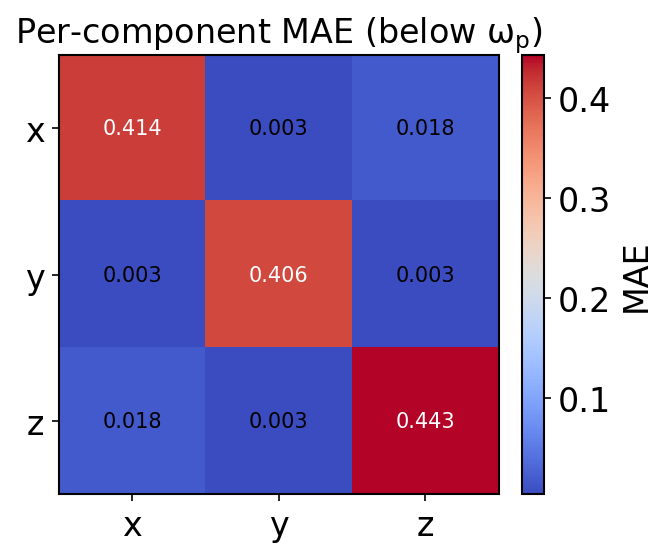

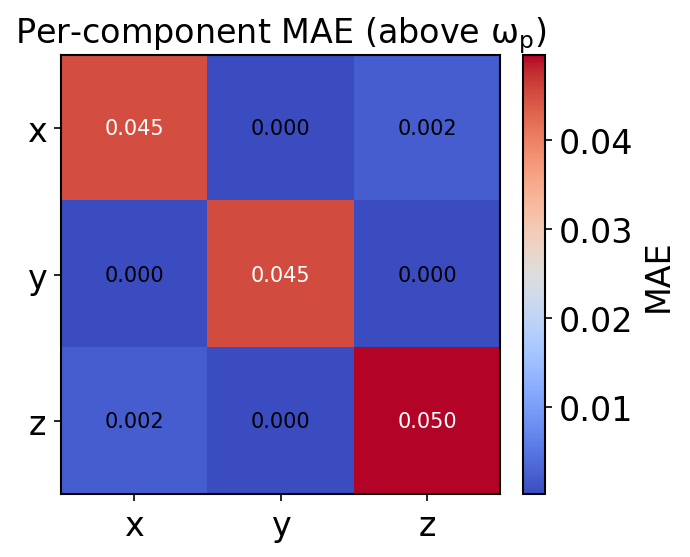

In [7]:
triu_idx = np.triu_indices(3)
component_labels = ["xx", "xy", "xz", "yy", "yz", "zz"]

def mae_symmetric_components(pred, true, mask=None):
    """
    pred, true: (F,3,3) or (N,F,3,3)
    mask: optional boolean array over F (frequency axis)
    Returns dict of per-component and overall MAE.
    """
    pred = np.array(pred)
    true = np.array(true)

    if mask is not None:
        pred = pred[mask]
        true = true[mask]

    if pred.shape[0] == 0:  # no frequencies in mask
        return {k: np.nan for k in ["all"] + component_labels}

    diff = np.abs(pred - true)  # (F,3,3)
    comp_means = {}
    vals = []
    for (i, j), label in zip(zip(triu_idx[0], triu_idx[1]), component_labels):
        m = diff[:, i, j].mean()
        comp_means[label] = m
        vals.append(m)
    comp_means["all"] = np.mean(vals)  # equal-weight avg
    return comp_means

def compute_mae_split_plasma(row):
    """
    Compute overall and per-component MAE split by
    omega < omega_p and omega >= omega_p.
    """
    omega = np.array(row["energies_interp"])
    mask_below = omega < row["omega_p_loss"]
    mask_above = omega >= row["omega_p_loss"]

    y_true = row["rel_permittivity_imag_interp"]  # (F,3,3)
    y_pred = row["y_pred_cart"]                   # (F,3,3)

    res_below = mae_symmetric_components(y_pred, y_true, mask_below)
    res_above = mae_symmetric_components(y_pred, y_true, mask_above)

    return pd.Series({
        "mae_cart_below": res_below["all"],
        **{f"mae_cart_{lbl}_below": res_below[lbl] for lbl in component_labels},
        "mae_cart_above": res_above["all"],
        **{f"mae_cart_{lbl}_above": res_above[lbl] for lbl in component_labels},
    })
# Apply to test set
df_test_split = df_test.join(df_test.apply(compute_mae_split_plasma, axis=1))

# Print averages below/above
print("Overall MAE below plasma frequency:", df_test_split["mae_cart_below"].mean())
print("Overall MAE above plasma frequency:", df_test_split["mae_cart_above"].mean())

print("Per-component means (below ωp):")
for comp in ["xx","yy","zz","xy","xz","yz"]:
    print(f"  {comp}: {df_test_split[f'mae_cart_{comp}_below'].mean()}")

print("Per-component means (above ωp):")
for comp in ["xx","yy","zz","xy","xz","yz"]:
    print(f"  {comp}: {df_test_split[f'mae_cart_{comp}_above'].mean()}")

def plot_mae_heatmap(df, mode="below"):
    """
    Show 3x3 heatmap of per-component MAE averaged across dataset.
    mode: "below" or "above"
    """
    # Collect mean MAE for each component
    means = {comp: df[f"mae_cart_{comp}_{mode}"].mean() for comp in component_labels}

    # Fill symmetric 3x3 matrix
    mat = np.zeros((3, 3))
    for (i, j), label in zip(zip(triu_idx[0], triu_idx[1]), component_labels):
        mat[i, j] = means[label]
        mat[j, i] = means[label]  # symmetry

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(mat, cmap="coolwarm", origin="upper")

    # Annotate each cell
    for i in range(3):
        for j in range(3):
            ax.text(
                j, i, f"{mat[i,j]:.3f}",
                ha="center", va="center",
                color="black" if abs(mat[i,j]) < mat.max()/2 else "white",
                fontsize=10
            )

    # Axis labels
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(["x", "y", "z"])
    ax.set_yticklabels(["x", "y", "z"])
    ax.set_title(rf"Per-component MAE ({mode} $\omega_p$)", fontsize=fontsize)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("MAE")

    plt.tight_layout()
    plt.show()


# Example: plot below and above
plot_mae_heatmap(df_test_split, mode="below")
plot_mae_heatmap(df_test_split, mode="above")

# sampled

/tmp/ipykernel_816588/679331502.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


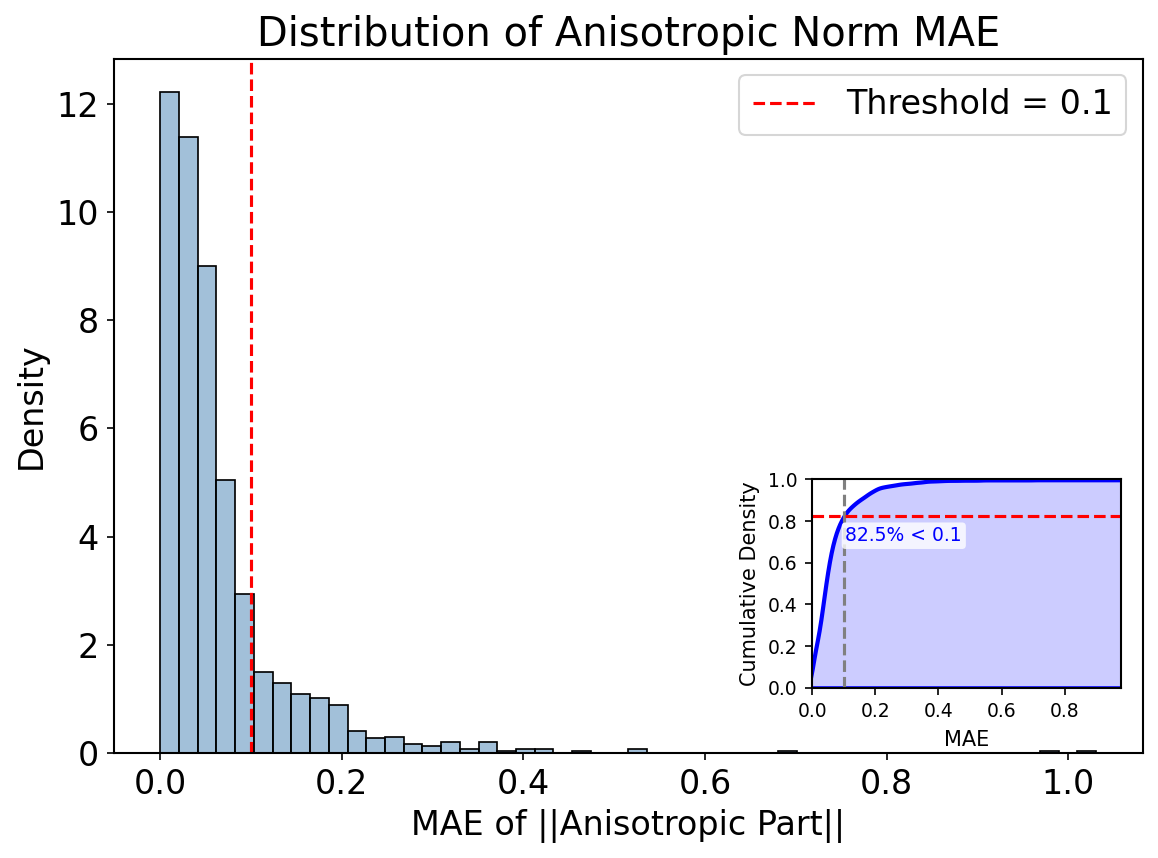

mean $MAE_{aniso}$ 0.1313191924351164 median $MAE_{aniso}$ 0.11401965019282682


In [8]:
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import numpy as np

# Ensure clean data
def decompose_tensor_seq(tensor_seq):
    iso_parts = []
    aniso_parts = []
    for tensor in tensor_seq:
        iso, aniso = decompose_tensor((tensor + tensor.T.conj()) / 2)
        iso_parts.append(iso)
        aniso_parts.append(aniso)
    return np.array(iso_parts), np.array(aniso_parts)

def decompose_tensor(tensor):
    """
    Input: tensor of shape (3, 3)
    Returns: (iso_part, aniso_part), both (3, 3)
    """
    iso_scalar = np.trace(tensor) / 3
    iso_part = iso_scalar * np.eye(3)
    aniso_part = tensor - iso_part
    return iso_part, aniso_part

def anisotropy_strength(aniso_seq):
    return np.linalg.norm(aniso_seq, axis=(1,2))  # [n_freq]

def compute_aniso_mae(row):
    true_tensor = row["rel_permittivity_imag_interp"]  # shape (N_ω, 3, 3)
    pred_tensor = row["y_pred_cart"]

    # Decompose into isotropic + anisotropic parts
    true_iso, true_aniso = decompose_tensor_seq(true_tensor)
    pred_iso, pred_aniso = decompose_tensor_seq(pred_tensor)

    # --- (1) Component-wise anisotropic MAE ---
    # flatten component-wise tensors across all ω
    comp_diff = np.abs(true_aniso - pred_aniso)  # shape (N_ω, 3, 3)
    triu_idx = np.triu_indices(3)
    comp_diff_unique = comp_diff[:, triu_idx[0], triu_idx[1]]
    comp_mae = np.mean(comp_diff_unique[np.isfinite(comp_diff_unique)])

    # --- (2) Anisotropy strength MAE ---
    true_norm = anisotropy_strength(true_aniso)  # (N_ω,)
    pred_norm = anisotropy_strength(pred_aniso)  # (N_ω,)

    mask = np.isfinite(true_norm) & np.isfinite(pred_norm)
    if np.sum(mask) == 0:
        return pd.Series({"aniso_comp_mae": np.nan, "aniso_norm_mae": np.nan})

    norm_mae = np.mean(np.abs(true_norm[mask] - pred_norm[mask]))

    return pd.Series({
        "aniso_comp_mae": comp_mae,
        "aniso_norm_mae": norm_mae
    })


df[["aniso_comp_mae", "aniso_norm_mae"]] = df.apply(compute_aniso_mae, axis=1)
# df = df.loc[idx_test].copy().reset_index()
aniso_mae = df['aniso_norm_mae'].dropna().values
threshold = 0.1

# Create main plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(aniso_mae, bins=50, stat='density', ax=ax, color='steelblue', alpha=0.5)
ax.set_xlabel("MAE of ||Anisotropic Part||")
ax.set_ylabel("Density")
ax.set_title("Distribution of Anisotropic Norm MAE")
ax.axvline(x=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold}')
ax.legend()
# Create inset axes
inset_ax = inset_axes(ax, width="30%", height="30%", loc='lower right', 
                      bbox_to_anchor=(-0.005, 0.07, 1, 1), bbox_transform=ax.transAxes)

# KDE CDF
sns.kdeplot(aniso_mae, ax=inset_ax, color='blue', fill=True, cumulative=True,
            bw_adjust=0.5, alpha=0.2, linewidth=2)

# Axes settings
inset_ax.set_xlabel("MAE", fontsize=10)
inset_ax.set_ylabel("Cumulative Density", fontsize=10)
inset_ax.tick_params(axis='both', labelsize=9)
inset_ax.set_xlim(0, np.max(aniso_mae) * 0.95)
inset_ax.set_ylim(0, 1)

# Compute % below threshold
perc_below = np.mean(aniso_mae < threshold) * 100
inset_ax.axvline(x=threshold, color='gray', linestyle='--', linewidth=1.5)
inset_ax.axhline(y=perc_below / 100, color='red', linestyle='--', linewidth=1.5)

inset_ax.text(threshold + 0.005, perc_below / 100 - 0.05,
              f'{perc_below:.1f}% < {threshold}',
              color='blue', fontsize=9, ha='left', va='top',
              bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()



df_train = df.loc[idx_train].copy().reset_index()
df_valid = df.loc[idx_valid].copy().reset_index()
df_test = df.loc[idx_test].copy().reset_index()

# print(df_train['mae_cart'].mean())
# print(df_valid['mae_cart'].mean())
print(rf"mean $MAE_{{aniso}}$", df_test['aniso_norm_mae'].mean(), f"median $MAE_{{aniso}}$", df_test['aniso_norm_mae'].median())

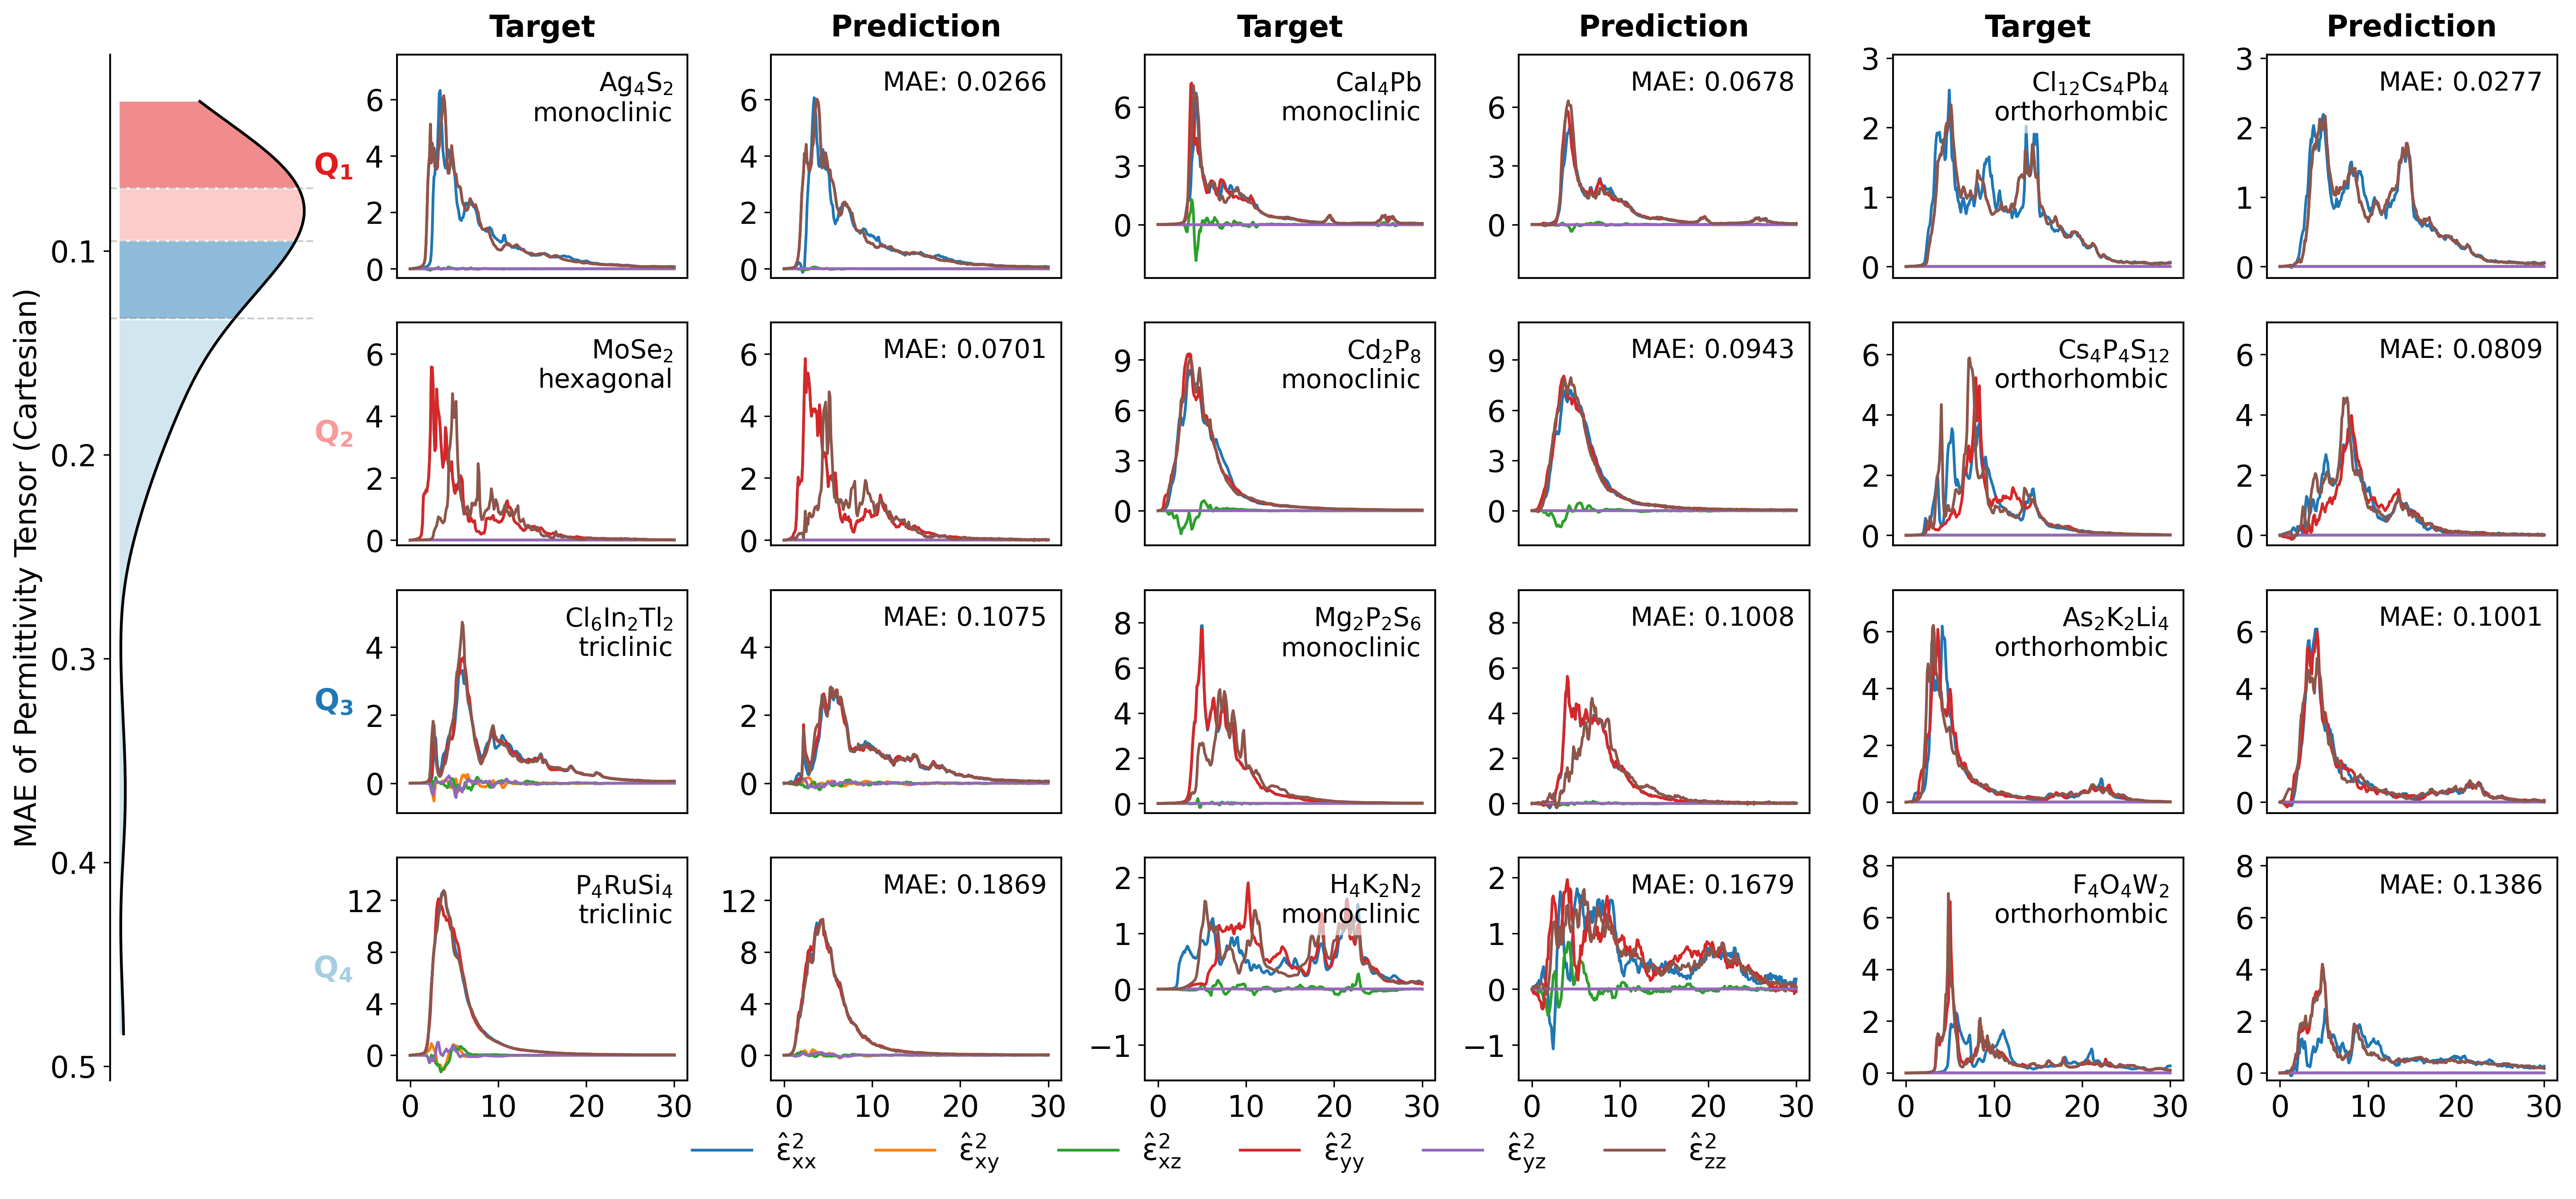

In [9]:
def stratified_sample_by_system(
    df, idx_test,
    systems=["triclinic", "monoclinic", "orthorhombic"],
    n_per_quartile=3,
    mae_column="mae_cart"
):
    df_test = df.loc[idx_test].copy()
    df_test["mae_quartile"] = pd.qcut(
        df_test[mae_column].rank(method="first"),
        q=4, labels=False, duplicates="drop"
    )

    grouped = []
    for q in range(4):
        q_bin = df_test[df_test["mae_quartile"] == q]
        if q_bin.empty:
            grouped.append([None] * len(systems))
            continue

        samples = []
        for sys in systems:
            group = q_bin[q_bin["crystal_system"] == sys]
            if not group.empty:
                samples.append(group.sample(1, random_state=13).index[0]) #4 3 14
            else:
                best_idx = q_bin[mae_column].idxmin()
                samples.append(best_idx)
        grouped.append(samples)

    return grouped

def plot_quartile_kde(ax, mae_values, colors):
    y_max = np.quantile(mae_values, 0.995)
    y = np.linspace(mae_values.min(), y_max, 500)
    kde = gaussian_kde(mae_values)
    p = kde.pdf(y)

    quartiles = np.quantile(mae_values, (0.25, 0.5, 0.75, 1.0))
    qs = list(quartiles)[::-1] + [0]

    ax.plot(p, y, color="black")
    for i in range(len(qs)-1):
        mask = (y >= qs[i+1]) & (y <= qs[i])
        ax.fill_betweenx(y[mask], 0, p[mask],
                         color=colors[i], lw=0, alpha=0.5)

    for q in np.quantile(mae_values, (0.25, 0.5, 0.75)):
        ax.axhline(q, color="gray", linestyle="--", linewidth=1, alpha=0.4)

    ax.set_ylabel("MAE of Permittivity Tensor (Cartesian)")
    ax.set_xticks([])
    ax.ticklabel_format(axis="y")
    ax.invert_yaxis()
    for spine in ["top", "right", "bottom"]:
        ax.spines[spine].set_visible(False)

# ======================================================
# Combined plotting
# ======================================================
def plot_cartesian_tensor_comparison_by_quartile(df, grouped_idx, column_name,
                                                 mae_cart, title_prefix=""):
    xyz_list = ['x', 'y', 'z']
    tensor_components = [rf"$\hat\epsilon^2_{{{xyz_list[a]}{xyz_list[b]}}}$"
                         for a in range(3) for b in range(a, 3)]
    colors = ["#a6cee3", "#1f78b4", "#fb9a99", "#e31a1c"]

    # Layout: 4 rows, KDE column + 6 spectra columns
    fig = plt.figure(figsize=(22, 10), dpi=300)
    gs = GridSpec(4, 7, width_ratios=[0.7] + [1]*6, wspace=0.3, hspace=0.2)

    # Left KDE
    ax_kde = fig.add_subplot(gs[:, 0])
    plot_quartile_kde(ax_kde, mae_cart, colors)

    handles, labels = [], []
    sample_idx = 0
    rightmost_ax_per_row = [None] * len(grouped_idx)
    leftmost_ax_per_row = [None] * len(grouped_idx)

    # Spectra grid (4 rows, 6 columns = 3 systems per row * [real,pred])
    for row_idx, quartile_group in enumerate(grouped_idx):
        last_ax_pred = None
        first_ax_real = None
        for col_idx, idx_val in enumerate(quartile_group):
            ds_row = df.loc[idx_val]
            omega = ds_row["energies_interp"]
            real = ds_row[column_name]
            pred = ds_row["y_pred_cart"]
            formula = format_chemical_formula(ds_row["formula"])
            system = ds_row["crystal_system"]
            mae = ds_row["mae_cart"]

            y_min = min(real.min(), pred.min())
            y_max = max(real.max(), pred.max())

            # assign two axes: real vs pred
            ax_real = fig.add_subplot(gs[row_idx, col_idx*2+1])
            ax_pred = fig.add_subplot(gs[row_idx, col_idx*2+2])
            last_ax_pred = ax_pred
            if first_ax_real is None:
                first_ax_real = ax_real   # store leftmost axis for this row

            for i, (a, b) in enumerate([(x, y) for x in range(3) for y in range(x, 3)]):
                h, = ax_real.plot(omega, real[:, a, b], label=tensor_components[i])
                ax_pred.plot(omega, pred[:, a, b])
                if sample_idx == 0:
                    handles.append(h)
                    labels.append(tensor_components[i])


            for ax in (ax_real, ax_pred):
                ax.set_ylim((y_min - 0.1) * 1.4, y_max * 1.2)
                ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
                ax.set_xticks([])
            if row_idx == len(grouped_idx) - 1:
                for ax in (ax_real, ax_pred):
                    ax.set_xticks(np.linspace(omega[0], omega[-1], 4, dtype=int))
                    
            if row_idx == 0:
                ax_real.set_title("Target", fontsize=fontsize, pad=10, fontweight="bold")
                ax_pred.set_title("Prediction", fontsize=fontsize, pad=10, fontweight="bold")

            ax_real.text(0.95, 0.93, f"${formula}$\n{system}",
                         transform=ax_real.transAxes, fontsize=fontsize-2,
                         va='top', ha='right',
                         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

            ax_pred.text(0.95, 0.93, f"MAE: {mae:.4f}",
                         transform=ax_pred.transAxes, fontsize=fontsize-2,
                         va='top', ha='right',
                         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

            sample_idx += 1

        rightmost_ax_per_row[row_idx] = last_ax_pred
        leftmost_ax_per_row[row_idx] = first_ax_real   # store per row

    # Leave margin on the right
    fig.subplots_adjust(right=0.96)

    # Add quantile labels aligned with rows (anchored to leftmost subplot)
    row_labels = [r"$Q_1$", r"$Q_2$", r"$Q_3$", r"$Q_4$"]
    row_labels_color = colors[::-1]
    for row_idx, ax_left in enumerate(leftmost_ax_per_row):
        if ax_left is None:
            continue
        bbox = ax_left.get_position()
        y = 0.5 * (bbox.y0 + bbox.y1)
        x_left = bbox.x0 - 0.015

        fig.text(x_left, y, row_labels[row_idx],
                 fontsize=fontsize, fontweight="bold", color = row_labels_color[row_idx], #color="black",
                 va="center", ha="right", rotation=0)

    fig.legend(handles, labels, loc="lower center",
               bbox_to_anchor=(0.5, 0.02), ncol=6, fontsize=fontsize, frameon=False)

    os.makedirs("../pngs", exist_ok=True)
    fig.savefig(f"../pngs/{title_prefix}_quartile_combined.png", dpi=500)
    plt.show()

# ======================================================
# Usage
# ======================================================
# grouped_idx = sample_by_mae_quartiles(df, idx_test, n_per_quartile=3)
df_test = df.loc[idx_test].copy()

grouped_idx = stratified_sample_by_system(df, idx_test, n_per_quartile=3, mae_column="mae_cart")
plot_cartesian_tensor_comparison_by_quartile(
    df_test, grouped_idx, column_name=column, mae_cart=df_test['mae_cart'],
    title_prefix="mae_cart_quartiles"
)

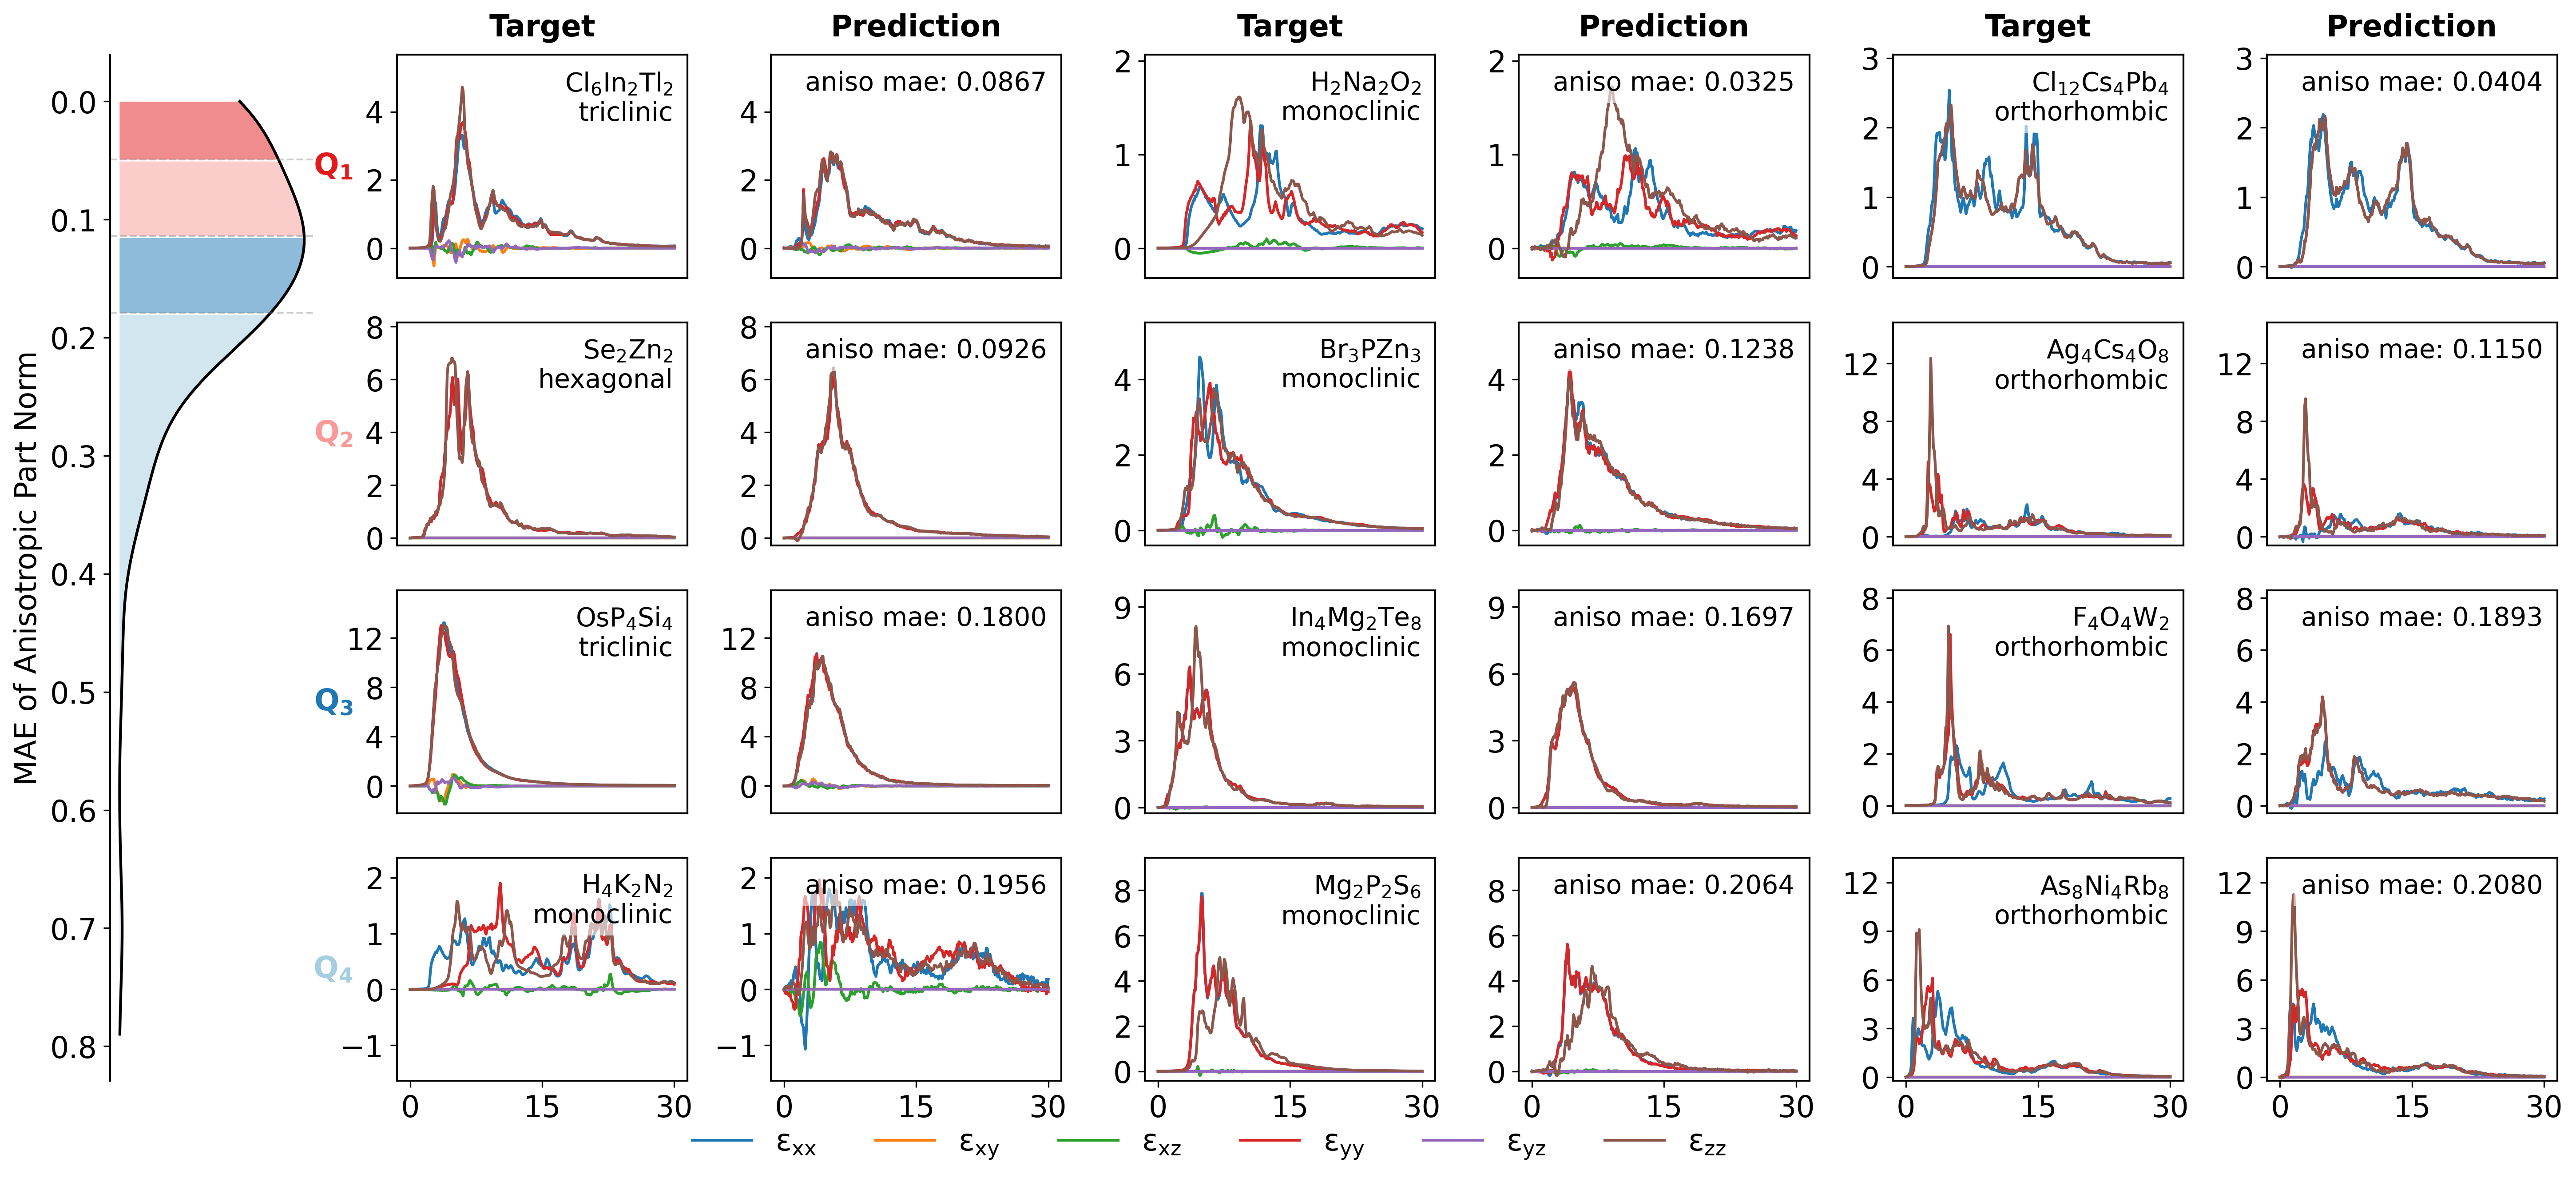

In [10]:
def stratified_sample_by_system(
    df, idx_test,
    systems=["triclinic", "monoclinic", "orthorhombic"],
    n_per_quartile=3,
    mae_column="mae_cart",
    random_state=28
):
    df_test = df.loc[idx_test].copy()
    df_test = df_test[df_test["crystal_system"] != "cubic"]

    # assign quartiles
    df_test["mae_quartile"] = pd.qcut(
        df_test[mae_column].rank(method="first"),
        q=4, labels=False, duplicates="drop"
    )

    selected = set()
    grouped = []

    for q in range(4):
        q_bin = df_test[df_test["mae_quartile"] == q]
        if q_bin.empty:
            grouped.append([None] * len(systems))
            continue

        samples = []
        for sys in systems:
            group = q_bin[q_bin["crystal_system"] == sys]
            group = group[~group.index.isin(selected)]  # remove already chosen indices
            if not group.empty:
                idx = group.sample(1, random_state=random_state).index[0]
            else:
                # fallback: pick the lowest MAE not yet chosen
                remaining = q_bin[~q_bin.index.isin(selected)]
                idx = remaining[mae_column].idxmin() if not remaining.empty else None
            samples.append(idx)
            if idx is not None:
                selected.add(idx)
        grouped.append(samples)

    return grouped
def plot_quartile_kde(ax, mae_values, colors):
    y_max = np.quantile(mae_values, 0.995)
    y = np.linspace(mae_values.min(), y_max, 500)
    kde = gaussian_kde(mae_values)
    p = kde.pdf(y)

    quartiles = np.quantile(mae_values, (0.25, 0.5, 0.75, 1.0))
    qs = list(quartiles)[::-1] + [0]

    ax.plot(p, y, color="black")
    for i in range(len(qs)-1):
        mask = (y >= qs[i+1]) & (y <= qs[i])
        ax.fill_betweenx(y[mask], 0, p[mask],
                         color=colors[i], lw=0, alpha=0.5)

    for q in np.quantile(mae_values, (0.25, 0.5, 0.75)):
        ax.axhline(q, color="gray", linestyle="--", linewidth=1, alpha=0.4)

    ax.set_ylabel("MAE of Anisotropic Part Norm")
    ax.set_xticks([])
    ax.ticklabel_format(axis="y")
    ax.invert_yaxis()
    for spine in ["top", "right", "bottom"]:
        ax.spines[spine].set_visible(False)

# ======================================================
# Combined plotting
# ======================================================
def plot_cartesian_tensor_comparison_by_quartile(df, grouped_idx, column_name,
                                                 mae_cart, title_prefix=""):
    xyz_list = ['x', 'y', 'z']
    tensor_components = [f"$\\epsilon_{{{xyz_list[a]}{xyz_list[b]}}}$"
                         for a in range(3) for b in range(a, 3)]
    colors = ["#a6cee3", "#1f78b4", "#fb9a99", "#e31a1c"]

    # Layout: 4 rows, KDE column + 6 spectra columns
    fig = plt.figure(figsize=(22, 10), dpi=300)
    gs = GridSpec(4, 7, width_ratios=[0.7] + [1]*6, wspace=0.3, hspace=0.2)

    # Left KDE
    ax_kde = fig.add_subplot(gs[:, 0])
    plot_quartile_kde(ax_kde, mae_cart, colors)

    handles, labels = [], []
    sample_idx = 0
    rightmost_ax_per_row = [None] * len(grouped_idx)
    leftmost_ax_per_row = [None] * len(grouped_idx)

    # Spectra grid (4 rows, 6 columns = 3 systems per row * [real,pred])
    for row_idx, quartile_group in enumerate(grouped_idx):
        last_ax_pred = None
        first_ax_real = None
        for col_idx, idx_val in enumerate(quartile_group):
            ds_row = df.loc[idx_val]
            omega = ds_row["energies_interp"]
            real = ds_row[column_name]
            pred = ds_row["y_pred_cart"]
            formula = format_chemical_formula(ds_row["formula"])
            system = ds_row["crystal_system"]
            mae = ds_row["aniso_norm_mae"]

            y_min = min(real.min(), pred.min())
            y_max = max(real.max(), pred.max())

            # assign two axes: real vs pred
            ax_real = fig.add_subplot(gs[row_idx, col_idx*2+1])
            ax_pred = fig.add_subplot(gs[row_idx, col_idx*2+2])
            last_ax_pred = ax_pred
            if first_ax_real is None:
                first_ax_real = ax_real   # store leftmost axis for this row

            for i, (a, b) in enumerate([(x, y) for x in range(3) for y in range(x, 3)]):
                h, = ax_real.plot(omega, real[:, a, b], label=tensor_components[i])
                ax_pred.plot(omega, pred[:, a, b])
                if sample_idx == 0:
                    handles.append(h)
                    labels.append(tensor_components[i])

            for ax in (ax_real, ax_pred):
                ax.set_ylim((y_min - 0.1) * 1.4, y_max * 1.2)
                ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
                ax.set_xticks([])
            if row_idx == len(grouped_idx) - 1:
                for ax in (ax_real, ax_pred):
                    ax.set_xticks([omega[0], int(omega[-1] / 2), omega[-1]])

            if row_idx == 0:
                ax_real.set_title("Target", fontsize=fontsize, pad=10, fontweight="bold")
                ax_pred.set_title("Prediction", fontsize=fontsize, pad=10, fontweight="bold")

            ax_real.text(0.95, 0.93, f"${formula}$\n{system}",
                         transform=ax_real.transAxes, fontsize=fontsize-2,
                         va='top', ha='right',
                         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

            ax_pred.text(0.95, 0.93, f"aniso mae: {mae:.4f}",
                         transform=ax_pred.transAxes, fontsize=fontsize-2,
                         va='top', ha='right',
                         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

            sample_idx += 1

        rightmost_ax_per_row[row_idx] = last_ax_pred
        leftmost_ax_per_row[row_idx] = first_ax_real   # store per row

    # Leave margin on the right
    fig.subplots_adjust(right=0.96)

    # Add quantile labels aligned with rows (anchored to leftmost subplot)
    row_labels = [r"$Q_1$", r"$Q_2$", r"$Q_3$", r"$Q_4$"]
    row_labels_color = colors[::-1]
    for row_idx, ax_left in enumerate(leftmost_ax_per_row):
        if ax_left is None:
            continue
        bbox = ax_left.get_position()
        y = 0.5 * (bbox.y0 + bbox.y1)
        x_left = bbox.x0 - 0.015

        fig.text(x_left, y, row_labels[row_idx],
                 fontsize=fontsize, fontweight="bold", color = row_labels_color[row_idx], #color="black",
                 va="center", ha="right", rotation=0)

    fig.legend(handles, labels, loc="lower center",
               bbox_to_anchor=(0.5, 0.03), ncol=6, fontsize=fontsize, frameon=False)

    os.makedirs("../pngs", exist_ok=True)
    fig.savefig(f"../pngs/{title_prefix}_quartile_combined.png", dpi=500)
    plt.show()

# ======================================================
# Usage
# ======================================================
# grouped_idx = sample_by_mae_quartiles(df, idx_test, n_per_quartile=3)
df_test = df.loc[idx_test].copy()

grouped_idx = stratified_sample_by_system(df, idx_test, n_per_quartile=3, mae_column="aniso_norm_mae")

plot_cartesian_tensor_comparison_by_quartile(
    df_test, grouped_idx, column_name=column, mae_cart=df_test['aniso_norm_mae'],
    title_prefix="aniso_mae_quartiles"
)

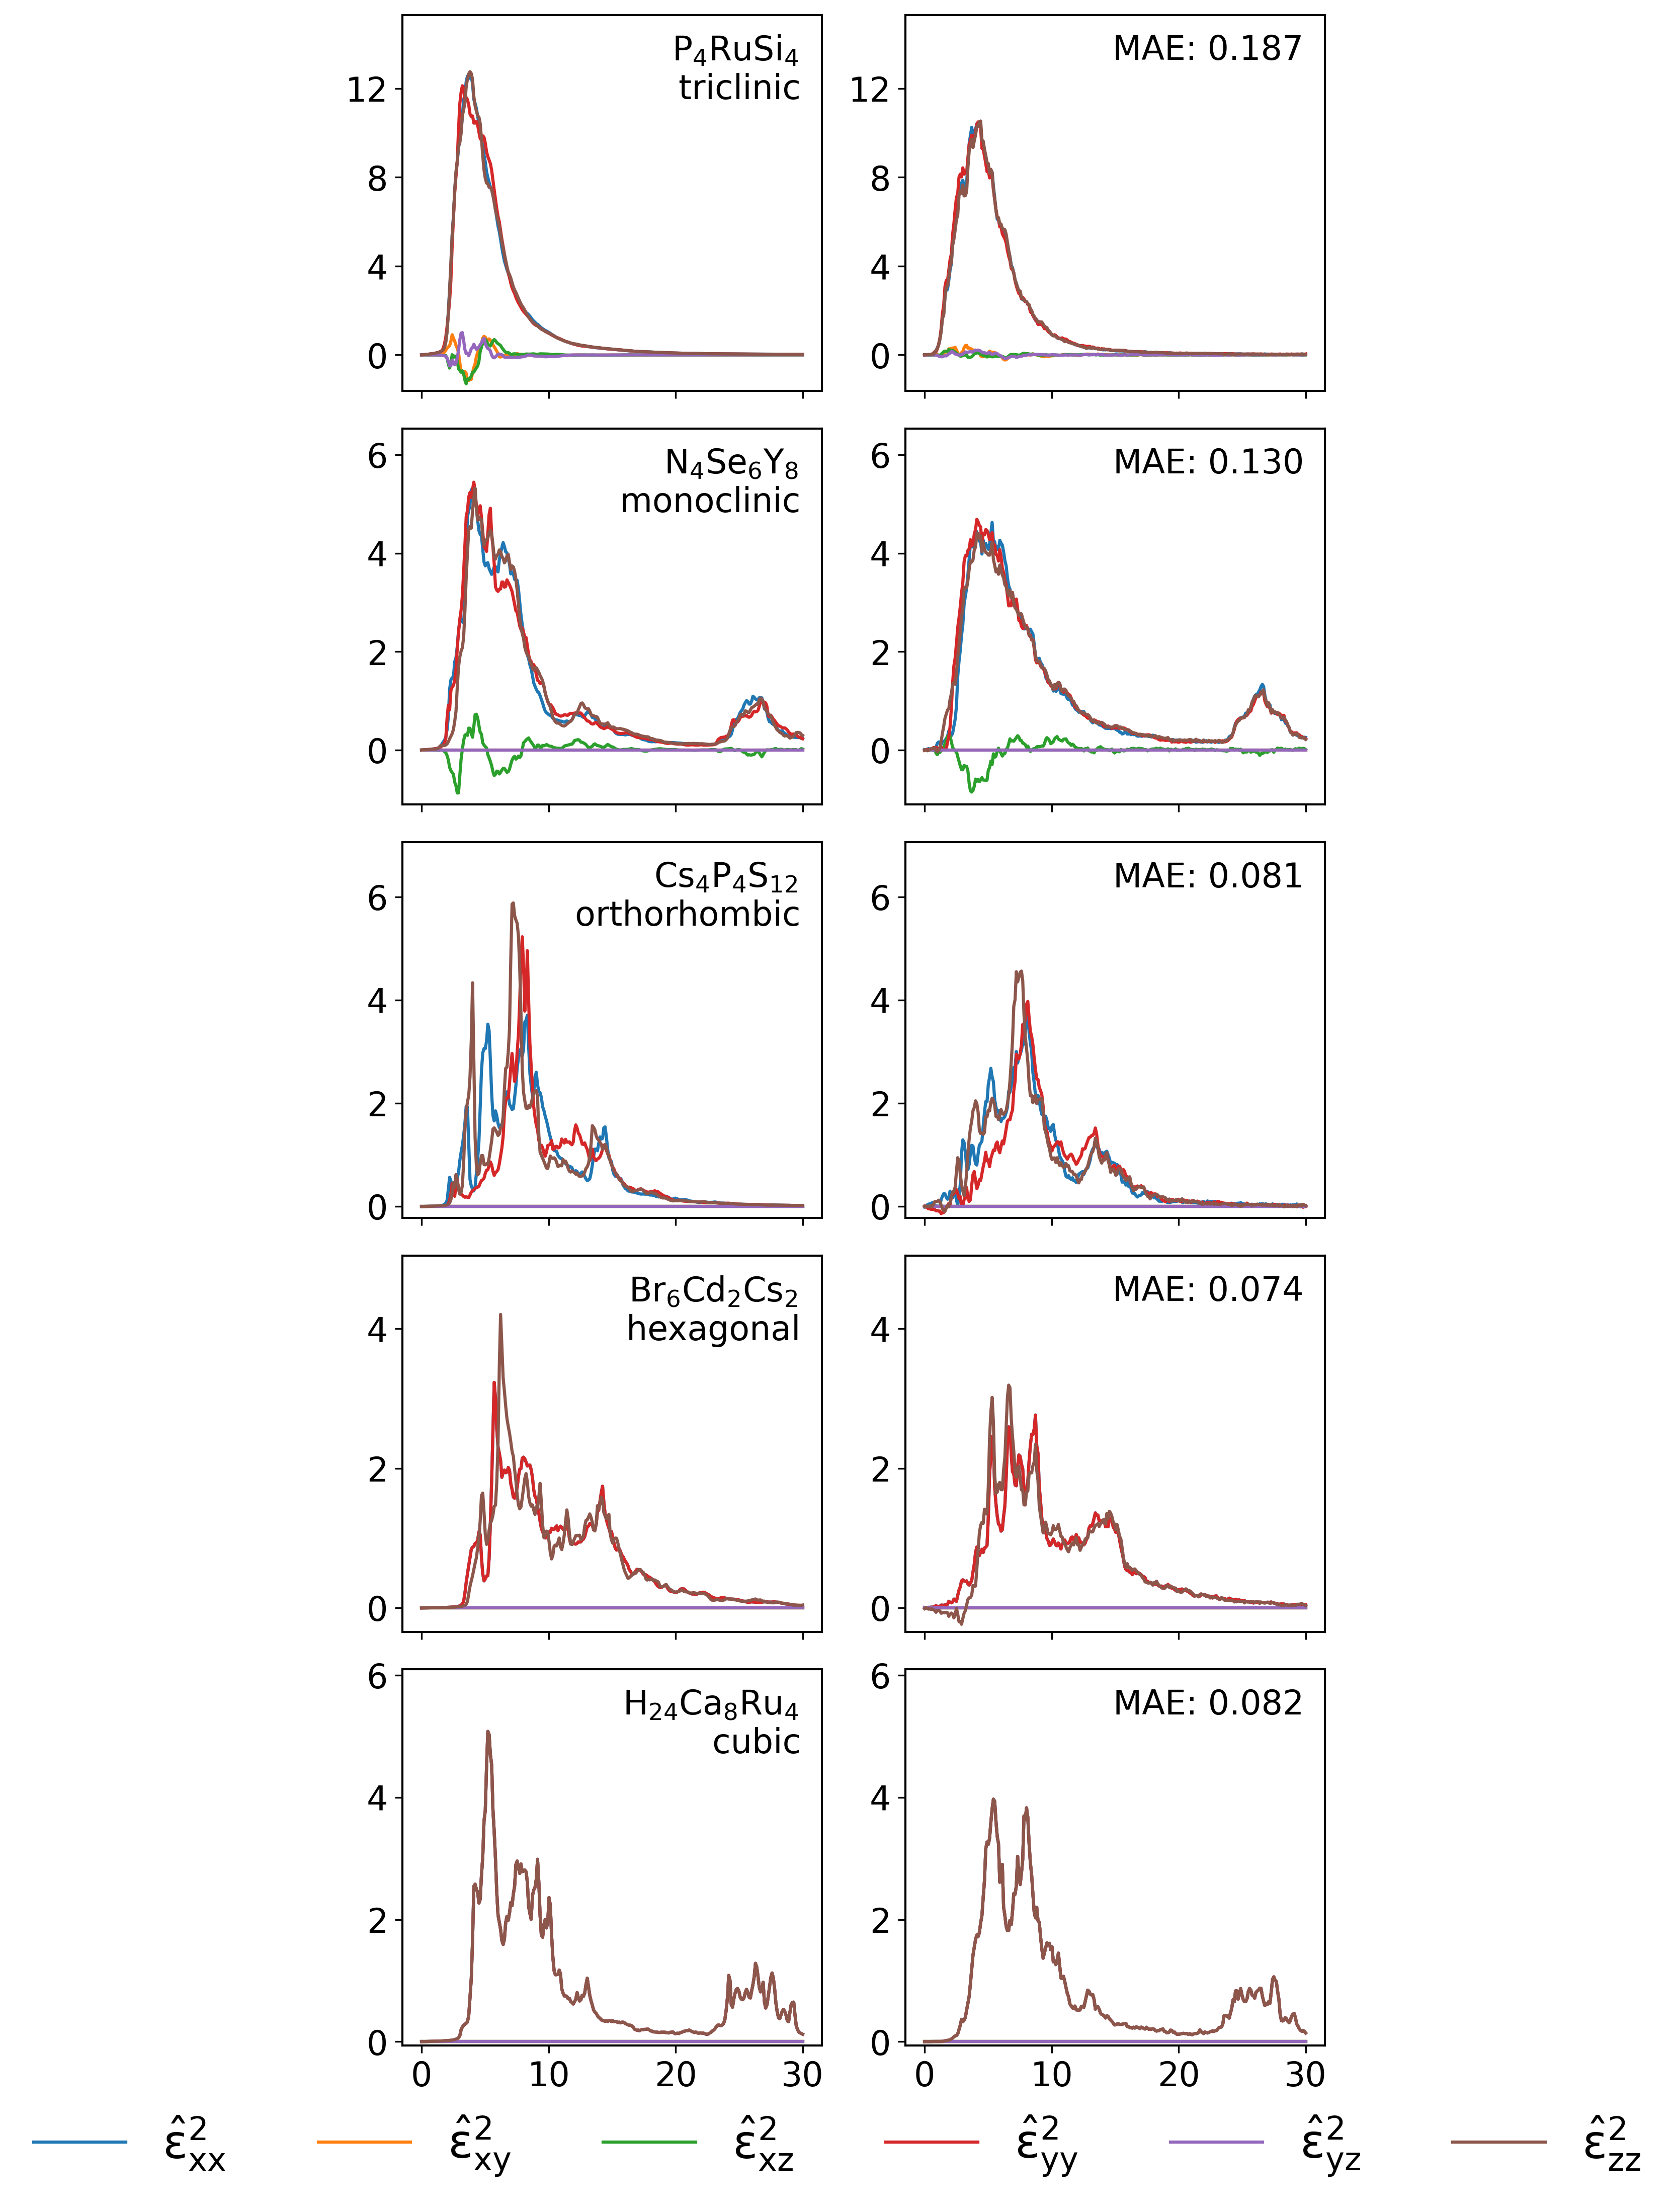

In [11]:
def get_one_sample_per_crystal_system(df, idx_test, target_systems, random_seed=None):
    """
    Returns one index per crystal system from the test set, ordered from low to high symmetry.

    Parameters:
    - df: Full dataframe with 'crystal_system' column.
    - idx_test: List of indices belonging to the test set.
    - target_systems: List of crystal systems to include.

    Returns:
    - List of indices corresponding to one sample per crystal system, ordered by symmetry.
    """
    import random
    idx_test = list(idx_test)  
    random.seed(24)
    random.shuffle(idx_test)

    # Define symmetry order from low to high
    symmetry_order = [
        "triclinic",
        "monoclinic",
        "orthorhombic",
        "tetragonal",
        "trigonal",
        "hexagonal",
        "cubic",
    ]

    # Filter the list to only those in target_systems, in the desired order
    ordered_targets = [s for s in symmetry_order if s in target_systems]

    # Create a lookup: crystal_system -> index
    system_to_index = {}
    seen_systems = set()

    for idx in idx_test:
        system = df.loc[idx, "crystal_system"]
        if system in ordered_targets and system not in seen_systems:
            system_to_index[system] = idx
            seen_systems.add(system)
        if len(seen_systems) == len(ordered_targets):
            break

    # Return indices in the desired symmetry order
    return [system_to_index[system] for system in ordered_targets if system in system_to_index]

    
    # return selected_indices
def plot_cartesian_tensor_comparison(df, idx, column_name, title_prefix="", n=3, show_legend=True, shared_xlabel=None, mae_column="mae_cart", xlabel_fontsize=18, shared_xlabel_y_pos = 0.09):
    # Filter DataFrame based on provided indices
    ds = df.iloc[idx].reset_index(drop=True)

    xyz_list = ['x', 'y', 'z']
    tensor_components = [f"$\\hat{{\\epsilon}}^2_{{{xyz_list[a]}{xyz_list[b]}}}$" for a in range(3) for b in range(a, 3)]

    n_rows = n
    n_cols = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3 * n_rows), dpi=300, sharex=True)
    axes = axes.ravel()

    handles, labels = [], []

    for i, sample_idx in enumerate(idx[:n]):
        material_id = ds.iloc[i]['mp_id']
        mae_val = ds.iloc[i][mae_column]  # renamed to mae_val to avoid confusion
        crystal_system = ds.iloc[i]['crystal_system']
        formula = ds.iloc[i]['formula']
        omega = ds["energies_interp"].iloc[i]
        formatted_formula = format_chemical_formula(formula)
        real_permittivity = ds[column_name].iloc[i]
        pred_permittivity = ds["y_pred_cart"].iloc[i]

        # OPTIONAL quartile label (string like "Q1"/"Q2"/...)
        quartile_label = ds.iloc[i].get("quartile_label", "")  # if not present, becomes ""

        y_min = min(real_permittivity.min(), pred_permittivity.min())
        y_max = max(real_permittivity.max(), pred_permittivity.max())

        # Left subplot: True
        ax_real = axes[2 * i]
        for comp_idx, (a, b) in enumerate([(x, y) for x in range(3) for y in range(x, 3)]):
            h, = ax_real.plot(omega, real_permittivity[:, a, b], label=tensor_components[comp_idx], linestyle='-')
            if i == 0:
                handles.append(h)
                labels.append(tensor_components[comp_idx])
        if column_name == "real_Permittivity_Matrices_interp":
            ax_real.set_ylim((y_min - 0.1) * 1.2, y_max * 1.2)
        else:
            ax_real.set_ylim((y_min - 0.05) * 1.2, y_max * 1.2)
        ax_real.text(
            0.95, 0.95,
            f"${formatted_formula}$ \n {crystal_system}",
            transform=ax_real.transAxes, fontsize=16, va='top', ha='right',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
        )
        ax_real.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

        # Right subplot: Pred
        ax_pred = axes[2 * i + 1]
        for comp_idx, (a, b) in enumerate([(x, y) for x in range(3) for y in range(x, 3)]):
            ax_pred.plot(omega, pred_permittivity[:, a, b], linestyle='-')
        if column_name == "real_Permittivity_Matrices_interp":
            ax_pred.set_ylim((y_min - 0.1) * 1.2, y_max * 1.2)
        else:
            ax_pred.set_ylim((y_min - 0.05) * 1.2, y_max * 1.2)

        # ---- Text box on right: include Q-label with aniso-norm MAE ----
        if mae_column == "mae_cart":
            text_lines = [f"MAE: {mae_val:4.3f}"]
        elif mae_column == "aniso_norm_mae":
            text_lines = []
            if quartile_label:            # prepend Q1/Q2/Q3/Q4 if available
                text_lines.append(quartile_label)
            text_lines.append(rf"$MAE_{{aniso}}^{{norm}}$: {mae_val:4.3f}")
        else:
            text_lines = [f"{mae_column}: {mae_val:4.3f}"]

        ax_pred.text(
            0.95, 0.95,
            "\n".join(text_lines),
            transform=ax_pred.transAxes,
            fontsize=16, va='top', ha='right',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
        )
        ax_pred.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

    for ax in axes:
        ax.set_xticks([])
        ax.tick_params(axis='y', labelsize=16)
    for ax in axes[-n_cols:]:
        ax.set_xticks(np.linspace(min(omega), max(omega), 4))
        ax.tick_params(axis='x', labelsize=16)

    if show_legend:
        fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=6, fontsize=22, frameon=False)
    if shared_xlabel:
        fig.supxlabel(shared_xlabel, fontsize=xlabel_fontsize, y=shared_xlabel_y_pos, x = 0.5)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.subplots_adjust(wspace=0.2, hspace=0.1)
    os.makedirs("../pngs", exist_ok=True)
    save_path = f"../pngs/{title_prefix}_cart_spectra.png"
    fig.savefig(save_path, dpi=300)
    plt.show()

target_systems = ['triclinic', 'monoclinic', 'orthorhombic', 'hexagonal', 'cubic']
representative_idx = get_one_sample_per_crystal_system(df, idx_test, target_systems)
plot_cartesian_tensor_comparison(df, representative_idx, column_name=column, title_prefix="five_crystal_systems", n=5)


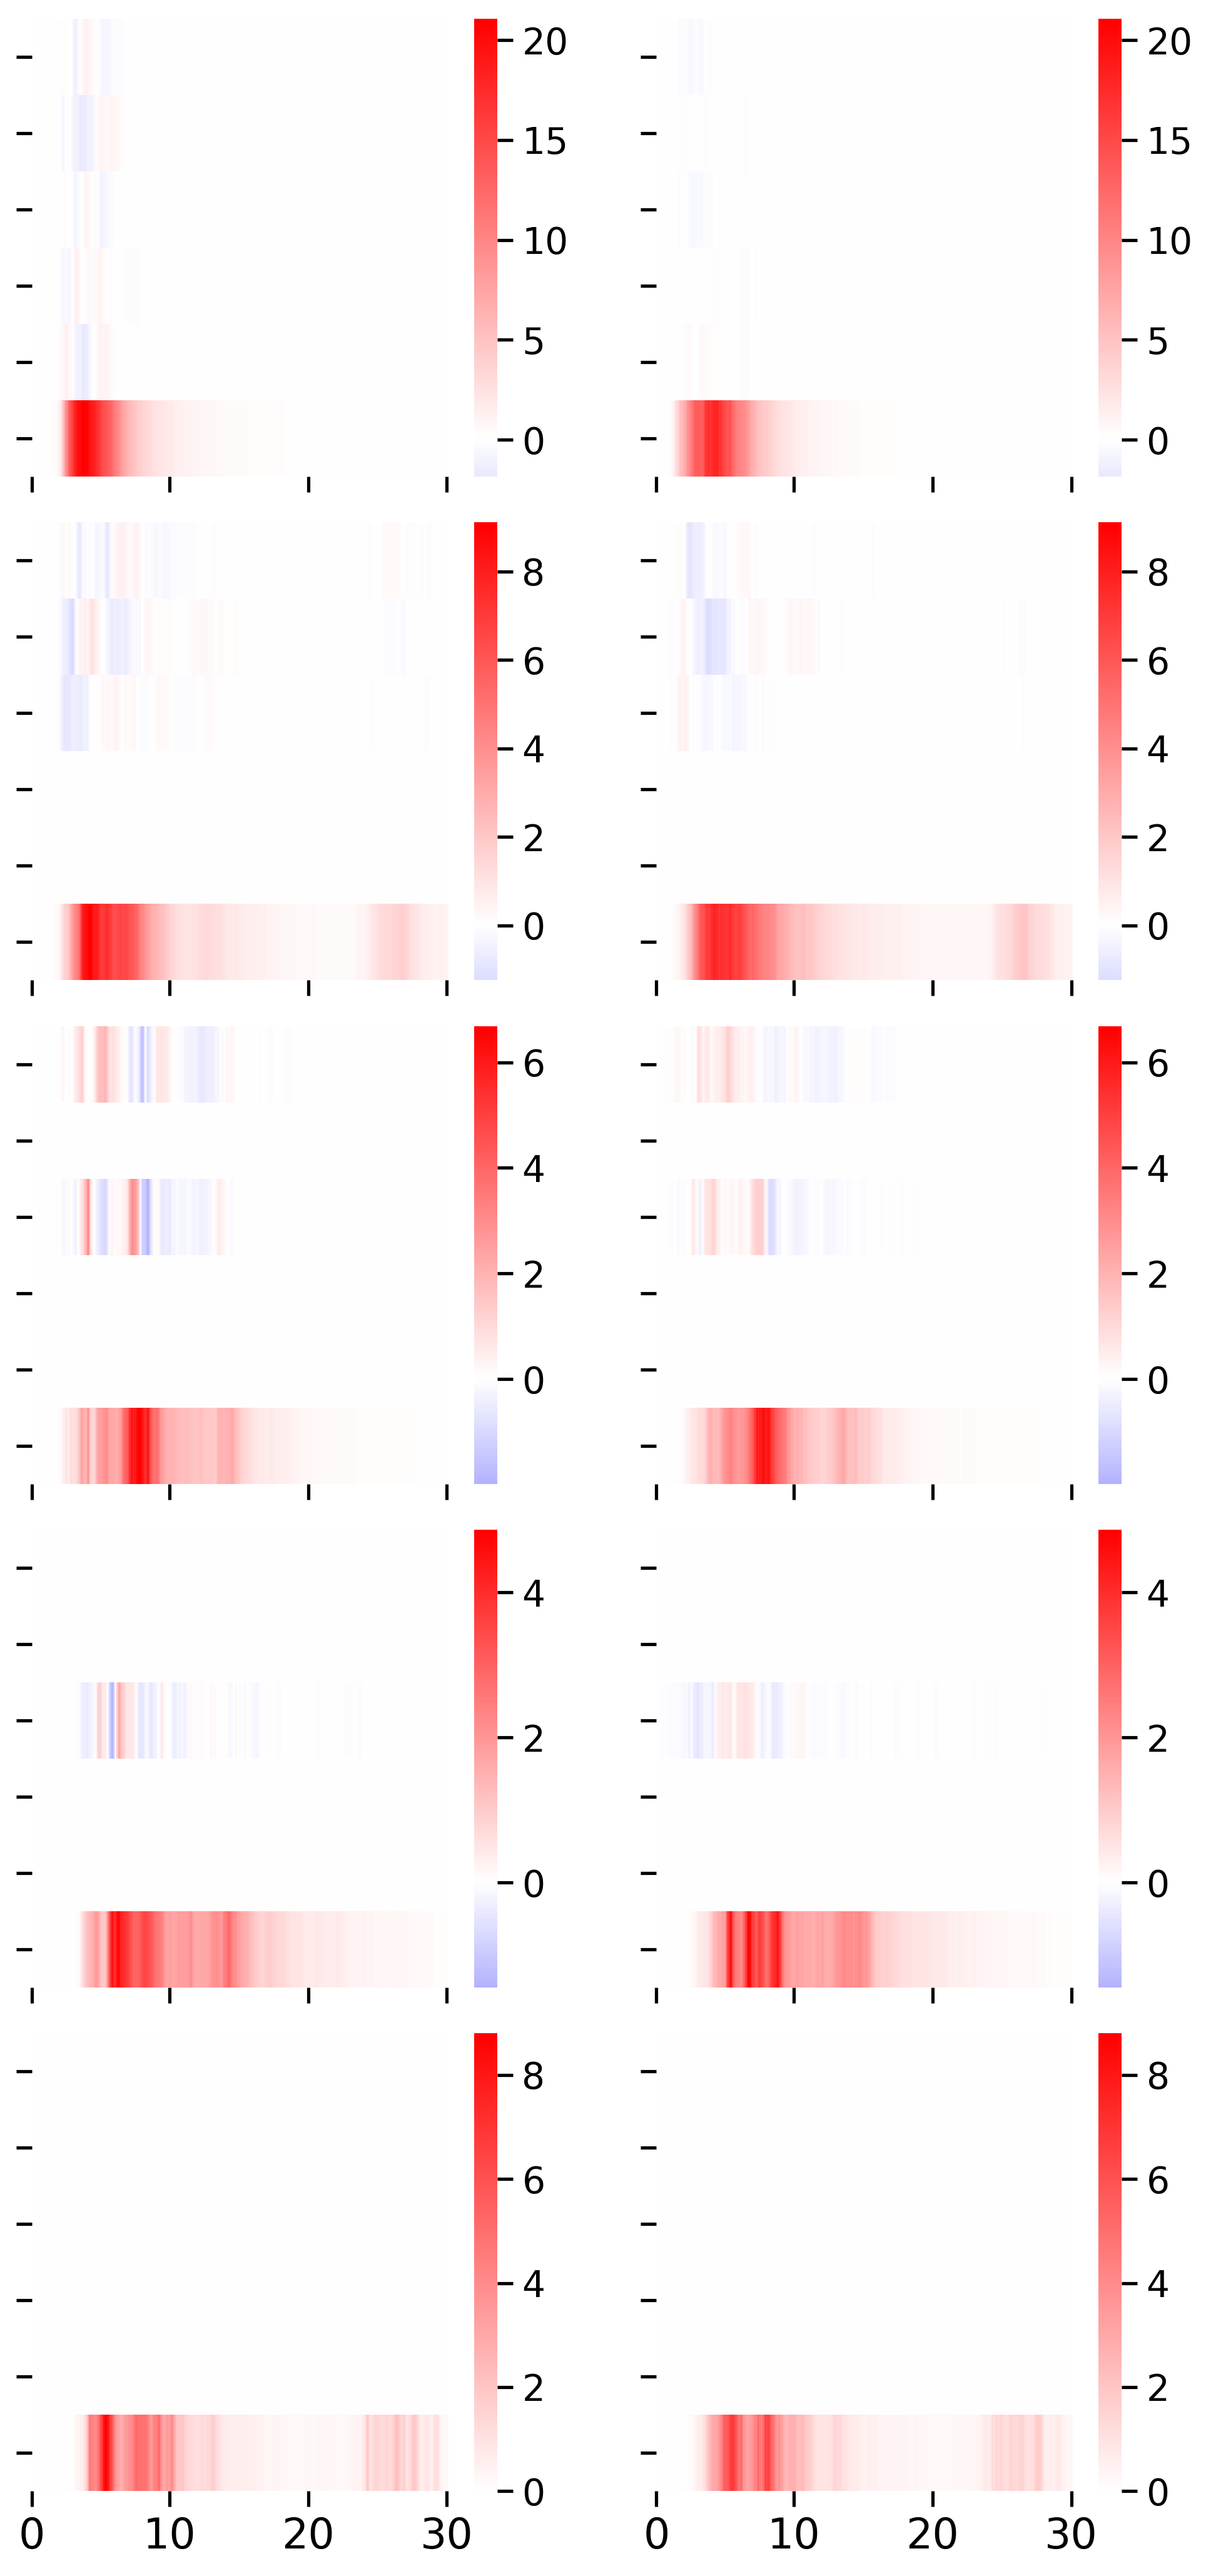

In [12]:
def plot_spherical_harmonics_comparison(df, idx, column_name, title_prefix="", n=4):
    """
    Plots heatmaps comparing target spherical harmonics with predicted spherical harmonics for multiple samples
    in a more compact layout (e.g., 4 rows × multiple columns instead of a single wide row).

    Parameters:
    - df: Pandas DataFrame containing 'sph_coefs' (targets), 'y_pred_sph' (predictions), 'mse'.
    - idx: List or array of indices to consider (e.g., idx_train, idx_test).
    - title_prefix: Prefix to be added to the plot title (e.g., Material ID).
    - n: Number of samples to plot.
    """
    # Filter DataFrame based on provided indices
    from e3nn.io import CartesianTensor
    from matplotlib.ticker import FuncFormatter

    with sns.plotting_context("notebook", font_scale=2):
        ct = CartesianTensor("ij=ji")
        ds = df.iloc[idx].reset_index(drop=True)

        # Extract energy grid (assume shared for all)
        omega = df["energies_interp"].iloc[0]

        # Define subplot grid layout
        # n_rows = 4  # Fixed number of rows
        # n_cols = math.ceil(n / n_rows) * 2  # Ensures space for real & predicted pairs
        n_rows = n
        n_cols = 2
        # Setup figure with multiple rows & columns for compact layout
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3 * n_rows), sharex=True, sharey=True, dpi=300)
        axes = axes.ravel()  # Flatten axes array for easy iteration

        # Spherical harmonic component labels
        # component_ticks = [r"$Y^2_2$", r"$Y^2_{1}$", r"$Y^2_0$", r"$Y^2_{-1}$", r"$Y^2_{-2}$", r"$Y^0_0$"]
        component_ticks = [
            r"",
            r"",
            r"",
            r"",
            r"",
            r""
        ]

        for i, sample_idx in enumerate(idx[:n]):  # Use provided indices directly
            material_id = ds.iloc[i]['mp_id']
            crystal_system = ds.iloc[i]['crystal_system']
            real_permittivity = ds[column_name].iloc[i]  # (num_energies, 3, 3)
            pred_permittivity = ds["y_pred_cart"].iloc[i]  # (num_energies, 3, 3)
            perm = torch.tensor([1, 2, 0])  # Permutation: x->2, y->0, z->1

            # Convert to torch tensors if not already
            real_permittivity = torch.tensor(real_permittivity) if not torch.is_tensor(real_permittivity) else real_permittivity
            pred_permittivity = torch.tensor(pred_permittivity) if not torch.is_tensor(pred_permittivity) else pred_permittivity

            # Permute the 3x3 dimensions (axes 1 and 2)
            real_permittivity_permuted = real_permittivity[:, perm, :][:, :, perm]  # Shape: [201, 3, 3]
            pred_permittivity_permuted = pred_permittivity[:, perm, :][:, :, perm]  # Shape: [201, 3, 3]

            real_sph = ct.from_cartesian(real_permittivity_permuted)
            pred_sph = ct.from_cartesian(pred_permittivity_permuted)

            # Extract target and prediction, then transpose & reverse for correct visualization
            X_irrep_target = real_sph.numpy().T[::-1, :]
            X_irrep_pred = pred_sph.numpy().T[::-1, :]
            vmin = X_irrep_target.min()
            vmax = X_irrep_target.max()
            # Left: Target heatmap
            ax_target = axes[2 * i]
            sns.heatmap(X_irrep_target, cmap='bwr', center=0, ax=ax_target,
                        yticklabels=component_ticks, xticklabels=50,
                        vmin=vmin, vmax=vmax)

            ax_target.tick_params(axis='x', rotation=0, labelsize=16)  
            ax_target.tick_params(axis='y', rotation=0, labelsize=16)  

            # Right: Predicted heatmap
            ax_pred = axes[2 * i + 1]
            sns.heatmap(X_irrep_pred, cmap='bwr', center=0, ax=ax_pred,
                        yticklabels=component_ticks, xticklabels=50,
                        vmin=vmin, vmax=vmax)

            ax_pred.tick_params(axis='x', rotation=0, labelsize=16)  
            ax_pred.tick_params(axis='y', rotation=0, labelsize=16)  

        # Set x-axis ticks at reasonable intervals
        num_omega = len(omega)
        tick_indices = np.linspace(0, num_omega - 1, 4, dtype=int)  
        tick_labels = [int(round(omega[idx])) for idx in tick_indices]  

        for ax in axes[:2 * n]:
            if ax.collections:  
                cbar = ax.collections[0].colorbar
                cbar.ax.tick_params(labelsize=14)  # <-- make colorbar tick labels smaller
                cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}"))
        for ax in axes[:2 * n]:  
            ax.set_xticks(tick_indices)
            ax.set_xticklabels(tick_labels)
            
        plt.tight_layout(rect=[0, 0.05, 1, 1])  
        plt.subplots_adjust(wspace=0.2, hspace=0.1)  
        os.makedirs("../pngs", exist_ok=True)
        save_path = f"../pngs/{title_prefix}_spectra.png"
        fig.savefig(save_path, dpi=300)
        plt.show()

plot_spherical_harmonics_comparison(df, representative_idx, column, title_prefix="testing_set", n=5)


# Symmetry perseverance validation

In [13]:
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.io.ase import AseAtomsAdaptor  # Import the converter
import numpy as np

sym_prec = 1e-2
tolerance = 1e-6

all_masks = []
splits = {
    "Train": idx_train,
    "Validation": idx_valid,
    "Test": idx_test
}
colors = {"Train": "#1f77b4", "Validation": "#ff7f0e", "Test": "#2ca02c"}

df['split'] = np.nan
for split_name, idx in splits.items():
    df.loc[idx, 'split'] = split_name
test_df = df[df['split'] == 'Test']

for index, row in test_df.iterrows():
    # Convert ASE Atoms object to pymatgen Structure
    ase_atoms = row.symmetrized_structure  # This is your ASE Atoms object
    pymatgen_structure = AseAtomsAdaptor.get_structure(ase_atoms)
    
    # Now use the pymatgen Structure with SpacegroupAnalyzer
    sga_primitive = SpacegroupAnalyzer(pymatgen_structure, symprec=sym_prec)
    refined_structure = sga_primitive.get_refined_structure()
    refined_sga = SpacegroupAnalyzer(refined_structure, symprec=sym_prec)
    symmetry_operations = refined_sga.get_symmetry_operations(cartesian=True)

    x = np.ones([3, 3])
    mask = np.zeros([3, 3])
    for op in symmetry_operations:
        R = op.rotation_matrix 
        mask += R @ x @ R.T
    mask /= len(symmetry_operations)
    all_masks.append(mask) 

    spectra = row["y_pred_cart"]  # Shape: (301, 3,3)
    # spectra = row["imag_Permittivity_Matrices_interp"]

    violations = []
    for i in range(spectra.shape[0]):  # Loop over omega
        S_matrix = spectra[i] # Reshape (9,) -> (3,3)
        # Check symmetry constraint
        residuals = S_matrix * (1 - mask)  # Keep only the disallowed values
        max_deviation = np.max(np.abs(residuals))  # Max deviation outside mask

        if max_deviation > tolerance:
            violations.append((i, max_deviation))
    sys = row["crystal_system"]
    formula = row["formula"]
    split = row["split"]
    # Print results
    if not violations:
        # print(f"Material {row['mp_id']} pass check")
        continue
    else:
        print(f"Material @ {index} {row['mp_id']} violates symmetry in {len(violations)} cases. {sys}. {formula} {split}")
        # for index, dev in violations[:5]:  # Print first few violations
            # print(f"  - Row {index}: max deviation = {dev:.5e}")

# test_df["symmetry_mask"] = all_masks


/tmp/ipykernel_816588/1032903127.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Train' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[idx, 'split'] = split_name


In [14]:
from concurrent.futures import ProcessPoolExecutor
from multiprocessing import cpu_count  
from scipy.stats import linregress
from scipy.signal import argrelextrema
import matplotlib.ticker as ticker

def absorption_coef(omega, epsilon_1, epsilon_2):
    return np.sqrt(2) * 5.067726 * omega * np.sqrt(np.sqrt(epsilon_1**2 + epsilon_2**2) - epsilon_1)
    # return np.sqrt(2) * omega * np.sqrt(np.sqrt(epsilon_1**2 + epsilon_2**2) - epsilon_1)

def find_peak_LHS_from_Eg(energy, alpha, Eg, m=0.5, frac_level=0.3):
    y = (alpha * energy) ** (1/m)

    # Find local maxima after Eg
    idx_peaks = argrelextrema(y, np.greater)[0]
    idx_peaks = idx_peaks[energy[idx_peaks] > Eg]

    if len(idx_peaks) == 0:
        return (Eg, Eg + 0.5)  # fallback

    # First absorption peak
    idx_peak = idx_peaks[0]
    E_peak, y_peak = energy[idx_peak], y[idx_peak]

    # LHS cutoff: first point where y < frac_level * y_peak
    lhs_candidates = np.where((energy < E_peak) & (y < frac_level * y_peak))[0]
    if len(lhs_candidates) == 0:
        Emin = Eg
    else:
        Emin = energy[lhs_candidates[-1]]  # closest from left

    return (Emin, E_peak)
def tauc_fit(energy, alpha, m=0.5, Eg_dft=None, fit_range=None, plot=True, label="Direct allowed",
             figsize=(8,6), fontsize=14):
    y = (alpha * energy) ** (1/m)

    if fit_range is None:
        raise ValueError("fit_range must be provided when Eg is known")

    mask = (energy >= fit_range[0]) & (energy <= fit_range[1])
    E_fit, y_fit = energy[mask], y[mask]
    if len(E_fit) < 2:
        raise ValueError(f"No points in fit_range {fit_range}")

    # Linear regression
    slope, intercept, _, _, _ = linregress(E_fit, y_fit)
    Eg_opt = -intercept / slope

    if plot:
        fig, ax = plt.subplots(figsize=figsize)

        # Raw Tauc curve
        ax.plot(energy, y, lw=1.5, color='black')

        # Fitted line
        E_line = np.linspace(Eg_opt, max(E_fit), 200)
        y_line = slope * E_line + intercept
        ax.plot(E_line, y_line, "r--", lw=2, label="Fitted line")

        # Vertical bandgaps
        ax.axvline(Eg_opt, color="k", linestyle=":", lw=1.5,
                   label=f"Optical Eg ≈ {Eg_opt:.2f} eV")
        if Eg_dft is not None:
            ax.axvline(Eg_dft, color="blue", linestyle=":", lw=1.5,
                       label=f"DFT Eg ≈ {Eg_dft:.2f} eV")

        # Labels
        ax.set_xlabel("Photon energy (eV)", fontsize=fontsize)
        ax.set_ylabel(r"$(\alpha h\nu)^{2}$", fontsize=fontsize)
        ax.set_xlim(0, 1.3 * fit_range[1])
        ax.set_ylim(0, 1.3 * max(y_line))

        # Major + minor ticks
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))  # adds 0.25 ticks
        ax.tick_params(axis="both", which="major", labelsize=fontsize-2)
        ax.tick_params(axis="both", which="minor", length=4, labelsize=0)  # hide labels for minor ticks

        # Legend
        ax.legend(fontsize=fontsize-2,loc="upper left", frameon=True)
        plt.show()

    return Eg_opt
def kramers_kronig_tensor(omega_vals, imag_tensor):
    N = len(omega_vals)
    real_tensor = np.zeros_like(imag_tensor)

    for i in range(3):
        for j in range(i, 3):
            chi_im_vals = imag_tensor[:, i, j]
            chi_re_vals = np.zeros(N)

            for k, omega in enumerate(omega_vals):
                integrand = np.zeros(N)
                for l, omega_p in enumerate(omega_vals):
                    if l != k: # Skip the singularity when omega' = omega
                        integrand[l] = (omega_p * chi_im_vals[l]) / (omega_p**2 - omega**2)
                integral = np.trapz(integrand, omega_vals)
                chi_re_vals[k] = (2 / np.pi) * integral

            real_tensor[:, i, j] = chi_re_vals
            if i != j:
                real_tensor[:, j, i] = chi_re_vals
    for i in range(3):
        real_tensor[:, i, i] += 1.0
        
    return real_tensor

def compute_K_xx(omega, sigma_complex):
    omega_cut = omega[1:]
    # sigma = sigma_complex[1:]  # shape: (N-5, 3, 3)
    sigma_xx_re = sigma_complex[1:, 0, 0].real
    integrand = np.nan_to_num(sigma_xx_re / omega_cut, nan=0.0, posinf=0.0, neginf=0.0)
    return 2 * np.trapz(integrand, omega_cut)

def compute_C_xy(omega, sigma_complex):
    omega_cut = omega[1:]
    sigma_xy_im = sigma_complex[1:, 0, 1].imag
    integrand = np.nan_to_num(sigma_xy_im / omega_cut, nan=0.0, posinf=0.0, neginf=0.0)
    return -4 * np.trapz(integrand, omega_cut)

def process_row(row_dict):
    row = row_dict.copy()
    imag_permittivity = np.array(row["rel_permittivity_imag_interp"])
    pred_imag_permittivity = np.array(row["y_pred_cart"])
    omega = np.array(row["energies_interp"])  # in eV
    Eg_dft = row.get("bandgap_openmx", None)  # provided bandgap if available

    omega = np.where(omega == 0, np.finfo(float).eps, omega)

    # --- Kramers–Kronig reconstruction ---
    real_permittivity = kramers_kronig_tensor(omega, imag_permittivity)
    pred_real_permittivity = kramers_kronig_tensor(omega, pred_imag_permittivity)

    permittivity_complex = real_permittivity + 1j * imag_permittivity
    conductivity_complex = -1j * permittivity_complex / omega[:, np.newaxis, np.newaxis]

    pred_permittivity_complex = pred_real_permittivity + 1j * pred_imag_permittivity
    pred_conductivity_complex = -1j * pred_permittivity_complex / omega[:, np.newaxis, np.newaxis]

    row["permittivity_complex"] = permittivity_complex
    row["pred_permittivity_complex"] = pred_permittivity_complex

    row["conductivity_complex"] = conductivity_complex
    row["pred_conductivity_complex"] = pred_conductivity_complex

    # --- Quantum weight and Chern number ---
    row["K_xx"] = compute_K_xx(omega, conductivity_complex)
    row["pred_K_xx"] = compute_K_xx(omega, pred_conductivity_complex)

    row["C_xy"] = compute_C_xy(omega, conductivity_complex)
    row["pred_C_xy"] = compute_C_xy(omega, pred_conductivity_complex)

    # --- Absorption coefficient and optical Eg ---
    # Average diagonals for eps1 and eps2
    eps1 = np.mean(real_permittivity[:, [0,1,2], [0,1,2]], axis=1)
    eps2 = np.mean(imag_permittivity[:, [0,1,2], [0,1,2]], axis=1)
    pred_eps1 = np.mean(pred_real_permittivity[:, [0,1,2], [0,1,2]], axis=1)
    pred_eps2 = np.mean(pred_imag_permittivity[:, [0,1,2], [0,1,2]], axis=1)

    alpha = absorption_coef(omega, eps1, eps2)
    pred_alpha = absorption_coef(omega, pred_eps1, pred_eps2)

    row["alpha"] = alpha
    row["pred_alpha"] = pred_alpha

    try:
        fit_range = find_peak_LHS_from_Eg(omega, alpha, Eg=Eg_dft, m=0.5, frac_level=0.3)
        row["optical_bandgap"] = tauc_fit(omega, alpha, m=0.5, Eg_dft=Eg_dft,
                                          fit_range=fit_range, plot=False)
        row["pred_optical_bandgap"] = tauc_fit(omega, pred_alpha, m=0.5, Eg_dft=Eg_dft,
                                               fit_range=fit_range, plot=False)
    except Exception as e:
        row["pred_optical_bandgap"] = np.nan

    return row

# --- Parallelize over rows ---
num_workers = min(cpu_count(), len(df))  # Limit workers to available CPU cores

def parallel_process_df(df, n_workers=None):
    rows = df.to_dict(orient="records")
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        results = list(executor.map(process_row, rows))
    return pd.DataFrame(results)

# Usage:
df = parallel_process_df(df)

Dropped 4/147 points (2.72%).
R² (filtered) = 0.930


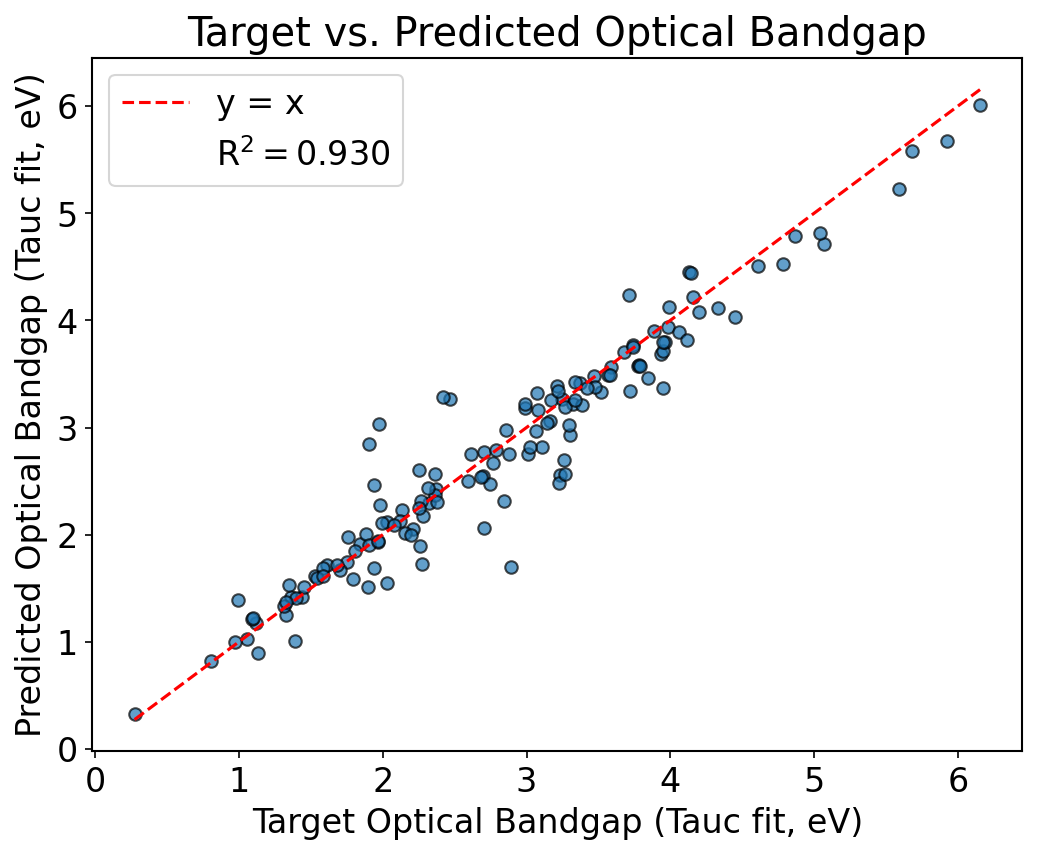

In [15]:
from sklearn.metrics import r2_score
df_test = df.loc[idx_test].copy().reset_index()
# Keep rows without NaN
mask = df_test["optical_bandgap"].notna() & df_test["pred_optical_bandgap"].notna()
x = df_test.loc[mask, "optical_bandgap"].values
y = df_test.loc[mask, "pred_optical_bandgap"].values

residual = np.abs(y - x)
keep = residual < 2.5
x_filt, y_filt = x[keep], y[keep]
n_total = len(x)
n_kept = keep.sum()
n_dropped = n_total - n_kept
pct_dropped = 100 * n_dropped / n_total

print(f"Dropped {n_dropped}/{n_total} points ({pct_dropped:.2f}%).")
# Compute R²
r2 = r2_score(x_filt, y_filt)
print(f"R² (filtered) = {r2:.3f}")

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(x_filt, y_filt, alpha=0.7, edgecolor="k")

lims = [min(x_filt.min(), y_filt.min()), max(x_filt.max(), y_filt.max())]
plt.plot(lims, lims, "r--", label="y = x")
r2_text = mpl.lines.Line2D([], [], color='none', label=fr"$R^2 = {r2:.3f}$")
plt.xlabel("Target Optical Bandgap (Tauc fit, eV)")
plt.ylabel("Predicted Optical Bandgap (Tauc fit, eV)")
plt.title(f"Target vs. Predicted Optical Bandgap")
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(mpl.lines.Line2D([], [], color='none'))
labels.append(fr"$R^2 = {r2:.3f}$")
plt.legend(handles, labels, loc="best")
# plt.grid(True, ls="--", alpha=0.6)
plt.show()

In [16]:
# row = df_test.sample(1).iloc[0]
# omega = np.array(row["energies_interp"])
# Eg_input = row.bandgap_openmx  

# plt.figure(figsize=(10,8))

# # --- Theoretical absorption ---
# fit_range_true = find_peak_LHS_from_Eg(omega, row.alpha, Eg=Eg_input, m=0.5, frac_level=0.3)
# Eg_true = tauc_fit(omega, row.alpha, m=0.5, Eg_dft=Eg_input,
#                    fit_range=fit_range_true, plot=True, label="Theoretical")

# # --- Predicted absorption ---
# # fit_range_pred = find_peak_LHS_from_Eg(omega, row.pred_alpha, Eg=Eg_input, m=0.5, frac_level=0.3)
# Eg_pred = tauc_fit(omega, row.pred_alpha, m=0.5, Eg_dft=Eg_input,
#                    fit_range=fit_range_true, plot=True, label="Predicted")
# plt.show()

# print(f"Provided Eg (DFT)      = {Eg_input:.2f} eV")
# print(f"Optical Eg (Theoretical) = {Eg_true:.2f} eV")
# print(f"Optical Eg (Predicted)   = {Eg_pred:.2f} eV")

In [17]:
splits = {
    "Train": idx_train,
    "Validation": idx_valid,
    "Test": idx_test
}
colors = {"Train": "#1f77b4", "Validation": "#ff7f0e", "Test": "#2ca02c"}

df['split'] = np.nan
for split_name, idx in splits.items():
    df.loc[idx, 'split'] = split_name
# df_clean = df[
#     (df["split"] == "Test") & 
#     (df["K_xx"] > 0) & (df["K_xx"] < 65) & 
#     (df["pred_K_xx"] > 0) & (df["pred_K_xx"] < 65)
# ]

# # Compute R²
# r2 = r2_score(df_clean["K_xx"], df_clean["pred_K_xx"])
# print(f"R² score: {r2:.4f}")

# # Create plot
# lims = [
#     0,
#     max(df_clean["K_xx"].max(), df_clean["pred_K_xx"].max())+5
# ]

# plt.figure(figsize=(7,6))
# plt.scatter(df_clean["K_xx"], df_clean["pred_K_xx"], alpha=0.7, edgecolor='k', color=colors["Test"], label=f"$R^2$ = {r2:.4f}")

# # x = y line
# plt.plot(lims, lims, 'k--')

# # Make axes have equal scaling
# plt.gca().set_aspect('equal', adjustable='box')

# # Labels and layout
# plt.xlabel("True $K_{xx}$")
# plt.ylabel("Predicted $K_{xx}$")
# plt.legend()
# plt.tight_layout()
# plt.show()

/tmp/ipykernel_816588/122934034.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Train' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[idx, 'split'] = split_name


In [18]:
# # Sort by K_xx descending and take top N
# top_kxx_df = df.sort_values(by="pred_K_xx", ascending=False).head(10)  # change 10 to however many you want

# # Display top entries
# print(top_kxx_df[["formula","mp_id", "bandgap_mp", "pred_K_xx", "K_xx", "crystal_system"]])  # adapt columns if needed# df[df.mp_id == "mp-34202"]

In [19]:
# plt.figure(figsize=(6, 5))
# plt.scatter(df["bandgap_mp"], df["pred_K_xx"], alpha=0.7, edgecolor='k')
# plt.xlabel("Band Gap (eV)")
# plt.ylabel(r"$K_{xx}$")
# plt.title("Band Gap vs Quantum Weight $K_{xx}$")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [20]:
# # Set up figure
# plt.figure(figsize=(7,7))

# # Scatter
# # Compute R²
# r2 = r2_score(df["C_xy"], df["pred_C_xy"])
# print(f"R² score: {r2:.4f}")
# plt.scatter(df["C_xy"], df["pred_C_xy"], alpha=0.7, edgecolor='k', color=colors["Test"], label=f"$R^2$ = {r2:.4f}")

# # Determine axis range based on full data
# x_min = min(df["C_xy"].min(), df["pred_C_xy"].min())
# x_max = max(df["C_xy"].max(), df["pred_C_xy"].max())

# # Round limits for neat ticks (optional)
# x_min = np.floor(x_min)
# x_max = np.ceil(x_max)

# # Use equal limits for both axes
# lims = [x_min, x_max]
# plt.xlim(lims)
# plt.ylim(lims)

# # Add x = y line
# plt.plot(lims, lims, 'k--')

# # Enforce square aspect
# ax = plt.gca()
# ax.set_aspect('equal', adjustable='box')

# # Set 54 evenly spaced ticks

# # Labels and legend
# plt.xlabel("True $C_{xy}$")
# plt.ylabel("Predicted $C_{xy}$")
# plt.legend()
# # plt.grid(True, linestyle='--', linewidth=0.5)
# plt.tight_layout()
# plt.show()



Train


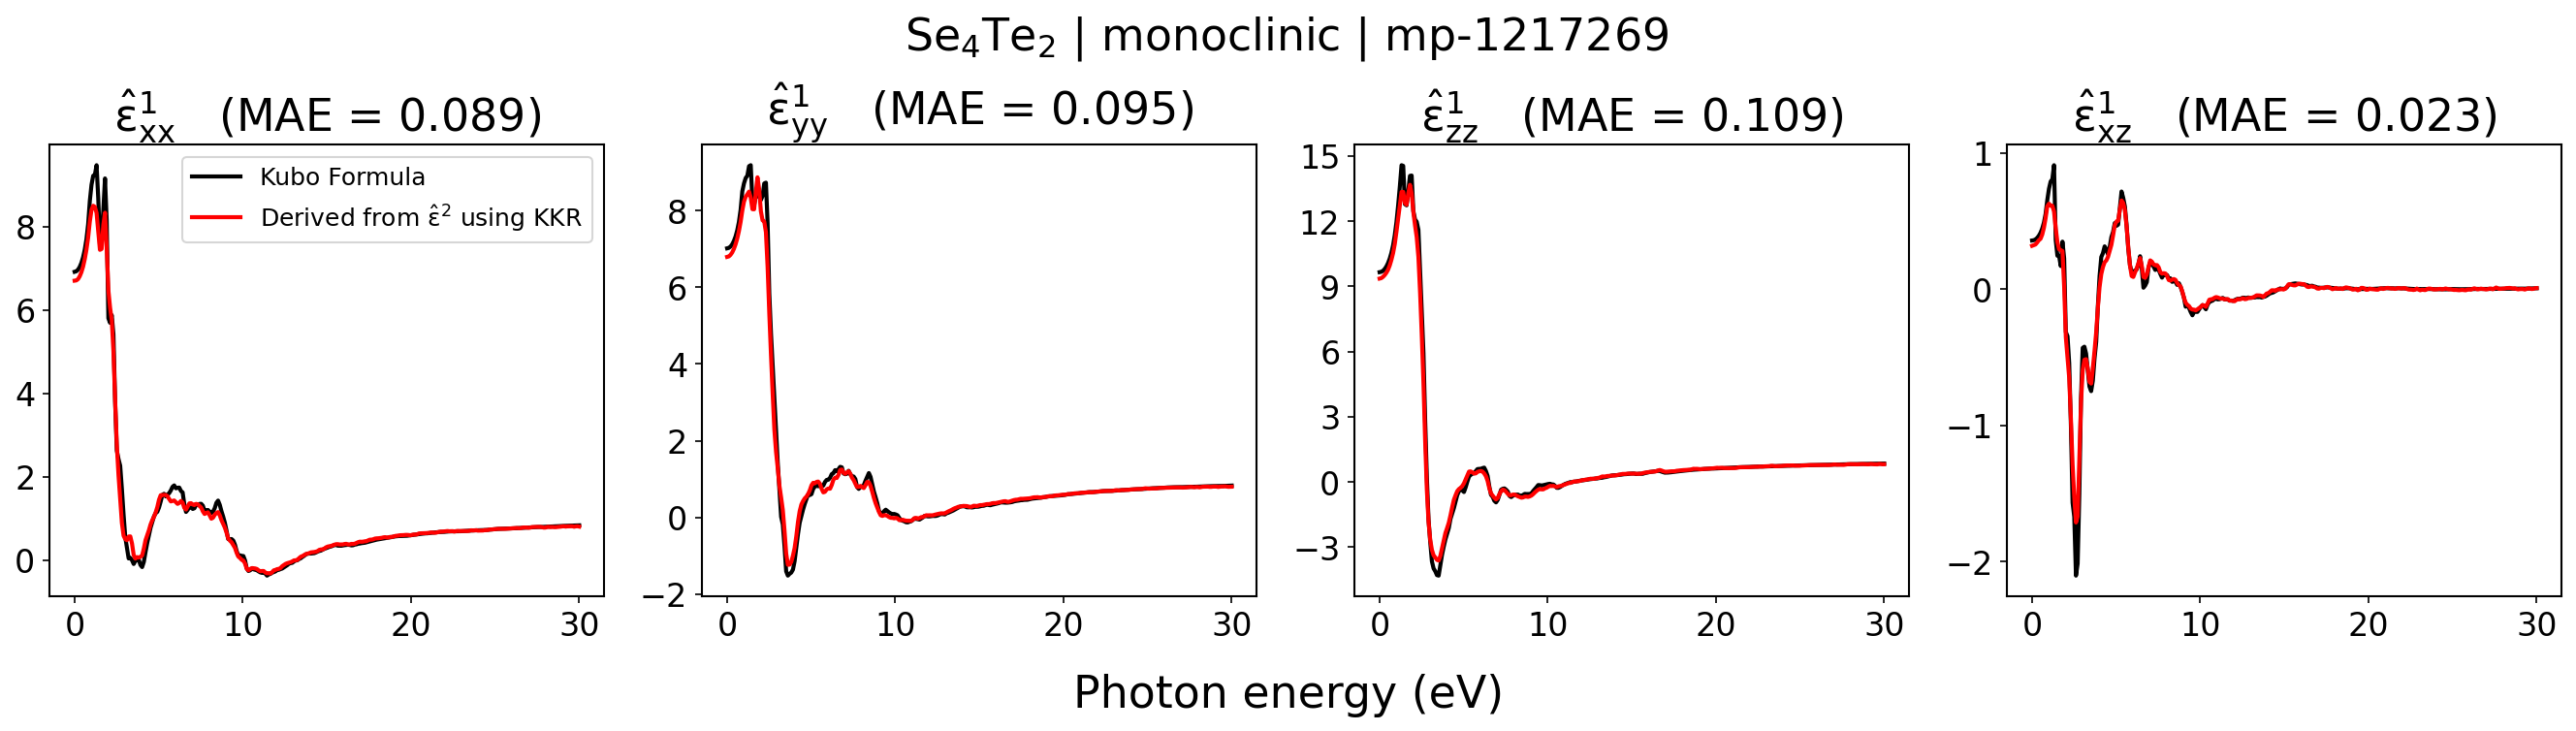

In [21]:
# Choose a row
fontsize = 14
row = df[df["formula"] == "Se4Te2"].iloc[0]
print(row.split)
# Extract data
omega = row.omega
omega_interp = row.energies_interp

imag_permittivity = row["y_pred_cart"]
real_permittivity = interpolate_matrix(row["rel_permittivity_real"], omega)
real_permittivity_kkr = kramers_kronig_tensor(omega_interp, imag_permittivity)

# Settings
xyz_list = ['x', 'y', 'z']
fontsize = 20
figsize = (18, 6)
threshold = 1e-4
zoomed_out_ylim = 5e-1

# Define which components to show: e.g., xx, yy, zz, xz
components_to_plot = [(0, 0), (1, 1), (2, 2), (0, 2)]

# Set up subplots: 4 vertically stacked
fig, axes = plt.subplots(1, len(components_to_plot), figsize=figsize, sharex=True,  dpi = 150)
if len(components_to_plot) == 1:
    axes = [axes]  # ensure iterable

lines = []
labels = []
maes = []

for ax, (i, j) in zip(axes, components_to_plot):
    y1 = real_permittivity[:, i, j]
    y2 = real_permittivity_kkr[:, i, j]

    l1, = ax.plot(omega_interp, y1, color='black', label='Kubo Formula', linewidth = 2)
    l2, = ax.plot(omega_interp, y2, color='red', label=r'Derived from $\hat\epsilon^2$ using KKR',linewidth = 2)

    y_vals = np.concatenate([y1, y2])
    max_val = np.max(np.abs(y_vals))

    if max_val < threshold:
        ax.set_ylim(-zoomed_out_ylim, zoomed_out_ylim)

    mae = np.mean(np.abs(y1 - y2))
    maes.append(mae)

    comp_label = rf"$\hat{{\epsilon}}^1_{{{xyz_list[i]}{xyz_list[j]}}}$"
    ax.set_title(f"{comp_label}   (MAE = {mae:.3f})", fontsize=fontsize + 2)

    if len(lines) == 0:
        # Save handles & labels for completeness (optional)
        lines.extend([l1, l2])
        labels.extend([l.get_label() for l in (l1, l2)])
        
        # Put the legend in a less busy spot for the first subplot
        ax.legend(loc='upper right', fontsize= 12, frameon=True)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    x_ticks = np.linspace(omega[0], omega[-1], 4)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{v:.0f}" for v in x_ticks])  # integer labels
    for ax in axes:
        ax.set_xticks(x_ticks)

# Global info
formula = format_chemical_formula(row["formula"])
crystal_sys = row["crystal_system"]
global_mae = np.mean(maes)
mp_id = row["mp_id"]
fig.suptitle(rf"${formula}$ | {crystal_sys} | {mp_id} ", fontsize=fontsize + 2, x = 0.5,  y=0.9)
fig.supxlabel("Photon energy (eV)", fontsize=fontsize + 2, y=0.095, x = 0.5)
# fig.supylabel(r"$\epsilon_1$", fontsize=fontsize + 2, x = 0.05)


plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()


formula                                                          Au4I12Rb4
symmetrized_structure    (Atom('Rb', [0.4603644013326422, 0.0, 5.977417...
mp_id                                                            mp-568666
bandgap_openmx                                                    0.778978
bandgap_mp                                                          0.7061
                                               ...                        
target_mean              [[0.7766890854986822, 0.0, -0.0919889776659571...
pred_mean                [[0.7121263310435554, 1.8200760280484883e-19, ...
target_avg                                                        0.388879
pred_avg                                                          0.358487
abs_diff_avg                                                      0.030392
Name: 986, Length: 96, dtype: object


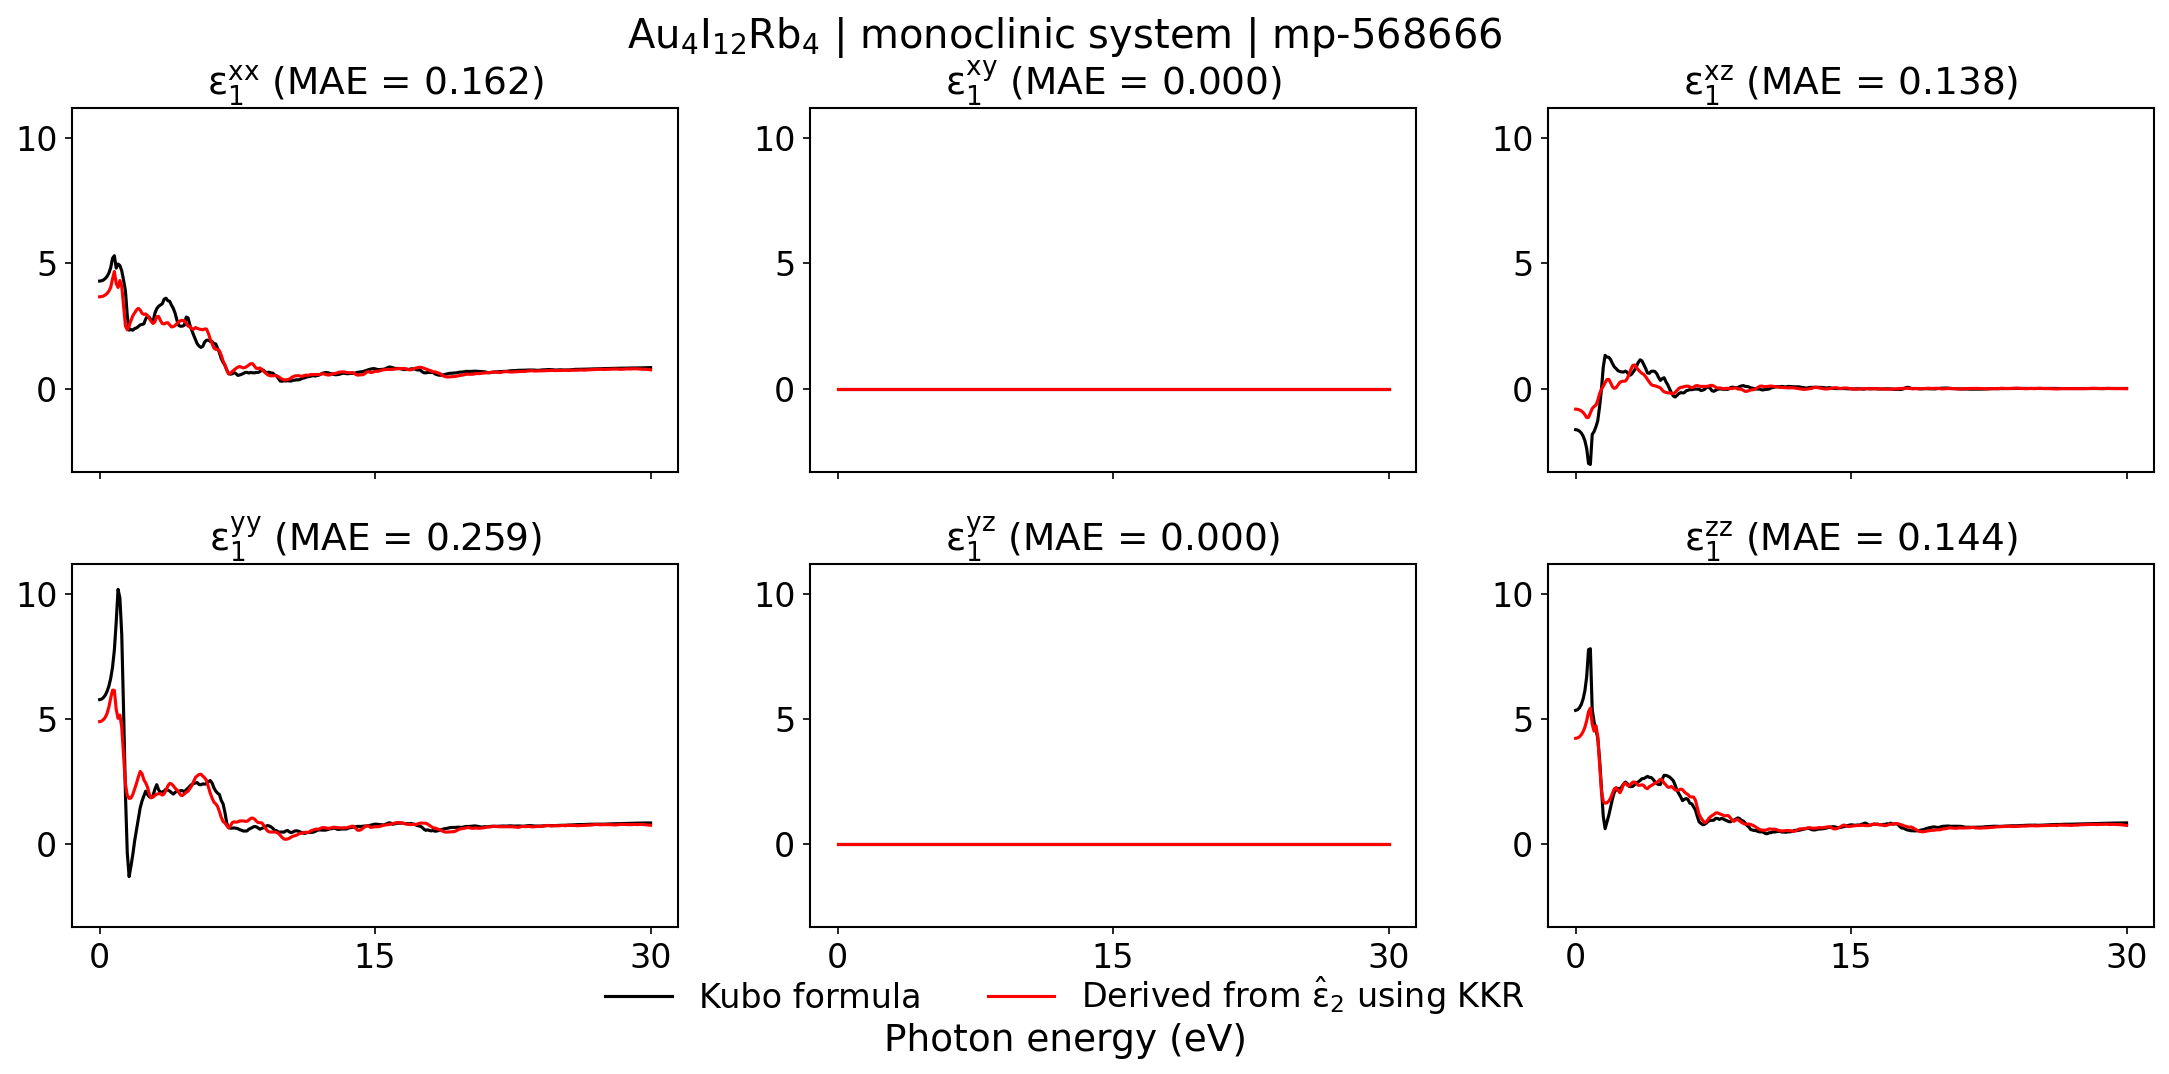

In [43]:
# Choose a row
# row = df[df["formula"] == "Mo3S2Se4"].iloc[0]
# row = df[df["formula"] == "H2Na2O2"].iloc[0]
row = df[(df["split"] == "Test") & (df["crystal_system"] == "monoclinic")].sample(1).iloc[0]
# row = df[df["formula"] == "C"].iloc[0]
print(row)
# Extract data
omega = row.omega
omega_interp = row.energies_interp
imag_permittivity = row["y_pred_cart"]
real_permittivity = interpolate_matrix(row["rel_permittivity_real"], omega)
real_permittivity_kkr = kramers_kronig_tensor(omega_interp, imag_permittivity)
xyz_list = ['x', 'y', 'z']
fontsize = 16
figsize = (15, 8)

# Set up subplots
fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True)
axes = axes.flatten()

component_idx = 0
lines = []
labels = []
maes = []
all_vals = np.concatenate([
    real_permittivity[:, np.triu_indices(3)[0], np.triu_indices(3)[1]],
    real_permittivity_kkr[:, np.triu_indices(3)[0], np.triu_indices(3)[1]]
], axis=1)
global_abs_max = np.max(np.abs(all_vals))
global_abs_min = np.min((all_vals))

for i in range(3):
    for j in range(i, 3):
        ax = axes[component_idx]
        comp_label = rf"$\epsilon_1^{{{xyz_list[i]}{xyz_list[j]}}}$"

        y1 = real_permittivity[:, i, j]
        y2 = real_permittivity_kkr[:, i, j]

        l1, = ax.plot(omega_interp, y1, color='black', label='Kubo formula', linewidth = 1.5)
        l2, = ax.plot(omega_interp, y2, color='red', label=r'Derived from $\hat\epsilon_2$ using KKR', linewidth = 1.5)

        mae = np.mean(np.abs(y1 - y2))
        maes.append(mae)

        ax.set_ylim(global_abs_min * 1.1, global_abs_max * 1.1)
        ax.set_title(f"{comp_label} (MAE = {mae:.3f})", fontsize=fontsize + 2)
        x_ticks = [omega[0], (omega[0] + omega[-1]) / 2, omega[-1]]
        for ax in axes:
            ax.set_xticks(x_ticks)
            
        if component_idx == 0:
            lines.extend([l1, l2])
            labels.extend([l.get_label() for l in (l1, l2)])

        component_idx += 1
# Hide unused subplots if any
for k in range(component_idx, len(axes)):
    fig.delaxes(axes[k])


formula = format_chemical_formula(row["formula"])
crystal_sys = row["crystal_system"]
mp_id = row["mp_id"]
# Super (global) axis labels
fig.suptitle(rf"${formula}$ | {crystal_sys} system | {mp_id}",y = 0.94)
fig.supxlabel("Photon energy (eV)", fontsize=fontsize + 2, y=0.07)
# Shared legend below all plots
fig.legend(lines, labels, loc='lower center', ncol=2, fontsize=fontsize,  bbox_to_anchor=(0.5, 0.08),frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout
plt.show()

In [23]:
# # Extract data
# row = df[df.formula == "K2N2O4"].iloc[0]
# omega = row.omega
# imag_permittivity = row["imag_symmetrized_permittivity"]
# real_permittivity = row["real_symmetrized_permittivity"]
# real_permittivity_kkr = kramers_kronig_tensor(omega, imag_permittivity)
# # Settings
# xyz_list = ['x', 'y', 'z']
# fontsize = 24
# figsize = (15, 8)

# # Set up subplots
# fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True)
# axes = axes.flatten()

# component_idx = 0
# lines = []
# labels = []
# maes = []
# all_vals = np.concatenate([
#     real_permittivity[:, np.triu_indices(3)[0], np.triu_indices(3)[1]],
#     real_permittivity_kkr[:, np.triu_indices(3)[0], np.triu_indices(3)[1]]
# ], axis=1)
# global_abs_max = np.max(np.abs(all_vals))
# global_abs_min = np.min((all_vals))
# for i in range(3):
#     for j in range(i, 3):
#         ax = axes[component_idx]
#         comp_label = rf"$\chi_{{{xyz_list[i]}{xyz_list[j]}}}$"

#         l1, = ax.plot(omega, real_permittivity[:, i, j], color='black', label='Kubo formula', linewidth = 2)
#         l2, = ax.plot(omega, real_permittivity_kkr[:, i, j], linestyle='--', color='red', label='KKR', linewidth = 2)
#         # Optional: zero line for context
#         # ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
#         mae = np.mean(np.abs(real_permittivity[:, i, j] - real_permittivity_kkr[:, i, j]))
#         maes.append(mae)
#         # Automatically zoom out if the component is near-zero
#         ax.set_ylim(global_abs_min * 1.1, global_abs_max * 1.1)

#         ax.set_title(f"{comp_label}   (MAE = {mae:.3f})", fontsize=fontsize + 2)

#         if component_idx == 0:
#             lines.extend([l1, l2])
#             labels.extend([l.get_label() for l in (l1, l2)])

#         component_idx += 1
# # Hide unused subplots if any
# for k in range(component_idx, len(axes)):
#     fig.delaxes(axes[k])


# formula = format_chemical_formula(row["formula"])
# crystal_sys = row["crystal_system"]
# # Super (global) axis labels
# fig.suptitle(rf"${formula}$ {crystal_sys} system", y=0.93)
# fig.supxlabel("Photon energy (eV)", fontsize=fontsize + 2, y=0.07)
# fig.supylabel("Permittivity real part (F/m)", fontsize=fontsize + 2)

# # Shared legend below all plots
# fig.legend(lines, labels, loc='lower center', ncol=2, fontsize=fontsize,  bbox_to_anchor=(0.5, 0.1),frameon=False)
# plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout
# plt.show()


Test


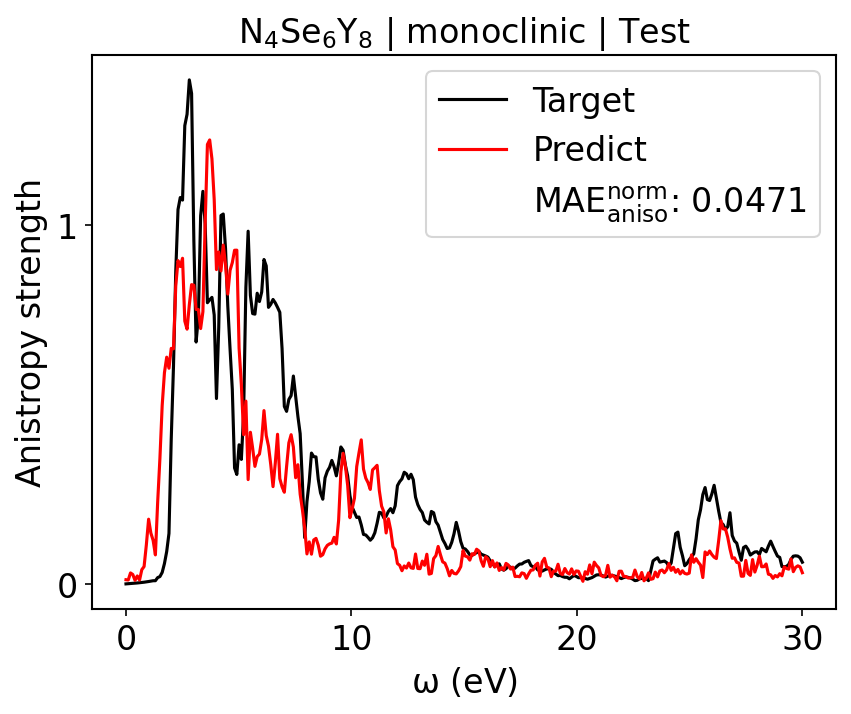

0.047098569454830076


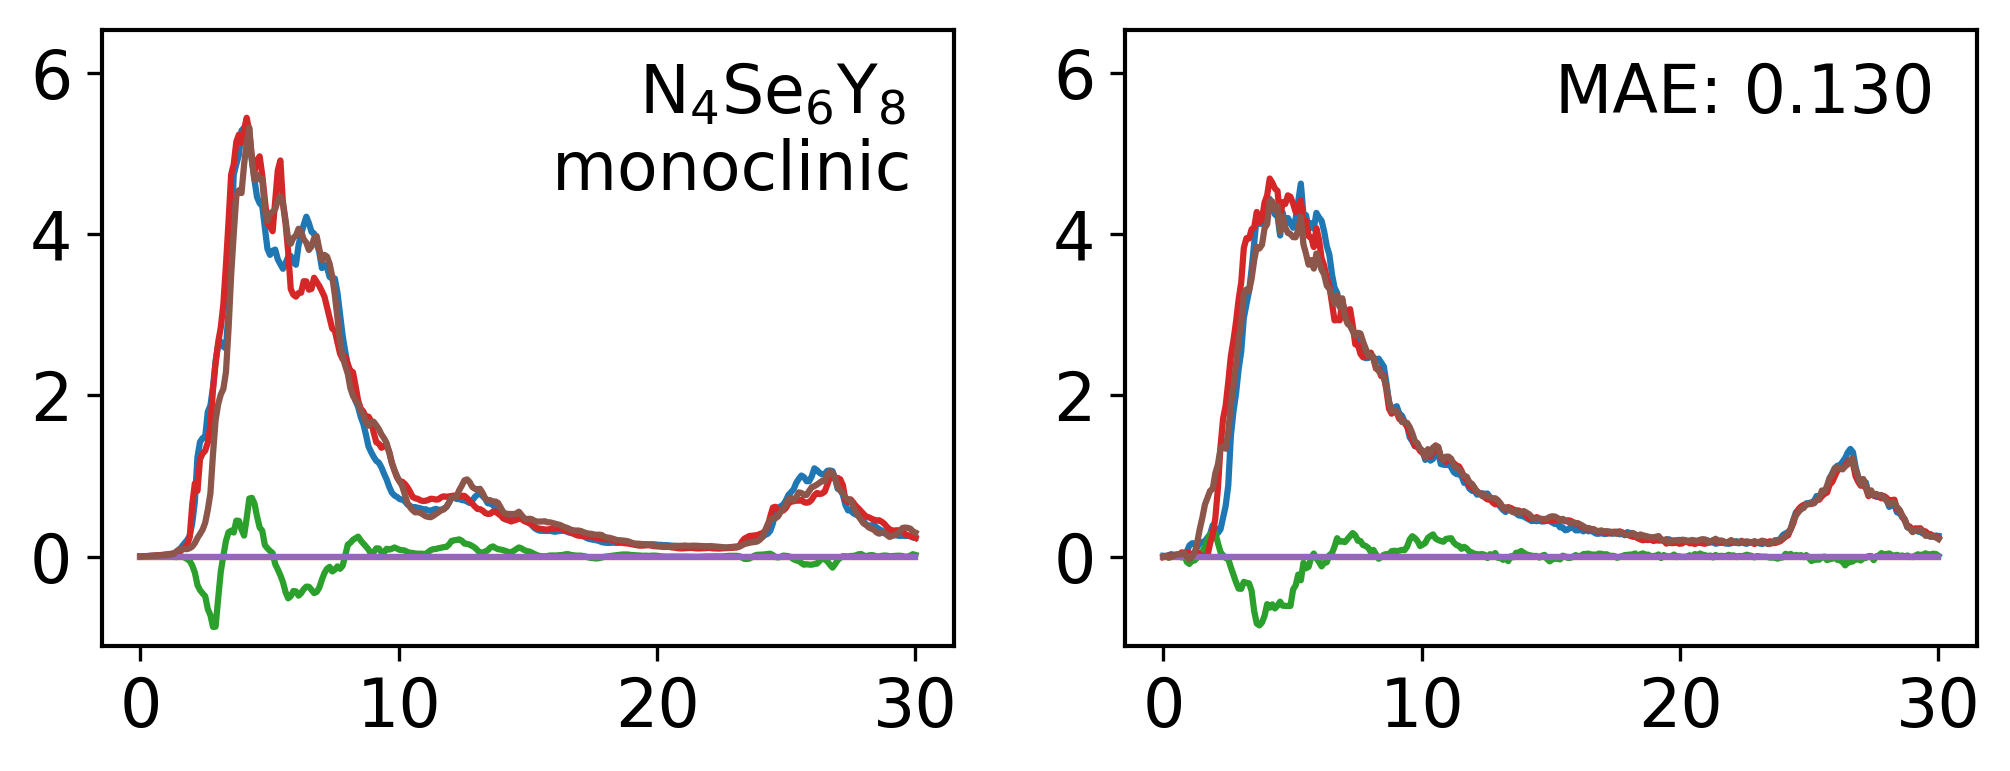

In [ ]:
# row = df.iloc[1423] # cubic
# row = df.iloc[9] # monoclinic
# row = df.iloc[182] # trigonal
row = df[df.formula=="N4Se6Y8"].iloc[0]
print(row.split)
# row = df.iloc[476] # tetragonal
true_tensor = row["rel_permittivity_imag_interp"]
pred_tensor = row["y_pred_cart"]

true_iso, true_aniso = decompose_tensor_seq(true_tensor)
pred_iso, pred_aniso = decompose_tensor_seq(pred_tensor)

true_norm = anisotropy_strength(true_aniso)
pred_norm = anisotropy_strength(pred_aniso)

# plt.title(f"{row.mp_id} | {row.crystal_system} | {row.split}")
# print(f"{row.mp_id} | {row.crystal_system} | {row.split}")
info_label = f"{row.mp_id} | {row.crystal_system} "
model_label = f"model: TSENN-B"

fig, ax = plt.subplots()



plt.title(f"${format_chemical_formula(row.formula)}$ | {row.crystal_system} | {row.split}", fontsize=16)
plt.plot(row.energies_interp, true_norm, label="Target", color='k')
plt.plot(row.energies_interp, pred_norm, label="Predict", color ='r')
plt.plot([], [], ' ', label=f"${{MAE}}_{{aniso}}^{{norm}}$: {np.mean(true_norm-pred_norm):.3f}")
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
x_ticks = np.linspace(omega[0], omega[-1], 4)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{v:.0f}" for v in x_ticks])  # integer labels

ax.set_xlabel(r"$\omega$ (eV)")
ax.set_ylabel("Anistropy strength")
ax.legend()
plt.show()

print(np.mean(true_norm-pred_norm))
plot_cartesian_tensor_comparison(df, [row.name], column_name=column, title_prefix="five_crystal_systems", n=1, show_legend=False)


In [25]:
# =====================================================
# First-derivative MAE per symmetric component
# =====================================================

triu_idx = np.triu_indices(3)  # (i,j) pairs for 6 unique components
component_labels = ["xx", "xy", "xz", "yy", "yz", "zz"]

def derivative_mae_components(pred, true, freq_axis=1):
    """
    pred, true: (N, F, 3, 3)
    return: (N, 6) per-sample per-component derivative MAE
    """
    pred_diff = torch.diff(pred, dim=freq_axis)   # (N, F-1, 3, 3)
    true_diff = torch.diff(true, dim=freq_axis)

    mae_components = []
    for i, j in zip(triu_idx[0], triu_idx[1]):
        # absolute error per component
        diff_err = torch.abs(pred_diff[:, :, i, j] - true_diff[:, :, i, j])  # (N, F-1)
        # average over frequency
        mae_comp = diff_err.mean(dim=1)  # (N,)
        mae_components.append(mae_comp)

    return torch.stack(mae_components, dim=1)  # (N, 6)

# Compute per-component derivative MAE
deriv_mae_components = derivative_mae_components(cart_pred_tensor, cart_true_tensor)

# Add to dataframe
for k, label in enumerate(component_labels):
    df[f"mae_cart_deriv_{label}"] = deriv_mae_components[:, k].cpu().numpy()

# Overall mean across components
df["mae_cart_deriv"] = deriv_mae_components.mean(dim=1).cpu().numpy()

df_train = df.loc[idx_train].copy().reset_index()
df_valid = df.loc[idx_valid].copy().reset_index()
df_test = df.loc[idx_test].copy().reset_index()

# =====================================================
# Aggregate stats for derivative MAE (cartesian components)
# =====================================================

print(f"mean derivative MAE", df_test['mae_cart_deriv'].mean(), 
      f"median derivative MAE", df_test['mae_cart_deriv'].median())

print(f"xx: mean {df_test['mae_cart_deriv_xx'].mean():.4f}, median {df_test['mae_cart_deriv_xx'].median():.4f}")
print(f"yy: mean {df_test['mae_cart_deriv_yy'].mean():.4f}, median {df_test['mae_cart_deriv_yy'].median():.4f}")
print(f"zz: mean {df_test['mae_cart_deriv_zz'].mean():.4f}, median {df_test['mae_cart_deriv_zz'].median():.4f}")

# symmetry-allowed filtering for off-diagonals
df_xz = df_test[df_test["crystal_system"].isin(["monoclinic", "triclinic"])]
print(f"xz: mean {df_xz['mae_cart_deriv_xz'].mean():.4f}, median {df_xz['mae_cart_deriv_xz'].median():.4f}")

df_xy = df_test[df_test["crystal_system"].isin(["triclinic"])]
print(f"xy: mean {df_xy['mae_cart_deriv_xy'].mean():.4f}, median {df_xy['mae_cart_deriv_xy'].median():.4f}")

df_yz = df_test[df_test["crystal_system"].isin(["triclinic"])]
print(f"yz: mean {df_yz['mae_cart_deriv_yz'].mean():.4f}, median {df_yz['mae_cart_deriv_yz'].median():.4f}")

mean derivative MAE 0.04658129869423135 median derivative MAE 0.042272457888272996
xx: mean 0.0882, median 0.0776
yy: mean 0.0886, median 0.0784
zz: mean 0.0976, median 0.0871
xz: mean 0.0261, median 0.0271
xy: mean 0.0228, median 0.0270
yz: mean 0.0258, median 0.0251


In [26]:
triu_idx = np.triu_indices(3)
component_labels = ["xx", "xy", "xz", "yy", "yz", "zz"]

def cosine_similarity_components_integrated(pred, true, freqs, tol=1e-12):
    """
    pred, true: (N, F, 3, 3) tensors
    freqs: (F,) 1D array or tensor of frequency/energy grid
    Returns: (N, 6) cosine similarity per symmetric component
             1 if both spectra are (near-)zero,
             0 if exactly one is (near-)zero.
    """
    freqs = torch.as_tensor(freqs, dtype=pred.dtype, device=pred.device)
    sims = []
    for i, j in zip(triu_idx[0], triu_idx[1]):
        p = pred[:, :, i, j]  # (N, F)
        t = true[:, :, i, j]  # (N, F)

        # inner product = ∫ p(ω) t(ω) dω
        dot = torch.trapz(p * t, freqs, dim=1)  # (N,)

        # norms = sqrt(∫ |p|² dω), sqrt(∫ |t|² dω)
        norm_p = torch.sqrt(torch.trapz(p**2, freqs, dim=1))
        norm_t = torch.sqrt(torch.trapz(t**2, freqs, dim=1))
        denom  = norm_p * norm_t

        both_zero = (norm_p <= tol) & (norm_t <= tol)
        one_zero  = ((norm_p <= tol) ^ (norm_t <= tol))
        valid     = denom > tol

        sim = torch.zeros_like(dot)
        sim[valid] = dot[valid] / denom[valid]
        sim = torch.clamp(sim, -1.0, 1.0)  # numerical safety

        # set special cases
        sim = torch.where(one_zero, torch.zeros_like(sim), sim)      # one is zero → 0
        sim = torch.where(both_zero, torch.ones_like(sim), sim)      # both zero → 1

        sims.append(sim)

    return torch.stack(sims, dim=1)  # (N, 6)
# Compute per-component safe cosine similarity
cosine_comp = cosine_similarity_components_integrated(cart_pred_tensor, cart_true_tensor, new_x)

# Store per-component columns
for k, label in enumerate(component_labels):
    df[f"cosine_sim_{label}"] = cosine_comp[:, k].cpu().numpy()

# Overall per-sample mean across 6 components, ignoring NaNs
cols = [f"cosine_sim_{label}" for label in component_labels]
df["cosine_sim"] = np.nanmean(df[cols].values, axis=1)

df_test = df.loc[idx_test].copy().reset_index()
df_test = df[df['crystal_system']=='monoclinic']
# Print aggregated stats (NaNs ignored)
for label in component_labels:
    mean_val = np.nanmean(df_test[f"cosine_sim_{label}"].values)
    median_val = np.nanmedian(df_test[f"cosine_sim_{label}"].values)
    std_val  = np.nanstd(df_test[f"cosine_sim_{label}"].values)
    print(f"{label}: {mean_val:.4f} {median_val:.4f}")

overall_mean = np.nanmean(df_test["cosine_sim"].values)
overall_std  = np.nanstd(df_test["cosine_sim"].values)
print(f"Overall: {overall_mean:.4f} ± {overall_std:.4f}")

xx: 0.9669 0.9939
xy: 1.0000 1.0000
xz: 0.6381 0.8203
yy: 0.9631 0.9945
yz: 1.0000 1.0000
zz: 0.9787 0.9944
Overall: 0.9245 ± 0.0835


In [27]:
diag_labels = ["xx", "yy", "zz"]

def kl_divergence_diagonal(pred, true, eps=1e-12):
    """
    Compute KL divergence between predicted and true spectra
    for diagonal components (xx, yy, zz).
    
    pred, true: (N, F, 3, 3) tensors
    return: (N, 3) KL divergences per diagonal component
    """
    kls = []
    for i, label in enumerate([0, 1, 2]):  # xx, yy, zz
        p = pred[:, :, i, i].clamp(min=0)   # (N, F) non-negative
        t = true[:, :, i, i].clamp(min=0)

        # normalize to probability distributions
        p = p / (p.sum(dim=1, keepdim=True) + eps)
        t = t / (t.sum(dim=1, keepdim=True) + eps)

        # KL divergence: sum t * log(t/p)
        kl = torch.sum(t * torch.log((t + eps) / (p + eps)), dim=1)  # (N,)
        kls.append(kl)

    return torch.stack(kls, dim=1)  # (N, 3)

# Compute per-diagonal KL
kl_diag = kl_divergence_diagonal(cart_pred_tensor, cart_true_tensor)


# Store in dataframe
for i, label in enumerate(diag_labels):
    df[f"kl_div_{label}"] = kl_diag[:, i].cpu().numpy()

# Mean across the 3 diagonals
df["kl_div_diag"] = kl_diag.mean(dim=1).cpu().numpy()
df_test = df.loc[idx_test].copy().reset_index()

# Print stats
for label in diag_labels:
    mean_val = df_test[f"kl_div_{label}"].mean()
    std_val  = df_test[f"kl_div_{label}"].std()
    median_val = df_test[f"kl_div_{label}"].median()
    print(f"{label}: {mean_val:.4f} ± {std_val:.4f}, {median_val:.4f}")
    
    
median_val = np.median(df_test["kl_div_diag"].values)
print(f"Median Diagonal KL: {median_val:.4f}")

overall_mean = df_test["kl_div_diag"].mean()
overall_std  = df_test["kl_div_diag"].std()
print(f"Diagonal KL (avg): {overall_mean:.4f} ± {overall_std:.4f}")



xx: 0.0905 ± 0.1948, 0.0488
yy: 0.0845 ± 0.1930, 0.0469
zz: 0.1421 ± 0.4430, 0.0585
Median Diagonal KL: 0.0556
Diagonal KL (avg): 0.1057 ± 0.2725


In [28]:
diag_labels = ["xx", "yy", "zz"]

def sc_diagonal(pred, true, eps=1e-12):
    """
    Compute spectral similarity (SC) for diagonal components (xx, yy, zz).
    
    pred, true: (N, F, 3, 3) tensors
    return: (N, 3) SC per diagonal component
    """
    scs = []
    for i in [0, 1, 2]:  # xx, yy, zz
        p = pred[:, :, i, i]  # (N, F)
        t = true[:, :, i, i]

        # numerator: integral of abs diff
        diff_int = torch.sum(torch.abs(t - p), dim=1)  # (N,)

        # denominator: integral of abs true
        norm_int = torch.sum(torch.abs(t), dim=1) + eps

        sc_val = 1.0 - diff_int / norm_int
        scs.append(sc_val)

    return torch.stack(scs, dim=1)  # (N, 3)

# Compute per-diagonal SC
sc_diag = sc_diagonal(cart_pred_tensor, cart_true_tensor)

# Store in dataframe
for i, label in enumerate(diag_labels):
    df[f"sc_{label}"] = sc_diag[:, i].cpu().numpy()

# Mean across the 3 diagonals
df["sc_diag"] = sc_diag.mean(dim=1).cpu().numpy()

df_test = df.loc[idx_test].copy().reset_index()

# Print stats
for label in diag_labels:
    mean_val   = df_test[f"sc_{label}"].mean()
    median_val = df_test[f"sc_{label}"].median()
    std_val    = df_test[f"sc_{label}"].std()
    print(f"{label}: mean = {mean_val:.4f}, median = {median_val:.4f}, std = {std_val:.4f}")

overall_mean   = df_test["sc_diag"].mean()
overall_median = df_test["sc_diag"].median()
overall_std    = df_test["sc_diag"].std()
print(f"Diagonal SC (overall): mean = {overall_mean:.4f}, median = {overall_median:.4f}, std = {overall_std:.4f}")

xx: mean = 0.7614, median = 0.7821, std = 0.1491
yy: mean = 0.7657, median = 0.7812, std = 0.1492
zz: mean = 0.7255, median = 0.7650, std = 0.3174
Diagonal SC (overall): mean = 0.7508, median = 0.7743, std = 0.1962


In [29]:
def emd_diagonal(pred, true, eps=1e-12):
    """
    Compute Earth Mover’s Distance (Wasserstein-1) for diagonal components (xx, yy, zz).
    
    pred, true: (N, F, 3, 3) tensors
    return: (N, 3) EMD per diagonal component
    """
    emds = []
    for i in [0, 1, 2]:  # xx, yy, zz
        p = pred[:, :, i, i].clamp(min=0)  # (N, F), non-negative
        t = true[:, :, i, i].clamp(min=0)

        # normalize into probability distributions
        p = p / (p.sum(dim=1, keepdim=True) + eps)
        t = t / (t.sum(dim=1, keepdim=True) + eps)

        # cumulative distributions (CDFs)
        p_cdf = torch.cumsum(p, dim=1)
        t_cdf = torch.cumsum(t, dim=1)

        # Wasserstein-1 distance = L1 distance between CDFs
        emd_val = torch.sum(torch.abs(p_cdf - t_cdf), dim=1)  # (N,)
        emds.append(emd_val)

    return torch.stack(emds, dim=1)  # (N, 3)
emd_diag = emd_diagonal(cart_pred_tensor, cart_true_tensor)

# Store in dataframe
for i, label in enumerate(diag_labels):
    df[f"emd_{label}"] = emd_diag[:, i].cpu().numpy()

# Mean across the 3 diagonals
df["emd_diag"] = emd_diag.mean(dim=1).cpu().numpy()
df_test = df.loc[idx_test].copy().reset_index()
# Stats
for label in diag_labels:
    mean_val   = df_test[f"emd_{label}"].mean()
    median_val = df_test[f"emd_{label}"].median()
    std_val    = df_test[f"emd_{label}"].std()
    print(f"{label}: mean = {mean_val:.4f}, median = {median_val:.4f}, std = {std_val:.4f}")

overall_mean   = df_test["emd_diag"].mean()
overall_median = df_test["emd_diag"].median()
overall_std    = df_test["emd_diag"].std()
print(f"Diagonal EMD (overall): mean = {overall_mean:.4f}, median = {overall_median:.4f}, std = {overall_std:.4f}")

xx: mean = 3.8104, median = 2.6273, std = 4.1533
yy: mean = 3.6600, median = 2.5157, std = 4.2410
zz: mean = 4.5449, median = 2.4842, std = 7.8055
Diagonal EMD (overall): mean = 4.0051, median = 2.5799, std = 5.0227


In [30]:
def compute_aniso_mae(row):
    true_tensor = row["rel_permittivity_imag_interp"]  # shape (N_ω, 3, 3)
    pred_tensor = row["y_pred_cart"]

    # Decompose into isotropic + anisotropic parts
    _, true_aniso = decompose_tensor_seq(true_tensor)
    _, pred_aniso = decompose_tensor_seq(pred_tensor)

    results = {}
    comp_labels = ["xx", "yy", "zz", "xy", "xz", "yz"]
    triu_idx = [(0,0), (1,1), (2,2), (0,1), (0,2), (1,2)]

    # --- (1) Per-component anisotropic MAEs ---
    for (i, j), lbl in zip(triu_idx, comp_labels):
        diff = np.abs(true_aniso[:, i, j] - pred_aniso[:, i, j])
        results[f"aniso_mae_{lbl}"] = np.mean(diff[np.isfinite(diff)])


    return pd.Series(results)
def compute_component_avg(row):
    system = row["crystal_system"]
    comp_labels = ["xx", "yy", "zz"]  # diagonals always included

    if system in ["monoclinic"]:
        comp_labels += ["xz"]
    elif system in ["triclinic"]:
        comp_labels += ["xy", "xz", "yz"]

    values = [row[f"aniso_mae_{lbl}"] for lbl in comp_labels]
    return np.mean(values)


# Add per-component anisotropy MAEs
df_aniso = df.apply(compute_aniso_mae, axis=1)
for col in df_aniso.columns:
    df[col] = df_aniso[col]
df["aniso_mae_avg_strat"] = df.apply(compute_component_avg, axis=1)

df_test  = df.loc[idx_test].copy().reset_index()
# Diagonal anisotropy always relevant
for lbl in ["xx", "yy", "zz"]:
    mean_val   = df_test[f"aniso_mae_{lbl}"].mean()
    median_val = df_test[f"aniso_mae_{lbl}"].median()
    print(f"aniso {lbl}: mean = {mean_val:.4f}, median = {median_val:.4f}")

# Off-diagonal components: filter by crystal system
df_xz = df_test[df_test["crystal_system"].isin(["monoclinic", "triclinic"])]
print(f"aniso xz: mean = {df_xz['aniso_mae_xz'].mean():.4f}, "
      f"median = {df_xz['aniso_mae_xz'].median():.4f}")

df_xy = df_test[df_test["crystal_system"].isin(["triclinic"])]
print(f"aniso xy: mean = {df_xy['aniso_mae_xy'].mean():.4f}, "
      f"median = {df_xy['aniso_mae_xy'].median():.4f}")

df_yz = df_test[df_test['crystal_system'].isin(["triclinic"])]
print(f"aniso yz: mean = {df_yz['aniso_mae_yz'].mean():.4f}, "
      f"median = {df_yz['aniso_mae_yz'].median():.4f}")
mean_val   = df_test["aniso_mae_avg_strat"].mean()
median_val = df_test["aniso_mae_avg_strat"].median()
print(f"Aniso MAE (stratified avg): mean = {mean_val:.4f}, median = {median_val:.4f}")



aniso xx: mean = 0.0738, median = 0.0633
aniso yy: mean = 0.0737, median = 0.0633
aniso zz: mean = 0.1164, median = 0.1025
aniso xz: mean = 0.0648, median = 0.0631
aniso xy: mean = 0.0632, median = 0.0711
aniso yz: mean = 0.0617, median = 0.0568
Aniso MAE (stratified avg): mean = 0.0872, median = 0.0795


In [33]:
comp_labels = ["xx", "yy", "zz", "xy", "xz", "yz"]
triu_idx = [(0,0), (1,1), (2,2), (0,1), (0,2), (1,2)]

# --- Step 1: compute per-component maxima ---
def per_component_max(row):
    tensor = row["rel_permittivity_imag"]  # shape (N_ω, 3, 3)
    results = {}
    for (i, j), lbl in zip(triu_idx, comp_labels):
        results[f"true_max_{lbl}"] = np.nanmax(np.abs(tensor[:, i, j]))
    return pd.Series(results)

df_true_max = df.apply(per_component_max, axis=1)
for col in df_true_max.columns:
    df[col] = df_true_max[col]

# --- Step 2: subset test data ---
df_test = df.loc[idx_test].copy().reset_index()

# --- Step 3: diagonals (always present) ---
for lbl in ["xx", "yy", "zz"]:
    mean_val   = df_test[f"true_max_{lbl}"].mean()
    median_val = df_test[f"true_max_{lbl}"].median()
    print(f"{lbl}: mean of maxima = {mean_val:.4f}, median of maxima = {median_val:.4f}")

# --- Step 4: xz (monoclinic & triclinic only) ---
df_xz = df_test[df_test["crystal_system"].isin(["monoclinic", "triclinic"])]
mean_val   = df_xz["true_max_xz"].mean()
median_val = df_xz["true_max_xz"].median()
print(f"xz: mean of maxima = {mean_val:.4f}, median of maxima = {median_val:.4f}")

# --- Step 5: xy (triclinic only) ---
df_xy = df_test[df_test["crystal_system"] == "triclinic"]
mean_val   = df_xy["true_max_xy"].mean()
median_val = df_xy["true_max_xy"].median()
print(f"xy: mean of maxima = {mean_val:.4f}, median of maxima = {median_val:.4f}")

# --- Step 6: yz (triclinic only) ---
df_yz = df_test[df_test["crystal_system"] == "triclinic"]
mean_val   = df_yz["true_max_yz"].mean()
median_val = df_yz["true_max_yz"].median()
print(f"yz: mean of maxima = {mean_val:.4f}, median of maxima = {median_val:.4f}")
df_xz = df_test[df_test["crystal_system"].isin(["monoclinic", "triclinic"])]
mean_val   = df_xz["true_max_xz"].mean()
median_val = df_xz["true_max_xz"].median()
mean_mae_xz = df_xz["mae_cart_xz"].mean()
median_mae_xz = df_xz["mae_cart_xz"].median()

print("ratio", mean_mae_xz/mean_val * 100, median_mae_xz/median_val *100)

xx: mean of maxima = 7.3530, median of maxima = 5.9227
yy: mean of maxima = 7.5824, median of maxima = 6.1098
zz: mean of maxima = 7.8695, median of maxima = 6.1470
xz: mean of maxima = 0.9087, median of maxima = 0.4910
xy: mean of maxima = 0.7656, median of maxima = 0.8843
yz: mean of maxima = 0.9482, median of maxima = 0.8795
ratio 7.128484809194183 12.845070004037714


In [34]:
comp_labels = ["xx", "yy", "zz", "xy", "xz", "yz"]
triu_idx = [(0,0), (1,1), (2,2), (0,1), (0,2), (1,2)]

# --- Step 1: compute per-component maxima ---
def per_component_max(row):
    tensor = row["rel_permittivity_imag"]  # shape (N_ω, 3, 3)
    results = {}
    for (i, j), lbl in zip(triu_idx, comp_labels):
        results[f"true_max_{lbl}"] = np.nanmax(np.abs(tensor[:, i, j]))
    return pd.Series(results)

df_true_max = df.apply(per_component_max, axis=1)
for col in df_true_max.columns:
    df[col] = df_true_max[col]

# --- Step 2: subset test data ---
df_test = df.loc[idx_test].copy().reset_index()

# --- Helper: stratify by symmetry ---
def get_subset(df, comp):
    if comp in ["xx", "yy", "zz"]:
        return df
    elif comp == "xz":
        return df[df["crystal_system"].isin(["monoclinic", "triclinic"])]
    elif comp in ["xy", "yz"]:
        return df[df["crystal_system"] == "triclinic"]
    return df

# --- Step 3: compute relative errors ---
print("Contrast errors (mean/median MAE divided by mean/median max, in %):")
for lbl in comp_labels:
    subset = get_subset(df_test, lbl)
    if len(subset) == 0:
        continue
    print(lbl, subset[f"true_max_{lbl}"].mean())
    print(lbl, subset[f"true_max_{lbl}"].median())
    mean_max   = subset[f"true_max_{lbl}"].mean()
    median_max = subset[f"true_max_{lbl}"].median()
    mean_mae   = subset[f"mse_cart_{lbl}"].mean()
    median_mae = subset[f"mse_cart_{lbl}"].median()

    rel_mean   = mean_mae / mean_max * 100 if mean_max > 0 else np.nan
    rel_median = median_mae / median_max * 100 if median_max > 0 else np.nan

    print(f"{lbl}: rel_mean = {rel_mean:.1f}%, rel_median = {rel_median:.1f}%")

Contrast errors (mean/median MAE divided by mean/median max, in %):
xx 7.3529740311558065
xx 5.922734707397478
xx: rel_mean = 5.7%, rel_median = 2.0%
yy 7.58244148071947
yy 6.109756534834072
yy: rel_mean = 5.2%, rel_median = 2.0%
zz 7.869527607120596
zz 6.147046387662506
zz: rel_mean = 5.7%, rel_median = 2.6%
xy 0.7655529693094534
xy 0.8842558258502764
xy: rel_mean = 5.4%, rel_median = 4.6%
xz 0.9087430695900279
xz 0.4909742524615867
xz: rel_mean = 3.9%, rel_median = 3.4%
yz 0.9481620156758446
yz 0.879468609931916
yz: rel_mean = 2.7%, rel_median = 2.1%


In [35]:
comp_labels = ["xx", "yy", "zz", "xy", "xz", "yz"]
triu_idx = [(0,0), (1,1), (2,2), (0,1), (0,2), (1,2)]

# --- Step 1: compute per-component maxima ---
def per_component_max(row):
    tensor = row["rel_permittivity_imag"]  # shape (N_ω, 3, 3)
    results = {}
    for (i, j), lbl in zip(triu_idx, comp_labels):
        results[f"true_max_{lbl}"] = np.nanmax(np.abs(tensor[:, i, j]))
    return pd.Series(results)

df_true_max = df.apply(per_component_max, axis=1)
for col in df_true_max.columns:
    df[col] = df_true_max[col]

# --- Step 2: subset test data ---
df_test = df.loc[idx_test].copy().reset_index()

# --- Helper: stratify by symmetry ---
def get_subset(df, comp):
    if comp in ["xx", "yy", "zz"]:
        return df
    elif comp == "xz":
        return df[df["crystal_system"].isin(["monoclinic", "triclinic"])]
    elif comp in ["xy", "yz"]:
        return df[df["crystal_system"] == "triclinic"]
    return df

# --- Step 3: compute relative errors ---
print("Contrast errors (mean/median MAE divided by mean/median max, in %):")
for lbl in comp_labels:
    subset = get_subset(df_test, lbl)
    if len(subset) == 0:
        continue
    print(lbl, subset[f"true_max_{lbl}"].mean())
    print(lbl, subset[f"true_max_{lbl}"].median())
    mean_max   = subset[f"true_max_{lbl}"].mean()
    median_max = subset[f"true_max_{lbl}"].median()
    mean_mae   = subset[f"mse_cart_{lbl}"].mean()
    median_mae = subset[f"mse_cart_{lbl}"].median()

    rel_mean   = mean_mae / mean_max * 100 if mean_max > 0 else np.nan
    rel_median = median_mae / median_max * 100 if median_max > 0 else np.nan

    print(f"{lbl}: rel_mean = {rel_mean:.1f}%, rel_median = {rel_median:.1f}%")

Contrast errors (mean/median MAE divided by mean/median max, in %):
xx 7.3529740311558065
xx 5.922734707397478
xx: rel_mean = 5.7%, rel_median = 2.0%
yy 7.58244148071947
yy 6.109756534834072
yy: rel_mean = 5.2%, rel_median = 2.0%
zz 7.869527607120596
zz 6.147046387662506
zz: rel_mean = 5.7%, rel_median = 2.6%
xy 0.7655529693094534
xy 0.8842558258502764
xy: rel_mean = 5.4%, rel_median = 4.6%
xz 0.9087430695900279
xz 0.4909742524615867
xz: rel_mean = 3.9%, rel_median = 3.4%
yz 0.9481620156758446
yz 0.879468609931916
yz: rel_mean = 2.7%, rel_median = 2.1%


In [36]:
df_no_cubic = df_test[df_test["crystal_system"] == "monoclinic"]
df_sorted = df_no_cubic.sort_values(by="aniso_norm_mae", ascending=True)
df_sorted.head(10)

,index,formula,symmetrized_structure,mp_id,bandgap_openmx,bandgap_mp,bandgap_type,crystal_system,omega,species,...,aniso_mae_xy,aniso_mae_xz,aniso_mae_yz,aniso_mae_avg_strat,true_max_xx,true_max_yy,true_max_zz,true_max_xy,true_max_xz,true_max_yz
100,282,Ag4S2,"(Atom('Ag', [3.9419332865103085, 2.85493031, 0...",mp-2212763,1.771781,0.6819,Indirect,monoclinic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[S, Ag]",...,3.337190e-17,0.004841,3.395447e-17,0.012825,6.386044,6.166485,6.147046,0.0,0.074158,0.0
103,65,H2Na2O2,"(Atom('Na', [0.980466320280712, 0.843024999999...",mp-23940,2.978016,2.8228,Direct,monoclinic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[H, Na, O]",...,3.740612e-18,0.017560,4.721075e-18,0.021009,1.311372,1.362091,1.618690,0.0,0.100593,0.0
90,1195,AsCd3I3,"(Atom('Cd', [4.502221735644133, 2.278749999999...",mp-676464,1.103491,0.8399,Direct,monoclinic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[As, I, Cd]",...,1.576669e-18,0.025541,1.755013e-18,0.042809,4.538025,3.725218,3.653693,0.0,0.318050,0.0
104,664,Ga8S12,"(Atom('Ga', [1.954397487849071, 3.655773415999...",mp-539,1.886252,1.7106,Indirect,monoclinic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[S, Ga]",...,7.210673e-17,0.057926,4.049647e-17,0.066272,5.454264,5.135629,6.443060,0.0,0.488530,0.0
106,571,Cs2Ge2I6,"(Atom('Cs', [3.388148968630324, 4.2242, 3.5897...",mp-28377,1.117680,0.9905,Direct,monoclinic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[Cs, Ge, I]",...,7.956879e-18,0.063066,2.788874e-18,0.046698,3.339021,4.030665,3.084609,0.0,0.561155,0.0
92,77,Ag8O8Pb4,"(Atom('Ag', [4.3312, 0.0, 0.0], index=0), Atom...",mp-20210,1.522730,1.3818,Indirect,monoclinic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[Pb, O, Ag]",...,2.364904e-17,0.075051,3.039029e-17,0.082802,5.651159,7.038138,5.537131,0.0,1.330504,0.0
93,1334,Cd2P8,"(Atom('Cd', [-0.6145378423208869, 2.58605, 3.7...",mp-7904,0.659764,0.6551,Indirect,monoclinic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[P, Cd]",...,1.368116e-16,0.068364,1.494414e-16,0.071266,8.440873,9.401720,9.074079,0.0,1.392347,0.0
99,122,CaI4Pb,"(Atom('Ca', [-0.014651946307052459, 2.2859, 3....",mp-754540,3.053011,2.9157,Indirect,monoclinic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[Pb, Ca, I]",...,2.157180e-18,0.068047,2.055631e-18,0.066332,6.730465,7.303759,7.133600,0.0,1.851157,0.0
94,1175,N4Se6Y8,"(Atom('Y', [-0.7368582822034303, 1.9644, 5.060...",mp-1029349,1.442485,1.3943,Indirect,monoclinic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[N, Se, Y]",...,1.483999e-18,0.152356,8.732983e-19,0.113270,5.366899,5.451230,5.338843,0.0,0.915862,0.0
96,906,Br3PZn3,"(Atom('Zn', [3.1047733525742838, 0.0, 2.075664...",mp-1215629,2.088369,1.6198,Direct,monoclinic,"[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07...","[Zn, Br, P]",...,2.731498e-18,0.032037,2.456441e-18,0.079617,4.659843,3.963624,3.760962,0.0,0.398349,0.0


,quartile_label,_quartile,aniso_norm_mae,mp_id,formula,split
94,Q3,3,0.11882,mp-1029349,N4Se6Y8,Test


N4Se6Y8: aniso_norm_mae=0.1188 → Q3


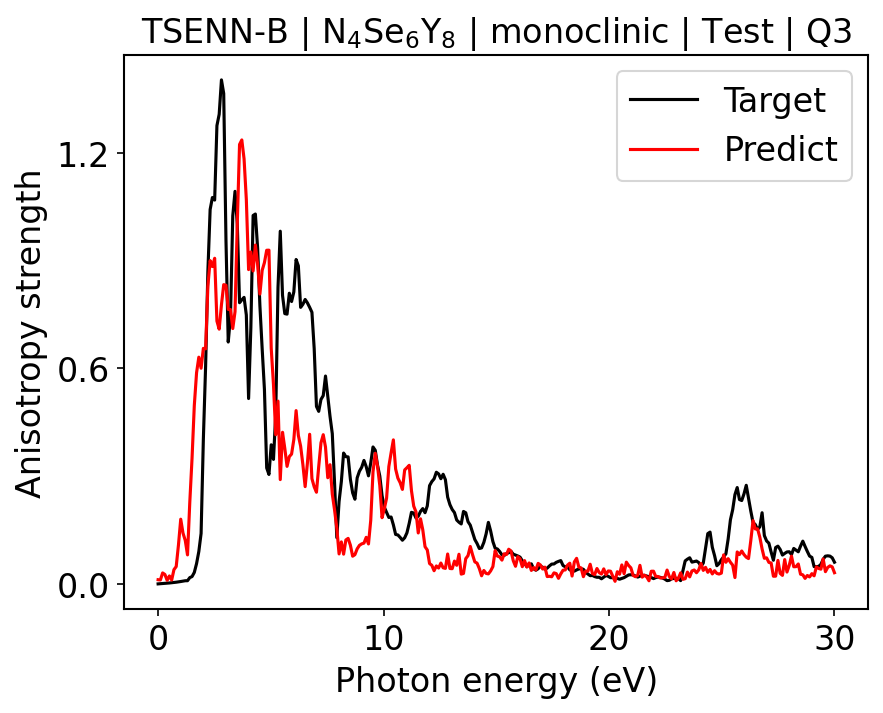

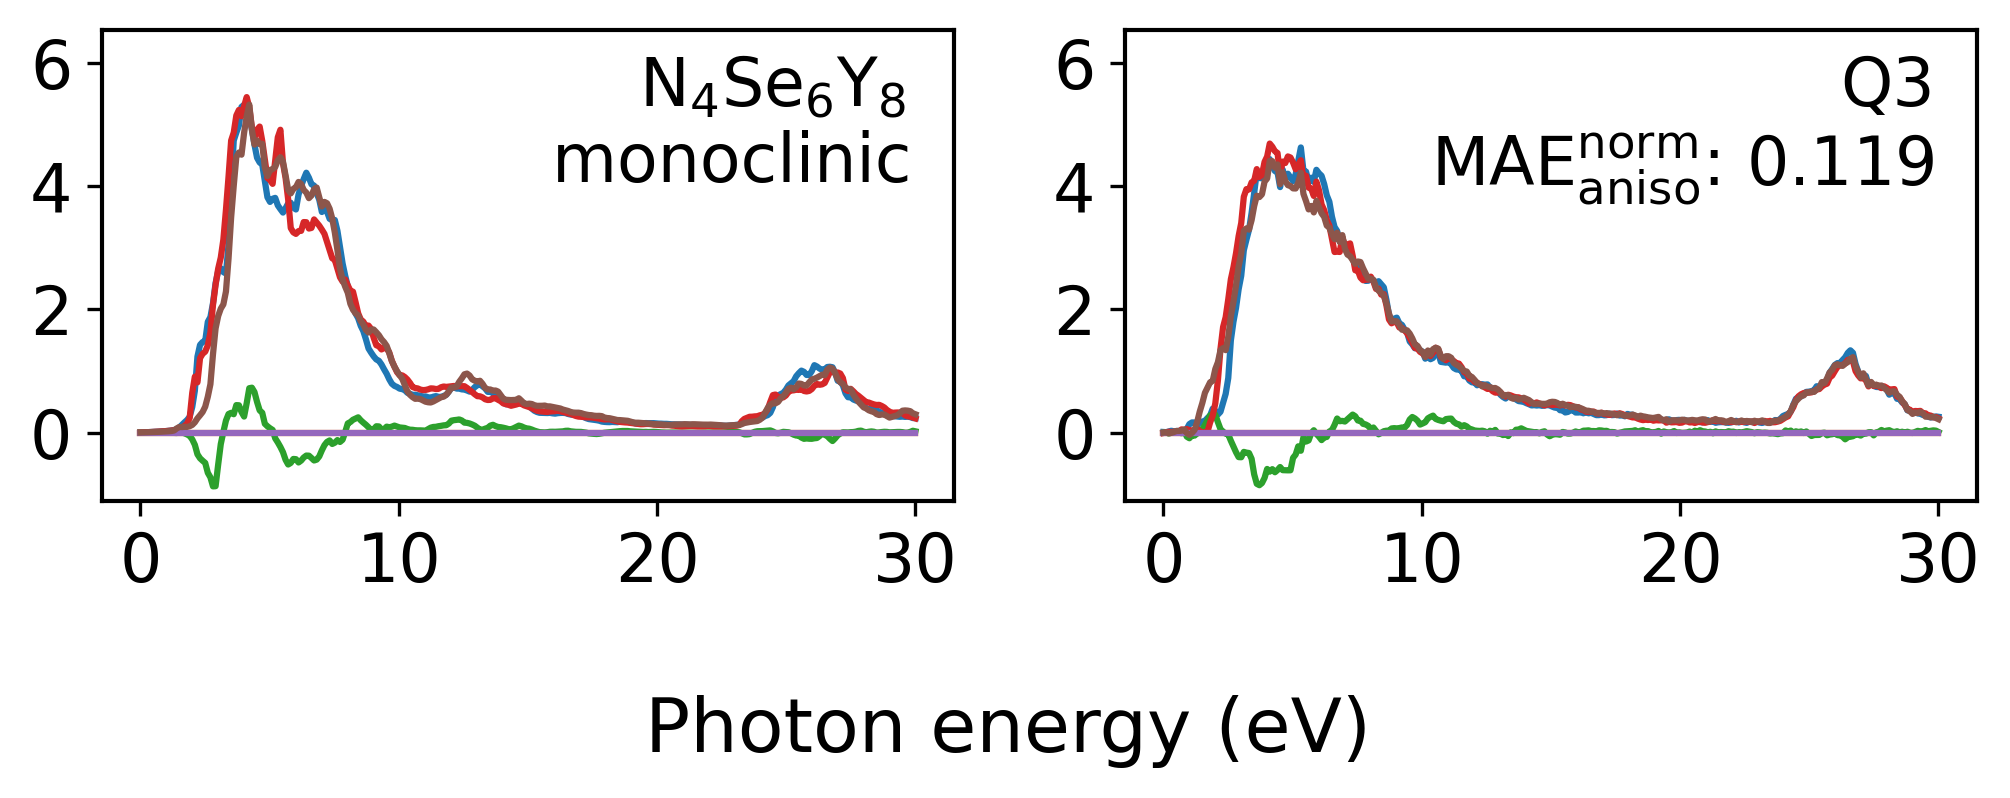

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# -------- config --------
df_source = df_test
score_col = "aniso_norm_mae"
system_key = "crystal_system"
target_formula = "N4Se6Y8"

# -------- helper functions --------
def quartile_edges(values):
    q1, q2, q3 = np.quantile(values, (0.25, 0.5, 0.75))
    return q1, q2, q3

def which_quartile(value, q1, q2, q3):
    if value <= q1:
        return 1
    elif value <= q2:
        return 2
    elif value <= q3:
        return 3
    else:
        return 4

# -------- 1) global quartile edges over test set --------
all_vals = df_source[score_col].dropna().values
if all_vals.size == 0:
    raise ValueError(f"No valid values in '{score_col}'")
q1, q2, q3 = quartile_edges(all_vals)

# -------- 2) get your target material --------
row = df_source[df_source.formula == target_formula].iloc[0]

# assign quartile and label
quartile_idx = which_quartile(row[score_col], q1, q2, q3)
quartile_label = f"Q{quartile_idx}"

# wrap into a picked DataFrame for consistency
picked = pd.DataFrame([row]).copy()
picked["_quartile"] = quartile_idx
picked["quartile_label"] = quartile_label

# summarize
summary_cols = ["quartile_label", "_quartile", score_col, "mp_id", "formula", "split"]
display(picked[summary_cols])

print(f"{row.formula}: {score_col}={row[score_col]:.4f} → {quartile_label}")

# -------- 3) plot anisotropy curve --------
true_tensor = row["rel_permittivity_imag_interp"]
pred_tensor = row["y_pred_cart"]

true_iso, true_aniso = decompose_tensor_seq(true_tensor)
pred_iso, pred_aniso = decompose_tensor_seq(pred_tensor)

true_norm = anisotropy_strength(true_aniso)
pred_norm = anisotropy_strength(pred_aniso)

fig, ax = plt.subplots()
plt.title(
    f"TSENN-B | ${format_chemical_formula(row.formula)}$ | "
    f"{row.crystal_system} | {row.split} | {quartile_label}",
    fontsize=16
)
plt.plot(row.energies_interp, true_norm, label="Target", color='k')
plt.plot(row.energies_interp, pred_norm, label="Predict", color='r')

ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
x_ticks = np.linspace(row.energies_interp[0], row.energies_interp[-1], 4)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{v:.0f}" for v in x_ticks])
ax.set_xlabel("Photon energy (eV)")
ax.set_ylabel("Anisotropy strength")
ax.legend()
plt.show()

# -------- 4) plot using your cartesian comparison function --------
df_plot = df_source.copy()
df_plot.loc[row.name, "quartile_label"] = quartile_label

plot_cartesian_tensor_comparison(
    df_plot,
    [row.name],
    column_name="rel_permittivity_imag_interp",
    title_prefix=f"five_crystal_systems_{quartile_label}",
    n=1,
    show_legend=False,
    mae_column="aniso_norm_mae",
    shared_xlabel="Photon energy (eV)",
    shared_xlabel_y_pos = 0.1
)

,quartile_label,quartile,aniso_norm_mae,mp_id,formula,split
103,Q1,1,0.032475,mp-23940,H2Na2O2,Test
106,Q2,2,0.078048,mp-28377,Cs2Ge2I6,Test
105,Q3,3,0.178189,mp-568666,Au4I12Rb4,Test
95,Q4,4,0.206392,mp-675651,Mg2P2S6,Test


Q1: H2Na2O2
Q2: Cs2Ge2I6
Q3: Au4I12Rb4
Q4: Mg2P2S6
Picked 4 total — Q1:1, Q2:1, Q3:1, Q4:1


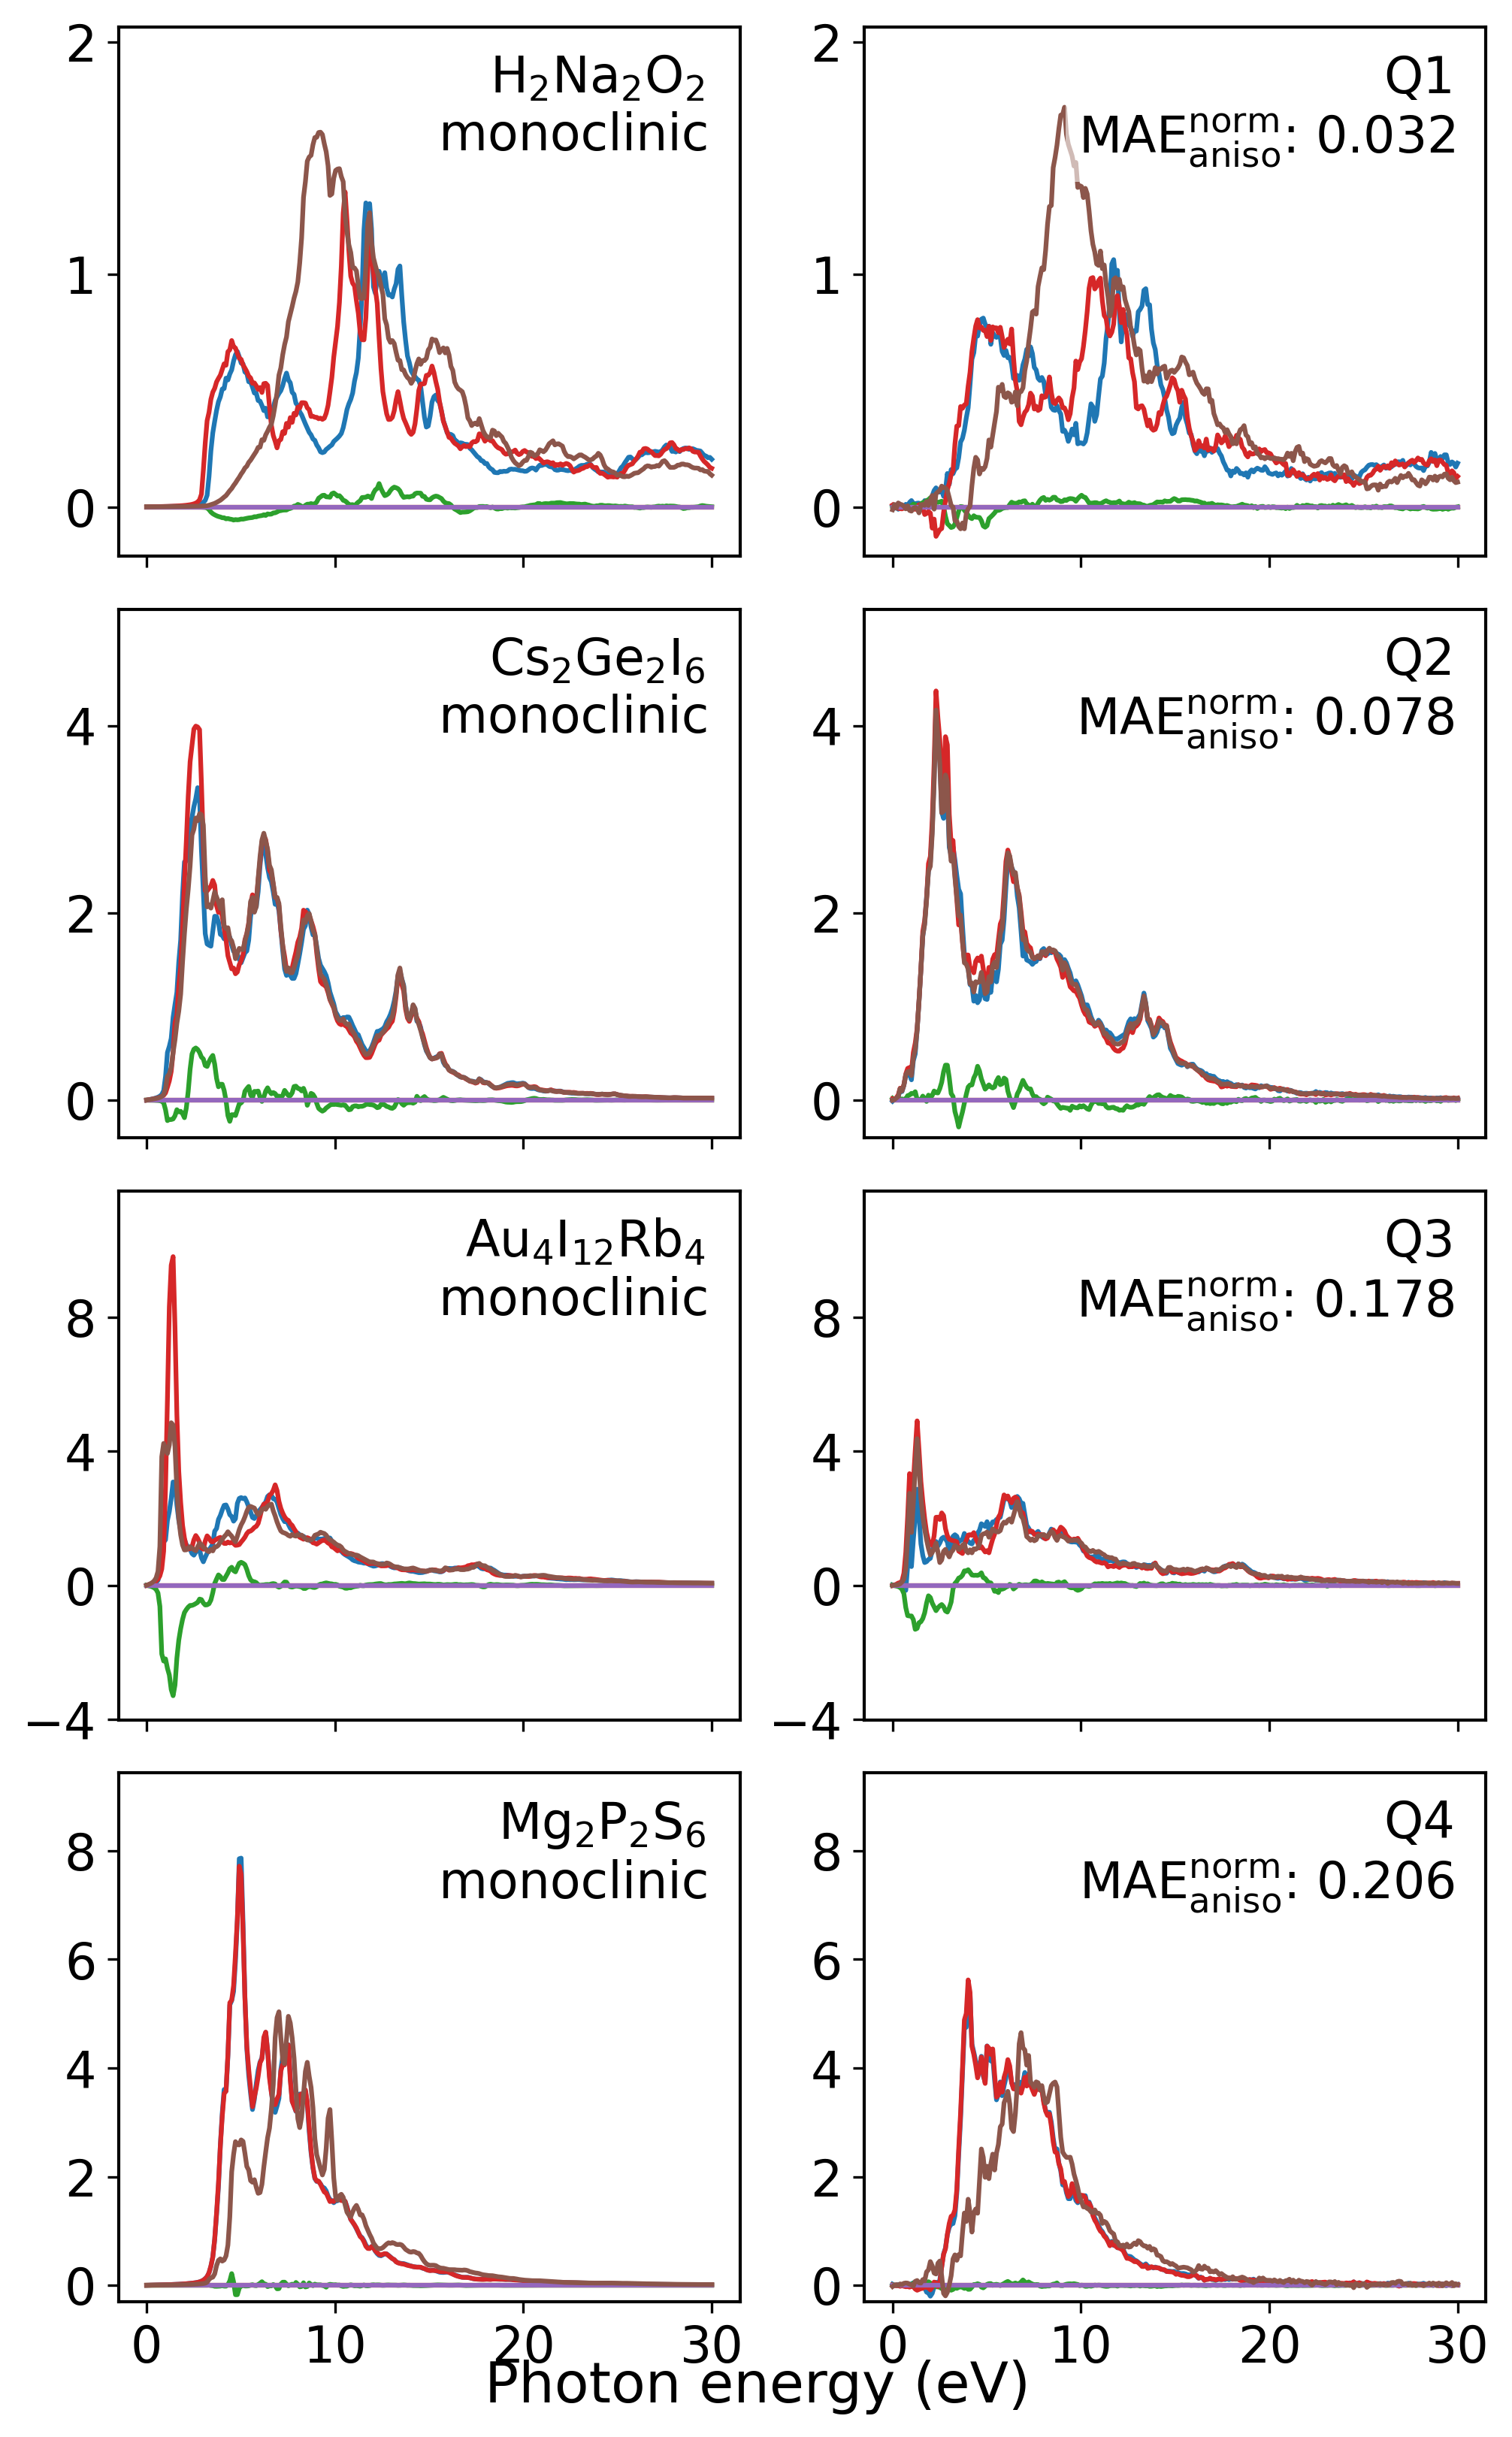

In [38]:
df_source     = df_test                 # use your test split (or df)
system_key    = "crystal_system"
score_col     = "aniso_norm_mae"        # or "aniso_mae"
n_per_quart   = 1
random_state  = 43                    # set e.g. 42 for reproducible sampling #42, 12 16, 23

# -------- same quartile rule as your get_quartile() --------
def quartile_edges(values):
    q1, q2, q3 = np.quantile(values, (0.25, 0.5, 0.75))
    return q1, q2, q3

def which_quartile(value, q1, q2, q3):
    if value <= q1:
        return 1
    elif value <= q2:
        return 2
    elif value <= q3:
        return 3
    else:
        return 4

# -------- 1) global quartile edges over ALL crystal systems --------
all_vals = df_source[score_col].dropna().values
if all_vals.size == 0:
    raise ValueError(f"No valid values found in column '{score_col}'.")
q1, q2, q3 = quartile_edges(all_vals)

# -------- 2) filter monoclinic and assign quartile by GLOBAL edges --------
mono = df_source[df_source[system_key].str.lower() == "monoclinic"].copy()
mono = mono[mono[score_col].notna()]
if mono.empty:
    raise ValueError("No monoclinic rows with valid scores found.")

mono["_quartile"] = mono[score_col].apply(lambda v: which_quartile(v, q1, q2, q3))

# -------- 3) sample 4 per quartile from monoclinic --------
picked_rows = []
for q in [1, 2, 3, 4]:
    cand = mono[mono["_quartile"] == q]
    if cand.empty:
        print(f"[WARN] Quartile Q{q} has 0 monoclinic candidates. Skipping.")
        continue
    take = min(len(cand), n_per_quart)
    samp = cand.sample(n=take, random_state=random_state, replace=False)
    picked_rows.append(samp)

picked = pd.concat(picked_rows, axis=0) if picked_rows else pd.DataFrame(columns=mono.columns)
# After you've created `picked`
picked = pd.concat(picked_rows, axis=0) if picked_rows else pd.DataFrame(columns=mono.columns)

# Create a new label column, e.g. "Q1", "Q2", ...
picked["quartile_label"] = "Q" + picked["_quartile"].astype(str)

# Optional: include this in the summary for clarity
summary_cols = ["quartile_label", "_quartile", score_col, "mp_id", "formula", "split"]
summary = picked[summary_cols].sort_values(by=["_quartile", score_col]).copy()
summary.rename(columns={"_quartile": "quartile"}, inplace=True)
display(summary)

# Indices for plotting
picked_idx_labels = picked.index.tolist()
plot_idx_pos = df_source.index.get_indexer(picked_idx_labels)

# ---- print what’s picked ----
for q_label, formula in zip(picked["quartile_label"], picked["formula"]):
    print(f"{q_label}: {formula}")

print(f"Picked {len(picked_idx_labels)} total — "
      + ", ".join([f"Q{q}:{(summary.quartile==q).sum()}" for q in [1,2,3,4]]))

df_plot = df_source.copy()
if not picked.empty:
    df_plot.loc[picked.index, "quartile_label"] = picked["quartile_label"]

# 2) Make sure all indices were found (no -1s from get_indexer)
missing_mask = (plot_idx_pos < 0)
if missing_mask.any():
    missing_labels = [picked_idx_labels[i] for i, bad in enumerate(missing_mask) if bad]
    raise ValueError(f"Some picked indices not found in df_source: {missing_labels}")

# 3) Plot using df_plot (now it contains 'quartile_label' on those rows)
plot_cartesian_tensor_comparison(
    df_plot,                              
    plot_idx_pos,
    column_name='rel_permittivity_imag_interp',
    title_prefix="monoclinic_quartiles_global_edges_random4",
    n=len(plot_idx_pos),
    show_legend=False,
    mae_column="aniso_norm_mae",
    shared_xlabel="Photon energy (eV)",
    shared_xlabel_y_pos = 0.095
)

/tmp/ipykernel_816588/2814877496.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Train' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[idx, 'split'] = split_name
/tmp/ipykernel_816588/2814877496.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


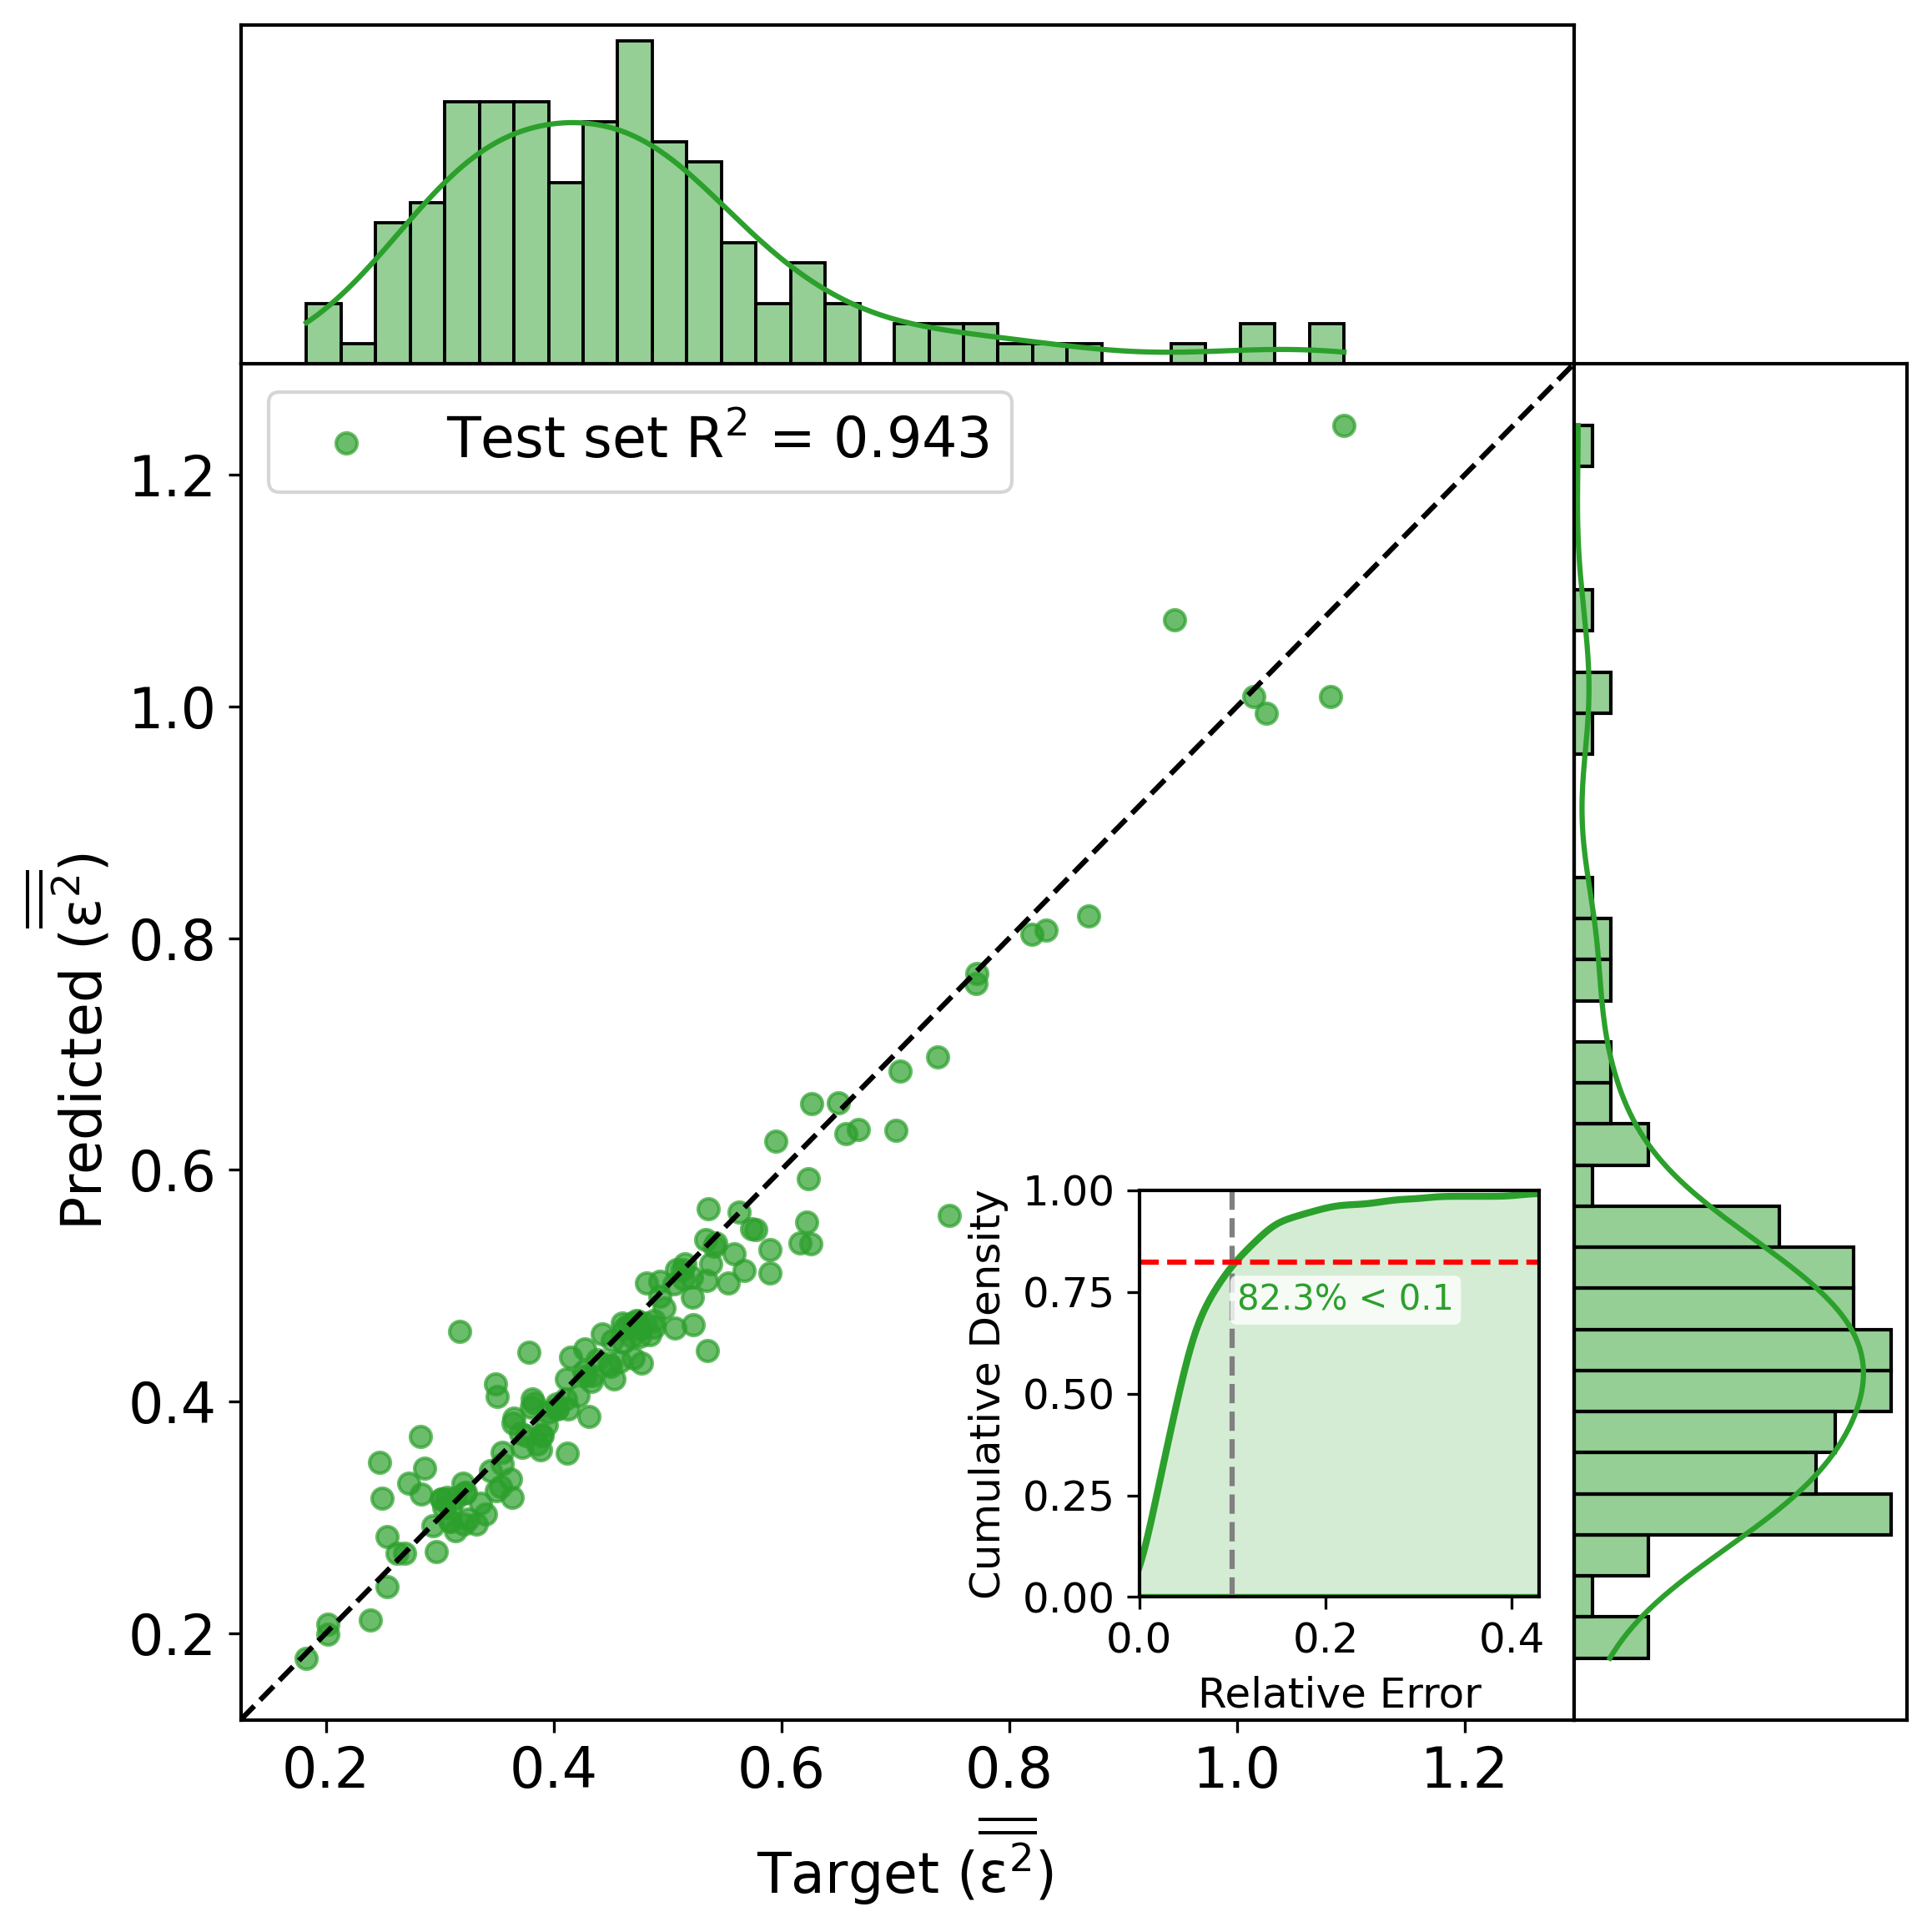

Train:
  R² = 0.9893681
  Mean abs_diff = 0.0114324
Validation:
  R² = 0.9370242
  Mean abs_diff = 0.0251996
Test:
  R² = 0.9431096
  Mean abs_diff = 0.0272261


In [39]:
splits = {
    "Train": idx_train,
    "Validation": idx_valid,
    "Test": idx_test
}


df['split'] = np.nan
for split_name, idx in splits.items():
    df.loc[idx, 'split'] = split_name


df['target_mean'] = df["rel_permittivity_imag_interp"].apply(
    lambda x: np.mean(x, axis=0)  
)
df['pred_mean'] = df["y_pred_cart"].apply(
    lambda x: np.mean(x, axis=0)  
)

def symmetric_tensor_avg(t):
    return np.mean([t[0, 0], t[1, 1], t[2, 2], t[0, 1], t[0, 2], t[1, 2]])

df['target_avg'] = df['target_mean'].apply(symmetric_tensor_avg) # Average over all 9 components
df['pred_avg'] = df['pred_mean'].apply(symmetric_tensor_avg)


# Compute absolute difference between the averages
df['abs_diff_avg'] = np.abs(df['target_avg'] - df['pred_avg'])

test_df = df[df['split'] == 'Test']
target_avg = test_df['target_avg'].values  # Shape: (num_test_samples,)
pred_avg = test_df['pred_avg'].values      # Shape: (num_test_samples,)
abs_diff_avg = test_df['abs_diff_avg'].values  # Shape: (num_test_samples,)


r2 = r2_score(target_avg, pred_avg)
# Create a scatter plot with marginal histograms for the Test set
fig = plt.figure(figsize=(8, 8), dpi=300)
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], 
                      wspace=0.00, hspace=0.00)

# Define colors
colors = {"Train": "#1f77b4", "Validation": "#ff7f0e", "Test": "#2ca02c"}

# Main scatter plot (average over components)
ax_scatter = fig.add_subplot(gs[1, 0])
ax_scatter.scatter(target_avg, pred_avg, alpha=0.7, color=colors["Test"], 
                   label=f"Test set $R^2$ = {r2:.3f}")
ax_scatter.set_xlabel(r"Target $(\overline{\overline{\varepsilon^2}}$) ")
ax_scatter.set_ylabel(r"Predicted $(\overline{\overline{\varepsilon^2}}$)")

# Add y = x reference line
min_val = min(min(target_avg), min(pred_avg))
max_val = max(max(target_avg), max(pred_avg))
buffer = (max_val - min_val) * 0.05
min_val -= buffer
max_val += buffer
ax_scatter.set_xlim(min_val, max_val)
ax_scatter.set_ylim(min_val, max_val)
x_vals = np.linspace(min_val, max_val, 100)
ax_scatter.plot(x_vals, x_vals, linestyle='--', color='black')
ax_scatter.legend(fontsize=16, loc='upper left', bbox_to_anchor=(0, 1.0))

# Top histogram (x-axis: True Avg)
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
sns.histplot(target_avg, bins=30, kde=True, color=colors["Test"], edgecolor="black", ax=ax_histx)
ax_histx.set_ylabel("")
ax_histx.set_xlabel("")
ax_histx.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax_histx.tick_params(axis='y', which='both', left=False, labelleft=False)

# Right histogram (y-axis: Predicted Avg)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)
sns.histplot(y=pred_avg, bins=30, kde=True, color=colors["Test"], edgecolor="black", ax=ax_histy)
ax_histy.set_xlabel("")
ax_histy.set_ylabel("")
ax_histy.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax_histy.tick_params(axis='y', which='both', left=False, labelleft=False)

# Add inset KDE plot for abs_diff_avg (using CDF)
epsilon = 1e-8  # Small value to prevent division by zero
rel_error = np.abs((target_avg - pred_avg) / (np.abs(target_avg) + epsilon))

inset_ax = inset_axes(ax_scatter, width="30%", height="30%", loc='lower right', 
                      bbox_to_anchor=(-0.005, 0.07, 1, 1), bbox_transform=ax_scatter.transAxes)
sns.kdeplot(rel_error, color=colors["Test"], ax=inset_ax, linewidth=2, bw_adjust=0.5, 
            fill=True, cumulative=True, alpha=0.2)
inset_ax.set_xlabel('Relative Error', fontsize=12)  
inset_ax.set_ylabel('Cumulative Density', fontsize=12)
inset_ax.tick_params(axis='both', labelsize=12)
inset_ax.set_xlim(0, max(rel_error) * 0.95)
inset_ax.set_ylim(0, 1)

# Define threshold and compute percentage
threshold = 0.1 # Adjust based on abs_diff_avg range
perc_te = np.mean(rel_error < threshold) * 100
inset_ax.axvline(x=threshold, color='gray', linestyle='--', linewidth=1.5)
inset_ax.axhline(y=perc_te/100, color='red', linestyle='--', linewidth=1.5)
inset_ax.text(threshold+0.005, perc_te/100 - 0.05, f'{perc_te:.1f}% < {threshold}', 
              color=colors["Test"], fontsize=10, ha='left', va='top', 
              bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

# Adjust layout
plt.tight_layout()
fig.savefig(f"../pngs/mae_scatter.pdf", dpi=500)
plt.show()

# Optional: Display summary statistics
for split_name in splits:
    split_df = df[df['split'] == split_name]
    split_target_avg = split_df['target_avg'].values
    split_pred_avg = split_df['pred_avg'].values
    split_r2 = r2_score(split_target_avg, split_pred_avg)
    print(f"{split_name}:")
    print(f"  R² = {split_r2:.7f}")
    print(f"  Mean abs_diff = {split_df['abs_diff_avg'].mean() :.7f}")